<a href="https://colab.research.google.com/github/AntikGhalt/predicting_bankruptcy_AIDA/blob/main/AIDA_2_TEST7_enanched.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### COLAB DRIVE

---



In [ ]:
#@title RESET AND FILES NAME
%reset -f
#path data export


# list your files in the exact order you want their rows to appear
file_names = [
    "Aida_Export_TESTin2_0_1374.xlsx",
    "Aida_Export_TESTout_100001_101000.xlsx",
]

test_files = [
    "Aida_Export_testD2_001_200.xlsx",
    "Aida_Export_testD2_201_400.xlsx",
    "Aida_Export_testD2_401_600.xlsx",
    "Aida_Export_testD2_601_800.xlsx",
    "Aida_Export_testD2_801_1000.xlsx",
    "Aida_Export_testD2_1001_1200.xlsx",
    "Aida_Export_testD2_1201_1374.xlsx",
    "Aida_Export_testD_100001_100100.xlsx",
    "Aida_Export_testD_100101_100200.xlsx",
    "Aida_Export_testD_100201_100400.xlsx",
    "Aida_Export_testD_100401_100600.xlsx",
    "Aida_Export_testD_100601_100800.xlsx",
    "Aida_Export_testD_100801_101000.xlsx"
]

In [ ]:
model_folder_input = "model_test/"
model_folder_output = "model_test8/"

In [ ]:
path_data = "/content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/DATA/" + model_folder_input
path_MODEL = "/content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/output/" + model_folder_output

In [ ]:
# --- Installation ---
# Installs all required libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm tensorflow optuna plotly
!pip uninstall -y kaleido
!pip install kaleido==0.2.1
# --- Standard Library ---
import os
import re
import gc
import time
import json
import pickle
import textwrap
import warnings
from datetime import datetime
import sys

# --- Data Handling ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
# --- Scientific Computing / Stats ---
from scipy.interpolate import make_interp_spline

# --- Scikit-Learn ---
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    precision_score,
    recall_score
)

# --- Gradient Boosting ---
import xgboost as xgb
import lightgbm as lgb

# --- Deep Learning ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Hyperparameter Optimization ---
import optuna
from optuna.pruners import MedianPruner
from optuna.visualization import plot_optimization_history
import optuna.visualization as optuna_vis

# --- Jupyter / Colab Specific ---
from IPython.display import clear_output, display
from google.colab import data_table
from google.colab import drive

# --- ENVIRONMENT CONFIGURATION ---
# Suppress all warnings for cleaner output
warnings.filterwarnings('ignore')
# Set Optuna logging verbosity to show only warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
"""
def safe_literal_eval(x):
    # If x is a list or numpy array and empty, return an empty list
    if isinstance(x, (list, np.ndarray)) and len(x) == 0:
        return []
    # For scalar values, check if x is NaN
    if not isinstance(x, (list, np.ndarray)) and pd.isna(x):
        return []

    # Otherwise, convert to string and strip any whitespace
    x = str(x).strip()

    try:
        return ast.literal_eval(x)
    except Exception:
        return x
"""
clear_output()

## Building dataframe

---



### DATA MANIPULATION

---




In [ ]:
#@title FILES ≥ 15 (with per–chunk date/year fixing · v2)

date_pattern = re.compile(r'(year|date)$', re.IGNORECASE)

df_list = []
for fn in file_names:
    print(f"Processing file: {fn}")
    tmp = pd.read_excel(
        path_data + fn,
        sheet_name="Results",
        na_values=["n.a."],
        keep_default_na=True
    )
    # normalise enterprise key
    tmp["Tax code number"] = tmp["Tax code number"].astype("Int64")

    # ───────────────────────────────────────────────────────────────────────
    # fix every *…year / …date* column in this chunk
    # ───────────────────────────────────────────────────────────────────────
    for col in tmp.columns:
        if not date_pattern.search(col):
            continue

        raw = tmp[col]
        ser = pd.to_numeric(raw, errors="coerce")        # numeric if possible

        # a) discard values outside a safe Excel-serial window  (-10 000 … 100 000)
        safe = ser.between(-10_000, 100_000) & ser.notna()
        dt   = pd.Series(pd.NaT, index=ser.index)        # pre-allocate with NaT

        if safe.any():                                   # convert *only* safe values
            dt.loc[safe] = pd.to_datetime(
                ser.loc[safe].astype("int64"),           # int64 avoids float weirdness
                unit="D",
                origin="1899-12-30",
                errors="coerce"
            )

        # b) remaining non-null → try string parse (day-first)
        mask_str = dt.isna() & raw.notna()
        if mask_str.any():
            dt.loc[mask_str] = pd.to_datetime(
                raw[mask_str],
                dayfirst=True,
                errors="coerce"
            )

        tmp[col] = dt
        print(f"  {col}: parsed {dt.notna().sum():,}/{raw.notna().sum():,} values")

    df_list.append(tmp)
    del tmp
    gc.collect()

# concatenate all chunks
df_start = pd.concat(df_list, ignore_index=True)
print("Final shape:", df_start.shape)


Processing file: Aida_Export_TESTin2_0_1374.xlsx
  Incorporation year: parsed 1,368/1,368 values
  Last accounting closing date: parsed 1,374/1,374 values
Processing file: Aida_Export_TESTout_100001_101000.xlsx
  Incorporation year: parsed 1,000/1,000 values
  Last accounting closing date: parsed 1,000/1,000 values
Final shape: (4281, 16)


In [ ]:
#@title Events Manipulation

# 2) Build your 'master' enterprises (one row per tax code)
master = (
    df_start[df_start['Tax code number'].notna()]
      .drop_duplicates(subset='Tax code number', keep='first')
)

# 3) Prepare the events table
events = (
    df_start[['Tax code number',
        'Procedure/cessazione',
        'Date of open procedure/cessazione',
        'Date of closure procedure']]
    .copy()
)
# fill down the tax‐code so every event row has its enterprise key
events['Tax code number'] = events['Tax code number'].ffill()

# keep only real events
events = events[events['Procedure/cessazione'].notna()].rename(columns={
    'Procedure/cessazione':        'Procedure',
    'Date of open procedure/cessazione': 'open_date',
    'Date of closure procedure':   'close_date'
})

# parse dates
events['open_date']  = pd.to_datetime(events['open_date'],  dayfirst=True, errors='coerce')
events['close_date'] = pd.to_datetime(events['close_date'], dayfirst=True, errors='coerce')

# 4) Sort & number each event per enterprise
events = (events
          .sort_values(['Tax code number', 'open_date'], ascending=[True, False]))
events['event_idx'] = events.groupby('Tax code number').cumcount()
events['event_idx'] = -events['event_idx']

# 5) Pivot to wide with unstack
df_e = events.set_index(['Tax code number','event_idx'])[['Procedure','open_date','close_date']]
df_un = df_e.unstack('event_idx')  # shape: index=tax codes, columns=(field, idx)
#5.1 order of tuples
field_order = ['Procedure','open_date','close_date']
idx_order   = sorted(df_un.columns.levels[1], reverse=True)

ordered_tuples = [
    (field, idx)
    for field in field_order
    for idx   in idx_order
    if (field, idx) in df_un.columns
]

df_un = df_un.reindex(columns=pd.MultiIndex.from_tuples(ordered_tuples))
# 6) Flatten the MultiIndex columns
df_un.columns = [
    (f"Event {i}"                 if field=='Procedure' else
     f"Date of open Event {i}"   if field=='open_date' else
     f"Date of closure Event {i}")
    for field, i in df_un.columns
]
df_un = df_un.reset_index()  # bring back Tax code number as a column

# 7) Merge back onto master (preserves your enterprise order)
final_df = (master
            .merge(df_un, on='Tax code number', how='left', sort=False)
            .reset_index(drop=True)
           )

#print(f"Enterprises: {len(master)}, rows in final_df: {len(final_df)}")
#final_df.head()

final_df = final_df.drop(columns=[
    'Procedure/cessazione',
    'Date of open procedure/cessazione',
    'Date of closure procedure'
])

In [ ]:
#@title Appending
# 1) Treat only "n.a." as missing when reading
read_kwargs = dict(
    sheet_name="Results",
    index_col=None,
    na_values=["n.a."],
    keep_default_na=True
)

# 2) Read & stack all the new data end-to-end
df_list = []
for fn in test_files:
    tmp = pd.read_excel(path_data + fn, **read_kwargs)
    tmp['Tax code number'] = tmp['Tax code number'].astype('Int64')
    df_list.append(tmp)

In [ ]:
#@title Balance sheet MANIPULATION - stacking and Fix Duplicate Column Names before mergingh

import re

# 1) Stack all new files into one DataFrame
all_new = pd.concat(df_list, ignore_index=True)


# Function to extract base name (without year) from column name
def get_base_name(col_name):
    """Extract the base variable name without the year, handling .1 .2 suffixes"""
    # First, remove any .1, .2, etc. suffix if present
    suffix_pattern = re.compile(r'\.\d+$')
    col_name_cleaned = suffix_pattern.sub('', col_name)

    # Now look for year at the end (after potential newlines)
    year_pattern = re.compile(r'(20\d{2})$', re.MULTILINE)
    if year_pattern.search(col_name_cleaned):
        # Remove the year to get base name
        base = year_pattern.sub('', col_name_cleaned).strip()
        return base
    return None

# Process all_new dataframe to add group prefixes
print("Processing all_new dataframe to fix duplicate column names...")
print(f"Original shape: {all_new.shape}")

# Get all columns
columns = list(all_new.columns)
new_columns = []
group_counter = 1
seen_groups = {}  # Track which base names we've seen and their group numbers
current_base = None
current_group = None

# Process columns in order
for i, col in enumerate(columns):
    base_name = get_base_name(col)

    if base_name is None:
        # Not a year column, keep as is
        new_columns.append(col)
    else:
        # Check if this is a new group
        if base_name != current_base:
            # New group detected
            if base_name in seen_groups:
                # We've seen this base name before, increment group number
                current_group = max(seen_groups[base_name]) + 1
                seen_groups[base_name].append(current_group)
            else:
                # First time seeing this base name
                current_group = group_counter
                seen_groups[base_name] = [current_group]
                group_counter += 1

            current_base = base_name

        # Add prefix to column name
        new_col_name = f"{current_group:04d}_{col}"
        new_columns.append(new_col_name)

# Apply new column names
all_new.columns = new_columns

print(f"\nTotal groups created: {group_counter - 1}")
print(f"Columns renamed: {len([old for old, new in zip(columns, new_columns) if old != new])}")

# Show examples of renamed columns
print("\nExamples of renamed columns:")
year_pattern = re.compile(r'(20\d{2})$', re.MULTILINE)
renamed_examples = [(old, new) for old, new in zip(columns, new_columns)
                    if old != new and year_pattern.search(old)][:10]

for old, new in renamed_examples:
    # Show in readable format
    old_display = old.replace('\n', '\\n')
    new_display = new.replace('\n', '\\n')
    print(f"  {old_display} -> {new_display}")

# Verify no duplicates remain
duplicate_cols = all_new.columns[all_new.columns.duplicated()].tolist()
if duplicate_cols:
    print(f"\n⚠️ Warning: Still have {len(duplicate_cols)} duplicate columns!")
    print(f"Duplicates: {duplicate_cols[:5]}")
else:
    print("\n✅ Success: No duplicate columns remaining!")

# Show column name patterns
print("\nColumn name patterns (first few groups):")
for base_name, groups in list(seen_groups.items())[:5]:
    base_display = base_name.split('\n')[0][:50]  # First line, max 50 chars
    print(f"  '{base_display}...' appears in groups: {groups}")

# Test the function
test_cases = [
    "Additions in progress and advances\nth EUR\n2023",
    "Additions in progress and advances\nth EUR\n2023.1",
    "Additions in progress and advances\nth EUR\n2023.2",
    "Company name",
    "Tax code number"
]

print("Testing improved get_base_name function:")
for test in test_cases:
    result = get_base_name(test)
    test_display = test.replace('\n', '\\n')
    print(f"  '{test_display}' -> {repr(result)}")

Processing all_new dataframe to fix duplicate column names...
Original shape: (2374, 4243)

Total groups created: 365
Columns renamed: 4240

Examples of renamed columns:
  Revenues from sales and services\nth EUR\n2023 -> 0001_Revenues from sales and services\nth EUR\n2023
  Revenues from sales and services\nth EUR\n2022 -> 0001_Revenues from sales and services\nth EUR\n2022
  Revenues from sales and services\nth EUR\n2021 -> 0001_Revenues from sales and services\nth EUR\n2021
  Revenues from sales and services\nth EUR\n2020 -> 0001_Revenues from sales and services\nth EUR\n2020
  Revenues from sales and services\nth EUR\n2019 -> 0001_Revenues from sales and services\nth EUR\n2019
  Revenues from sales and services\nth EUR\n2018 -> 0001_Revenues from sales and services\nth EUR\n2018
  Revenues from sales and services\nth EUR\n2017 -> 0001_Revenues from sales and services\nth EUR\n2017
  Revenues from sales and services\nth EUR\n2016 -> 0001_Revenues from sales and services\nth EUR\n201

In [ ]:
#@title Merging

# 2) Ensure the key is the same type
all_new['Tax code number'] = all_new['Tax code number'].astype('Int64')

# 3) Perform a 1:1 left-join of your master with the new data,
df = final_df.merge(
    all_new,
    on='Tax code number',
    how='left',
    validate='one_to_one'
)
# Fix duplicate column names if they exist
if 'Company name_x' in df.columns and 'Company name_y' in df.columns:
    # Keep the one from final_df (left side) and drop the duplicate
    df['Company name'] = df['Company name_x']
    df = df.drop(columns=['Company name_x', 'Company name_y'])
    print("Fixed duplicate Company name columns")

print(df.shape)  # rows == final_df.rows; columns == union of both sets of variables


Fixed duplicate Company name columns
(2374, 4272)


In [ ]:
#@title visualize big database

# Show *every* column
pd.set_option('display.max_columns', 1000)

# (Optionally widen your display so lines don’t wrap too crazily)
pd.set_option('display.width', 20)
pd.set_option('display.max_colwidth', 50)

# Now when you do…
#df

#print(final_df.iloc[:, :10])
#df.iloc[:30, :200]
#df.iloc[1000:1030, :200]

df.iloc[985:1015, :200]

,Unnamed: 0_x,Tax code number,Registered office address - Postal code,Registered office address - Longitude,Registered office address - Latitude,Trading address - Postal code,Legal status,Legal form,Company category,Incorporation year,No of available years,Last accounting closing date,Event 0,Event -1,Event -2,Event -3,Event -4,Event -5,Date of open Event 0,Date of open Event -1,Date of open Event -2,Date of open Event -3,Date of open Event -4,Date of open Event -5,Date of closure Event 0,Date of closure Event -1,Date of closure Event -2,Date of closure Event -3,Date of closure Event -4,Date of closure Event -5,Unnamed: 0_y,0001_Revenues from sales and services\nth EUR\n2023,0001_Revenues from sales and services\nth EUR\n2022,0001_Revenues from sales and services\nth EUR\n2021,0001_Revenues from sales and services\nth EUR\n2020,0001_Revenues from sales and services\nth EUR\n2019,0001_Revenues from sales and services\nth EUR\n2018,0001_Revenues from sales and services\nth EUR\n2017,0001_Revenues from sales and services\nth EUR\n2016,0001_Revenues from sales and services\nth EUR\n2015,0001_Revenues from sales and services\nth EUR\n2014,0002_EBITDA\nth EUR\n2023,0002_EBITDA\nth EUR\n2022,0002_EBITDA\nth EUR\n2021,0002_EBITDA\nth EUR\n2020,0002_EBITDA\nth EUR\n2019,0002_EBITDA\nth EUR\n2018,0002_EBITDA\nth EUR\n2017,0002_EBITDA\nth EUR\n2016,0002_EBITDA\nth EUR\n2015,0002_EBITDA\nth EUR\n2014,0003_Profit (loss)\nth EUR\n2023,0003_Profit (loss)\nth EUR\n2022,0003_Profit (loss)\nth EUR\n2021,0003_Profit (loss)\nth EUR\n2020,0003_Profit (loss)\nth EUR\n2019,0003_Profit (loss)\nth EUR\n2018,0003_Profit (loss)\nth EUR\n2017,0003_Profit (loss)\nth EUR\n2016,0003_Profit (loss)\nth EUR\n2015,0003_Profit (loss)\nth EUR\n2014,0004_Total assets\nth EUR\n2023,0004_Total assets\nth EUR\n2022,0004_Total assets\nth EUR\n2021,0004_Total assets\nth EUR\n2020,0004_Total assets\nth EUR\n2019,0004_Total assets\nth EUR\n2018,0004_Total assets\nth EUR\n2017,0004_Total assets\nth EUR\n2016,0004_Total assets\nth EUR\n2015,0004_Total assets\nth EUR\n2014,0005_Total shareholder's funds\nth EUR\n2023,0005_Total shareholder's funds\nth EUR\n2022,0005_Total shareholder's funds\nth EUR\n2021,0005_Total shareholder's funds\nth EUR\n2020,0005_Total shareholder's funds\nth EUR\n2019,0005_Total shareholder's funds\nth EUR\n2018,0005_Total shareholder's funds\nth EUR\n2017,0005_Total shareholder's funds\nth EUR\n2016,0005_Total shareholder's funds\nth EUR\n2015,0005_Total shareholder's funds\nth EUR\n2014,0006_Net financial position\nth EUR\n2023,0006_Net financial position\nth EUR\n2022,0006_Net financial position\nth EUR\n2021,0006_Net financial position\nth EUR\n2020,0006_Net financial position\nth EUR\n2019,0006_Net financial position\nth EUR\n2018,0006_Net financial position\nth EUR\n2017,0006_Net financial position\nth EUR\n2016,0006_Net financial position\nth EUR\n2015,0006_Net financial position\nth EUR\n2014,0007_EBITDA/Vendite\n%\n2023,0007_EBITDA/Vendite\n%\n2022,0007_EBITDA/Vendite\n%\n2021,0007_EBITDA/Vendite\n%\n2020,0007_EBITDA/Vendite\n%\n2019,0007_EBITDA/Vendite\n%\n2018,0007_EBITDA/Vendite\n%\n2017,0007_EBITDA/Vendite\n%\n2016,0007_EBITDA/Vendite\n%\n2015,0007_EBITDA/Vendite\n%\n2014,0008_Return on sales (ROS)\n%\n2023,0008_Return on sales (ROS)\n%\n2022,0008_Return on sales (ROS)\n%\n2021,0008_Return on sales (ROS)\n%\n2020,0008_Return on sales (ROS)\n%\n2019,0008_Return on sales (ROS)\n%\n2018,0008_Return on sales (ROS)\n%\n2017,0008_Return on sales (ROS)\n%\n2016,0008_Return on sales (ROS)\n%\n2015,0008_Return on sales (ROS)\n%\n2014,0009_Return on asset (ROA)\n%\n2023,0009_Return on asset (ROA)\n%\n2022,0009_Return on asset (ROA)\n%\n2021,0009_Return on asset (ROA)\n%\n2020,0009_Return on asset (ROA)\n%\n2019,0009_Return on asset (ROA)\n%\n2018,0009_Return on asset (ROA)\n%\n2017,0009_Return on asset (ROA)\n%\n2016,0009_Return on asset (ROA)\n%\n2015,0009_Return on asset (ROA)\n%\n2014,0010_Return on equity (ROE)\n%\n2023,0010_Return on equity

Yearly openings:


Procedure,Bankruptcy,Judicial liquidation
year,,
1995,1,0
1998,1,0
1999,1,0
2003,1,0
2004,5,0
2005,4,0
2006,16,0
2008,3,0
2009,13,0


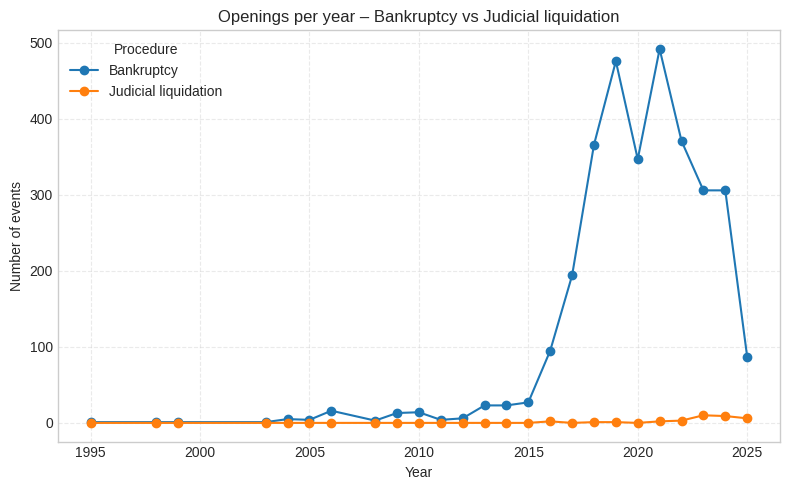

In [ ]:
#@title bankruptcy graph
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0  Example: load df  ⟵ skip if df is already in memory
# ------------------------------------------------------------
# df = pd.read_csv("your_file.csv")         # or any other loader

# ------------------------------------------------------------
# 1  Identify the two parallel families of columns
# ------------------------------------------------------------
event_cols = [c for c in df.columns if c.startswith("Event ")]
date_cols  = [c for c in df.columns if c.startswith("Date of open Event")]

# Safety check — they must be the same length & consistent suffixes
assert len(event_cols) == len(date_cols), "Column count mismatch"

# Extract the numeric / signed suffix (e.g. 0, -1, -2 …) so we can align
def suffix(colname):
    return colname.split("Event")[-1].strip()   # yields "0", "-1", …

events_wide = df[event_cols].copy()
events_wide.columns = [suffix(c) for c in events_wide.columns]

dates_wide  = df[date_cols].copy()
dates_wide.columns  = [suffix(c) for c in dates_wide.columns]

# ------------------------------------------------------------
# 2  Reshape to long format
# ------------------------------------------------------------
events_long = (
    events_wide
      .melt(ignore_index=False, var_name="slot", value_name="Procedure")
)

dates_long = (
    dates_wide
      .melt(ignore_index=False, var_name="slot", value_name="Date_open")
)

long = (
    events_long
      .join(dates_long["Date_open"])
      .dropna(subset=["Procedure", "Date_open"])          # keep only rows with both pieces
      .reset_index(drop=False)                             # keeps the original df index as a column
)

# ------------------------------------------------------------
# 3  Focus on the two target procedures
# ------------------------------------------------------------
targets = ["Bankruptcy", "Judicial liquidation"]

subset = long[long["Procedure"].isin(targets)].copy()
subset["year"] = pd.to_datetime(subset["Date_open"]).dt.year

# ------------------------------------------------------------
# 4  Yearly counts
# ------------------------------------------------------------
yearly_counts = (
    subset.groupby(["Procedure", "year"])
          .size()
          .unstack("Procedure", fill_value=0)
          .sort_index()
)

print("Yearly openings:")
display(yearly_counts)

# ------------------------------------------------------------
# 5  Quick plot (optional)
# ------------------------------------------------------------
ax = yearly_counts.plot(marker="o", figsize=(8,5))
ax.set_title("Openings per year – Bankruptcy vs Judicial liquidation")
ax.set_xlabel("Year")
ax.set_ylabel("Number of events")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
print(df.shape)

(2374, 4272)


In [ ]:
#@title LIST MISSING VARIABLES

# 1) Count columns that are 100% missing
all_nan = df.columns[df.isna().all()]
print(f"Columns with all NaN: {len(all_nan)}")

# 2) Drop them
df.drop(columns=all_nan, inplace=True)

# 3) Show the list of dropped columns
print("Dropped columns:")
for col in all_nan:
    print(f" - {col}")


Columns with all NaN: 917
Dropped columns:
 - Date of closure Event -4
 - Date of closure Event -5
 - 0081_Amounts due for advance taxation
th EUR
2023
 - 0081_Amounts due for advance taxation
th EUR
2022
 - 0081_Amounts due for advance taxation
th EUR
2021
 - 0081_Amounts due for advance taxation
th EUR
2020
 - 0081_Amounts due for advance taxation
th EUR
2019
 - 0081_Amounts due for advance taxation
th EUR
2018
 - 0081_Amounts due for advance taxation
th EUR
2017
 - 0081_Amounts due for advance taxation
th EUR
2016
 - 0081_Amounts due for advance taxation
th EUR
2015
 - 0081_Amounts due for advance taxation
th EUR
2014
 - 0109_GROUP consolidation reserve
th EUR
2023
 - 0109_GROUP consolidation reserve
th EUR
2022
 - 0109_GROUP consolidation reserve
th EUR
2021
 - 0109_GROUP consolidation reserve
th EUR
2020
 - 0109_GROUP consolidation reserve
th EUR
2019
 - 0109_GROUP consolidation reserve
th EUR
2018
 - 0109_GROUP consolidation reserve
th EUR
2017
 - 0109_GROUP consolidation reserve

In [ ]:
#@title RANK OF MISSING in NON-MISSING VARIABLES

# 4) Compute missing counts for the rest, sort descending
missing_counts = df.isna().sum().sort_values(ascending=False)

# Ensure pandas will print all rows
pd.set_option('display.max_rows', None)

print("\nMissing‐value counts for remaining columns (desc):")
print(missing_counts)



Missing‐value counts for remaining columns (desc):
0365_Monthly - Trading volume - December\n2018                                                                                             2373
0365_Monthly - Trading volume - December\n2019                                                                                             2373
0365_Monthly - Trading volume - December\n2015                                                                                             2373
0365_Monthly - Trading volume - December\n2016                                                                                             2373
0365_Monthly - Trading volume - December\n2022                                                                                             2373
0365_Monthly - Trading volume - December\n2021                                                                                             2373
0365_Monthly - Trading volume - December\n2020                                      

### Reshape, dummy

---



In [ ]:
#@title Bankruptcy dummy

# Create bankruptcy dummy and date variables
df['Bankruptcy_dummy'] = 0
df['Bankruptcy_dummy_date'] = pd.NaT

# Find all event columns
event_cols = [c for c in df.columns if c.startswith('Event ') and not c.startswith('Date of')]

print(f"Checking {len(event_cols)} event columns for bankruptcy...")

# For each row, check if any event contains "Bankruptcy"
bankruptcy_count = 0

for idx, row in df.iterrows():
    for event_col in event_cols:
        event_value = row[event_col]

        # Check if this event is exactly "Bankruptcy" (case sensitive)
        if pd.notna(event_value) and event_value == 'Bankruptcy':
            # Set the dummy to 1
            df.loc[idx, 'Bankruptcy_dummy'] = 1

            # Extract the event number from column name (e.g., "Event -2" -> "-2")
            event_num = event_col.replace('Event ', '')

            # Find the corresponding date column
            date_col = f'Date of open Event {event_num}'

            # If the date column exists and has a value, store it
            if date_col in df.columns and pd.notna(row[date_col]):
                df.loc[idx, 'Bankruptcy_dummy_date'] = pd.to_datetime(row[date_col])
                bankruptcy_count += 1
                break  # Stop after finding the first bankruptcy event

# Convert date column to datetime type
df['Bankruptcy_dummy_date'] = pd.to_datetime(df['Bankruptcy_dummy_date'])

# Display summary
print(f"\nTotal enterprises with Bankruptcy event: {df['Bankruptcy_dummy'].sum()}")
print(f"Enterprises with valid bankruptcy dates: {bankruptcy_count}")

# Show distribution
print("\nBankruptcy_dummy distribution:")
print(df['Bankruptcy_dummy'].value_counts())

# Show sample of enterprises with bankruptcy
bankrupt_sample = df[df['Bankruptcy_dummy'] == 1][['Tax code number', 'Company name', 'Bankruptcy_dummy', 'Bankruptcy_dummy_date']].head(10)
print("\nSample of enterprises with bankruptcy:")
display(bankrupt_sample)

Checking 6 event columns for bankruptcy...

Total enterprises with Bankruptcy event: 1374
Enterprises with valid bankruptcy dates: 1373

Bankruptcy_dummy distribution:
Bankruptcy_dummy
1    1374
0    1000
Name: count, dtype: int64

Sample of enterprises with bankruptcy:


,Tax code number,Company name,Bankruptcy_dummy,Bankruptcy_dummy_date
0,647460286,VIMET S.P.A.,1,2017-03-03
1,4261290821,FENICE DISTRIBUZIONE S.R.L.,1,2017-05-15
2,2229420415,BENELLI Q. J. SRL,1,2016-07-12
3,1614500799,LA NUOVA NAVE SOCIETA' A RESPONSABILITA' LIMIT...,1,2021-10-12
4,3074840160,ONGIS METAL FER S.P.A.,1,2018-03-16
5,3725790137,NUOVA REX SUPERMERCATI S.R.L.,1,2021-07-22
6,1697130464,PERINI NAVI SOCIETA' PER AZIONI,1,2021-01-29
7,13116741003,CARFUEL S.R.L.,1,2018-05-08
8,13069551003,FUEL ENERGY S.R.L.,1,2017-12-05
9,13778081003,COMUNICARE INSIEME S.R.L.,1,2022-01-10


In [ ]:
#@title Reshape Long

# Starting from `df` which has Bankruptcy_dummy and Bankruptcy_dummy_date

# 1. First, identify columns with years
year_pattern = re.compile(r'(20\d{2})(?:\.\d+)?$', re.MULTILINE)  # Matches year with optional .1, .2 suffix
wide_cols = [col for col in df.columns if year_pattern.search(col)]
id_cols = [c for c in df.columns if c not in wide_cols]

print(f"Found {len(wide_cols)} columns with years")
print(f"Number of ID columns: {len(id_cols)}")
print(f"Total enterprises: {len(df)}")

# 2. Create a function to extract variable name and year
def parse_column_name(col_name):
    """Extract clean variable name and year from column"""
    year_match = year_pattern.search(col_name)
    if year_match:
        year = int(year_match.group(1))
        # Get variable name (first line before \n)
        var_name = col_name.split('\n')[0].strip()
        return var_name, year
    return None, None

# 3. Get unique years and variables
years = set()
variables = set()
col_mapping = {}  # Maps (variable, year) to original column name

for col in wide_cols:
    var_name, year = parse_column_name(col)
    if var_name and year:
        years.add(year)
        variables.add(var_name)
        col_mapping[(var_name, year)] = col

years = sorted(years)
variables = sorted(variables)

print(f"\nYears found: {min(years)} to {max(years)} (Total: {len(years)} years)")
print(f"Number of unique variables: {len(variables)}")
print(f"Expected max rows (if no bankruptcy): {len(df) * len(years):,}")

# 4. Process in chunks to save memory
chunk_size = 100  # Process 100 enterprises at a time
long_chunks = []
total_rows_created = 0
enterprises_truncated = 0

print("\nProcessing in chunks to save memory...")

for chunk_start in range(0, len(df), chunk_size):
    chunk_end = min(chunk_start + chunk_size, len(df))

    # Get chunk of enterprises
    df_chunk = df.iloc[chunk_start:chunk_end]

    # Create list to store long format data for this chunk
    chunk_data = []

    for _, row in df_chunk.iterrows():
        tax_code = row['Tax code number']

        # Get bankruptcy year if exists
        bankruptcy_year = None
        if row['Bankruptcy_dummy'] == 1 and pd.notna(row['Bankruptcy_dummy_date']):
            bankruptcy_year = row['Bankruptcy_dummy_date'].year
            enterprises_truncated += 1

        # For each year
        rows_for_enterprise = 0
        for year in years:
            # Skip years after bankruptcy
            if bankruptcy_year and year > bankruptcy_year:
                continue

            # Create row for this enterprise-year
            long_row = {}

            # Add ID columns (including Bankruptcy_dummy and Bankruptcy_dummy_date)
            for id_col in id_cols:
                long_row[id_col] = row[id_col]

            # Add year
            long_row['Year'] = year

            # Add variable values for this year
            for var_name in variables:
                col_key = (var_name, year)
                if col_key in col_mapping:
                    orig_col = col_mapping[col_key]
                    if orig_col in row.index:
                        long_row[var_name] = row[orig_col]
                    else:
                        long_row[var_name] = np.nan
                else:
                    long_row[var_name] = np.nan

            chunk_data.append(long_row)
            rows_for_enterprise += 1
            total_rows_created += 1

    # Convert chunk to dataframe
    chunk_long = pd.DataFrame(chunk_data)
    long_chunks.append(chunk_long)

    # Progress update
    if (chunk_end % 500 == 0) or (chunk_end == len(df)):
        print(f"  Processed {chunk_end}/{len(df)} enterprises... Total rows created: {total_rows_created:,}")

    # Clean up memory
    del chunk_data
    gc.collect()

# 5. Combine all chunks
print("\nCombining chunks...")
long_df = pd.concat(long_chunks, ignore_index=True)

# Clean up
del long_chunks
gc.collect()

# 6. Add derived columns
print("\nAdding derived columns...")

# Create NameYear using the actual Company name column
if 'Company name' in long_df.columns:
    long_df['NameYear'] = long_df['Company name'].astype(str) + ' ' + long_df['Year'].astype(str)
    print("Using 'Company name' column for NameYear")
else:
    print("Warning: 'Company name' column not found!")

# Create KeyYear using Tax code number + Year
long_df['KeyYear'] = long_df['Tax code number'].astype(str) + '_' + long_df['Year'].astype(str)

# 7. Sort the data
long_df = long_df.sort_values(['Tax code number', 'Year']).reset_index(drop=True)

# 8. Display summary
print(f"\nFinal shape: {long_df.shape}")
print(f"Memory usage: {long_df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"Unique enterprises: {long_df['Tax code number'].nunique()}")
print(f"Years covered: {long_df['Year'].min()} to {long_df['Year'].max()}")
print(f"Enterprises truncated due to bankruptcy: {enterprises_truncated}")

# Check observation count per enterprise
obs_per_enterprise = long_df.groupby('Tax code number').size()
print(f"\nObservations per enterprise:")
print(obs_per_enterprise.value_counts().sort_index())

# 9. Save to file
print("\nSaving to pickle file...")
long_df.to_pickle(path_data + 'long_format_data.pkl')
print("Saved successfully!")

# 10. Show sample
print("\nSample of reshaped data (first 20 rows):")
display(long_df.head(20))

# Show a company with bankruptcy
bankrupt_companies = long_df[long_df['Bankruptcy_dummy'] == 1]['Tax code number'].unique()
if len(bankrupt_companies) > 0:
    sample_bankrupt = bankrupt_companies[0]
    print(f"\nSample bankrupt company {sample_bankrupt}:")
    display(long_df[long_df['Tax code number'] == sample_bankrupt])

# Show columns
print("\nColumns in long format (first 50):")
for i, col in enumerate(long_df.columns[:50]):
    print(f"  {i+1}. {col}")

Found 3325 columns with years
Number of ID columns: 32
Total enterprises: 2374

Years found: 2014 to 2023 (Total: 10 years)
Number of unique variables: 353
Expected max rows (if no bankruptcy): 23,740

Processing in chunks to save memory...
  Processed 500/2374 enterprises... Total rows created: 3,272
  Processed 1000/2374 enterprises... Total rows created: 6,644
  Processed 1500/2374 enterprises... Total rows created: 10,355
  Processed 2000/2374 enterprises... Total rows created: 15,355
  Processed 2374/2374 enterprises... Total rows created: 19,095

Combining chunks...

Adding derived columns...
Using 'Company name' column for NameYear

Final shape: (19095, 388)
Memory usage: 0.07 GB
Unique enterprises: 2364
Years covered: 2014 to 2023
Enterprises truncated due to bankruptcy: 1373

Observations per enterprise:
1        2
3       12
4       89
5      215
6      334
7      245
8      304
9      155
10    1008
Name: count, dtype: int64

Saving to pickle file...
Saved successfully!

Sam

,Unnamed: 0_x,Tax code number,Registered office address - Postal code,Registered office address - Longitude,Registered office address - Latitude,Trading address - Postal code,Legal status,Legal form,Company category,Incorporation year,No of available years,Last accounting closing date,Event 0,Event -1,Event -2,Event -3,Event -4,Event -5,Date of open Event 0,Date of open Event -1,Date of open Event -2,Date of open Event -3,Date of open Event -4,Date of open Event -5,Date of closure Event 0,Date of closure Event -1,Date of closure Event -2,Date of closure Event -3,Unnamed: 0_y,Company name,Bankruptcy_dummy,Bankruptcy_dummy_date,Year,0001_Revenues from sales and services,0002_EBITDA,0002_Revenues from sales and services,0003_Profit (loss),0004_Total assets,0005_Total shareholder's funds,0006_Net financial position,0007_EBITDA/Vendite,0008_Return on sales (ROS),0009_Return on asset (ROA),0010_Return on equity (ROE),0011_Debt/equity ratio,0012_Banks/turnover,0013_Debt/EBITDA ratio,0014_Total assets turnover (times),0015_Number of employees,0016_TOTAL receivables due from shareholders,0017_Called share capital,0018_TOTAL FIXED ASSETS,0019_TOTAL INTANGIBLE FIXED ASSETS,0020_Start-up and expansion costs,0021_Research and dev. exp.,0022_Ind. patents and intellect. property rights,"0023_Concessions, licenses, trademarks and similar rights",0024_Goodwill/Consolidation Difference,0025_including: Goodwill,0026_Additions in progress and advances,0027_Additions in progress and advances,0027_Others,0028_(Amortization provision),0029_TOTAL TANGIBLE FIXED ASSETS,0030_including: leased tangible assets,0031_Land and buildings,0032_Plant and machinery,0033_Indust. and commercial equipment,0034_Other assets,0035_(Depreciation provision),0036_TOTAL FINANCIAL FIXED ASSETS,0037_including: short term,0038_Total equity investments,0039_Subsidiary companies,0040_Associated companies,0041_Parent companies,0042_Companies under parent companies control,0043_Other companies,0044_Total Receivables,0045_Receiv. due from subs. Comp.,0046_Receiv. due from subs. Comp.,0046_Receiv. due from subs. companies - beyond 12 months,0047_Receiv. due from assoc. companies,0048_Receiv. due from assoc. companies - beyond 12 months,0049_Receiv. due from parent comp. - beyond 12 months,0050_Due from comp. under parent companies control,0050_Receiv. due from parent comp. - beyond 12 months,0051_Due from comp. under parent companies control,0051_Due from comp. under parent companies control - beyond 12 months,0052_Due from comp. under parent companies control - beyond 12 months,0052_Receiv. due from other comp.,0053_Receiv. due from others - beyond 12 months,0054_FIN. RECEIV. WITHIN 12 MONTHS,0054_Receiv. due from others - beyond 12 months,0055_FINA. RECEIV. BEYOND 12 MONTHS,0056_Other securities,0057_Other securities,0057_Own shares,0058_Derivatives,0058_Own shares,0059_Derivatives,0059_Own shares: par value,0060_Own shares: par value,0060_TOTAL CURRENT ASSETS,0061_TOTAL INVENTORIES,0062_Raw and consumable materials,0063_Work in progress and semifinished products,0064_Contract work in progress,0065_Finished products and goods,0066_Advances,0067_Advances,0067_Tangible fixed assets to be sold,0068_TOTAL RECEIVABLES,0069_Trade accounts,0070_Trade accounts - beyond 12 months,0071_Receiv. due from subs. comp. - beyond 12 months,0072_Receiv. due from assoc. Comp.,0073_Receiv. due from assoc. Comp. - beyond 12 months,0074_Receiv. due from parent comp.,0075_Tax receivables,0076_Tax receiv. - beyond 12 months,0077_Tax receiv. for prepaid taxes,0078_Tax receiv. for prepaid taxes - beyond 12 months,0079_Receiv. due from others,0080_RECEIV. DUE WITHIN 12 MONTHS,0082_RECEIV. DUE BEYOND 12 MONTHS,0083_TOTAL FINANCIAL ASSETS,0084_Invest. in subs. comp.,0085_Invest. in assoc. comp.,0086_Invest. in parent comp.,0087_Invest. in comp. under parent companies control,0088_Other investments,0089_Financial instruments for cash pooling,0090_TOTAL LIQUID FUNDS,0091_Bank and postal deposits,0092_Checks,


Sample bankrupt company 151040623:


,Unnamed: 0_x,Tax code number,Registered office address - Postal code,Registered office address - Longitude,Registered office address - Latitude,Trading address - Postal code,Legal status,Legal form,Company category,Incorporation year,No of available years,Last accounting closing date,Event 0,Event -1,Event -2,Event -3,Event -4,Event -5,Date of open Event 0,Date of open Event -1,Date of open Event -2,Date of open Event -3,Date of open Event -4,Date of open Event -5,Date of closure Event 0,Date of closure Event -1,Date of closure Event -2,Date of closure Event -3,Unnamed: 0_y,Company name,Bankruptcy_dummy,Bankruptcy_dummy_date,Year,0001_Revenues from sales and services,0002_EBITDA,0002_Revenues from sales and services,0003_Profit (loss),0004_Total assets,0005_Total shareholder's funds,0006_Net financial position,0007_EBITDA/Vendite,0008_Return on sales (ROS),0009_Return on asset (ROA),0010_Return on equity (ROE),0011_Debt/equity ratio,0012_Banks/turnover,0013_Debt/EBITDA ratio,0014_Total assets turnover (times),0015_Number of employees,0016_TOTAL receivables due from shareholders,0017_Called share capital,0018_TOTAL FIXED ASSETS,0019_TOTAL INTANGIBLE FIXED ASSETS,0020_Start-up and expansion costs,0021_Research and dev. exp.,0022_Ind. patents and intellect. property rights,"0023_Concessions, licenses, trademarks and similar rights",0024_Goodwill/Consolidation Difference,0025_including: Goodwill,0026_Additions in progress and advances,0027_Additions in progress and advances,0027_Others,0028_(Amortization provision),0029_TOTAL TANGIBLE FIXED ASSETS,0030_including: leased tangible assets,0031_Land and buildings,0032_Plant and machinery,0033_Indust. and commercial equipment,0034_Other assets,0035_(Depreciation provision),0036_TOTAL FINANCIAL FIXED ASSETS,0037_including: short term,0038_Total equity investments,0039_Subsidiary companies,0040_Associated companies,0041_Parent companies,0042_Companies under parent companies control,0043_Other companies,0044_Total Receivables,0045_Receiv. due from subs. Comp.,0046_Receiv. due from subs. Comp.,0046_Receiv. due from subs. companies - beyond 12 months,0047_Receiv. due from assoc. companies,0048_Receiv. due from assoc. companies - beyond 12 months,0049_Receiv. due from parent comp. - beyond 12 months,0050_Due from comp. under parent companies control,0050_Receiv. due from parent comp. - beyond 12 months,0051_Due from comp. under parent companies control,0051_Due from comp. under parent companies control - beyond 12 months,0052_Due from comp. under parent companies control - beyond 12 months,0052_Receiv. due from other comp.,0053_Receiv. due from others - beyond 12 months,0054_FIN. RECEIV. WITHIN 12 MONTHS,0054_Receiv. due from others - beyond 12 months,0055_FINA. RECEIV. BEYOND 12 MONTHS,0056_Other securities,0057_Other securities,0057_Own shares,0058_Derivatives,0058_Own shares,0059_Derivatives,0059_Own shares: par value,0060_Own shares: par value,0060_TOTAL CURRENT ASSETS,0061_TOTAL INVENTORIES,0062_Raw and consumable materials,0063_Work in progress and semifinished products,0064_Contract work in progress,0065_Finished products and goods,0066_Advances,0067_Advances,0067_Tangible fixed assets to be sold,0068_TOTAL RECEIVABLES,0069_Trade accounts,0070_Trade accounts - beyond 12 months,0071_Receiv. due from subs. comp. - beyond 12 months,0072_Receiv. due from assoc. Comp.,0073_Receiv. due from assoc. Comp. - beyond 12 months,0074_Receiv. due from parent comp.,0075_Tax receivables,0076_Tax receiv. - beyond 12 months,0077_Tax receiv. for prepaid taxes,0078_Tax receiv. for prepaid taxes - beyond 12 months,0079_Receiv. due from others,0080_RECEIV. DUE WITHIN 12 MONTHS,0082_RECEIV. DUE BEYOND 12 MONTHS,0083_TOTAL FINANCIAL ASSETS,0084_Invest. in subs. comp.,0085_Invest. in assoc. comp.,0086_Invest. in parent comp.,0087_Invest. in comp. under parent companies control,0088_Other investments,0089_Financial instruments for cash pooling,0090_TOTAL LIQUID FUNDS,0091_Bank and postal deposits,0092_Checks,


Columns in long format (first 50):
  1. Unnamed: 0_x
  2. Tax code number
  3. Registered office address - Postal code
  4. Registered office address - Longitude
  5. Registered office address - Latitude
  6. Trading address - Postal code
  7. Legal status
  8. Legal form
  9. Company category
  10. Incorporation year
  11. No of available years
  12. Last accounting closing date
  13. Event 0
  14. Event -1
  15. Event -2
  16. Event -3
  17. Event -4
  18. Event -5
  19. Date of open Event 0
  20. Date of open Event -1
  21. Date of open Event -2
  22. Date of open Event -3
  23. Date of open Event -4
  24. Date of open Event -5
  25. Date of closure Event 0
  26. Date of closure Event -1
  27. Date of closure Event -2
  28. Date of closure Event -3
  29. Unnamed: 0_y
  30. Company name
  31. Bankruptcy_dummy
  32. Bankruptcy_dummy_date
  33. Year
  34. 0001_Revenues from sales and services
  35. 0002_EBITDA
  36. 0002_Revenues from sales and services
  37. 0003_Profit (loss)
  38. 

In [ ]:
#@title display dataframe
#long_df.head()
#df.head()
long_df.iloc[985:1015, 200:400]
#df.iloc[985:1015, :200]

,0160_Total payables after period,0161_TOTAL ACCRUED EXPENSES AND DEFERRED INCOME,0162_Fees on loans,0163_TOTAL LIABILITIES AND SHAREHOLDERS' FUNDS,0164_TOTAL MEMORANDUM ACCOUNTS,0165_TOTAL WARRANTIES SUPPLIED,0166_TOTAL VALUE OF PRODUCTION,0167_Changes in inventories,0168_Changes in contract work in progress,0169_Total changes,0170_Additions to fixed assets,0171_Other revenue,0172_operating grants,0173_TOTAL PRODUCTION COSTS,"0174_Raw, consum. mat. and goods for resale",0175_Services,0176_Use of third parties assets,0177_Total personnel costs,0178_Wages and salaries,0179_Social security charges,0180_Severance indemnities,0181_Pensions and similar obligations,0182_Other costs,0183_Severance indemnity + Pension + Other costs,"0184_Total depreciation, amortization and writedowns",0185_Amort. of intangible fixed assets,0186_Depr. of tangible fixed assets,0187_Writedown of fixed assets,"0188_Depreciation, amortization and writedowns of fixed assets",0189_Writedown of receivables,0190_Change in inventory of raw and consumable materials,0191_Provisions fo risks and charges,0192_Other operating expenses,0193_OPERATING MARGIN,0194_Added Value,0195_TOTAL FINANCIAL INCOME AND CHARGES,0196_Total income from equity investments,0198_Tot. inc. from equity invest. (of which: from parent companies),0199_Tot. inc. from equity invest. (of which: from companies under parent companies control),0200_Total other financial income,0201_From financial receivables,"0202_From fin. receiv. (of which: from subsidiaries, associated, parent cies and cies under parent cies control)",0203_From fin. receiv. (of which: from companies under parent companies control),0204_From securities held as fixed assets,0205_From securities held as current assets,0206_From securities,0207_Income other than the above,"0208_Inc. other than the above (of which: from subsidiaries, associated, parent cies and cies under parent cies control)",0209_Inc. other than the above (of which: from companies under parent companies control),0210_Total financial charges,0211_Financial charges of which: from financial receivables subs and assoc.,0212_Financial charges of which: of which: from companies under parent companies control,0213_Profit and Loss on Foreign Exchange,0214_TOTAL FINANCIAL ASSETS ADJUSTMENTS,0215_Total Revaluations,0216_Reval. of equity investments,0217_Reval. of other financial assets,0218_Reval. of securities,0219_Reval. of derivatives,0220_Reval. of financial instruments for cash pooling,0221_Total Writedowns,0222_Writedowns of equity invest.,0223_Writedowns of other fin. Ass.,0224_Writedowns of securities,0225_Writedowns of derivatives,0226_Writedowns of financial instruments for cash pooling,0227_TOTAL EXTRAORDINARY REVENUES AND CHARGES,0228_Extraordinary revenues,0229_of which capital gains,0230_Extraordinary charges,0231_of which capital losses,0232_of which taxes previous period,0233_PROFIT/LOSS BEFORE TAXATION,"0234_Total current, deferred and prepaid income taxes",0235_Current taxes,0236_Taxation related to previous years,0237_Prepaid and deferred taxes,0238_deferred taxation (+/-),0239_advance taxation (+/-),0240_Income (expenses) for adherence to fiscal transparency regime,0241_PROFIT (LOSS),0243_PROFIT (LOSS) GROUP,0244_Employees,0245_Tangible assets: (investment),0246_Tangible assets: (disposal),0247_Intangible assets: (investment),0248_Intangible assets: (disposal),0249_Financial assets: (investment),0250_Financial assets: (disposal),0251_Non-fixed financial assets: (investment),0252_Non-fixed financial assets: (disposal),"0255_Acquisition of business and interests in affiliates, net of cash acquired","0256_Disposal of business and interests in affiliates, net of cash acquired",0257_Cash flow from investments (B),0258_Change in provisions,0259_Amortisation of tangible assets,0260_Value corrections for impairment,0261_Value adjustments of financial income/charges from financial instruments that do not require an exchange of cash,0262_Other +/- adjustments of 

In [ ]:
#@title display sample

sample = long_df.sample(min(30, len(long_df)), random_state=42)
data_table.DataTable(sample,
                     include_index=False,
                     max_columns=500,           # only this table
                     num_rows_per_page=25)

pd.set_option("display.max_columns", None)     # never truncate columns
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_colwidth", None)
display(sample)                                # full 395 × n view


,Unnamed: 0_x,Tax code number,Registered office address - Postal code,Registered office address - Longitude,Registered office address - Latitude,Trading address - Postal code,Legal status,Legal form,Company category,Incorporation year,No of available years,Last accounting closing date,Event 0,Event -1,Event -2,Event -3,Event -4,Event -5,Date of open Event 0,Date of open Event -1,Date of open Event -2,Date of open Event -3,Date of open Event -4,Date of open Event -5,Date of closure Event 0,Date of closure Event -1,Date of closure Event -2,Date of closure Event -3,Unnamed: 0_y,Company name,Bankruptcy_dummy,Bankruptcy_dummy_date,Year,0001_Revenues from sales and services,0002_EBITDA,0002_Revenues from sales and services,0003_Profit (loss),0004_Total assets,0005_Total shareholder's funds,0006_Net financial position,0007_EBITDA/Vendite,0008_Return on sales (ROS),0009_Return on asset (ROA),0010_Return on equity (ROE),0011_Debt/equity ratio,0012_Banks/turnover,0013_Debt/EBITDA ratio,0014_Total assets turnover (times),0015_Number of employees,0016_TOTAL receivables due from shareholders,0017_Called share capital,0018_TOTAL FIXED ASSETS,0019_TOTAL INTANGIBLE FIXED ASSETS,0020_Start-up and expansion costs,0021_Research and dev. exp.,0022_Ind. patents and intellect. property rights,"0023_Concessions, licenses, trademarks and similar rights",0024_Goodwill/Consolidation Difference,0025_including: Goodwill,0026_Additions in progress and advances,0027_Additions in progress and advances,0027_Others,0028_(Amortization provision),0029_TOTAL TANGIBLE FIXED ASSETS,0030_including: leased tangible assets,0031_Land and buildings,0032_Plant and machinery,0033_Indust. and commercial equipment,0034_Other assets,0035_(Depreciation provision),0036_TOTAL FINANCIAL FIXED ASSETS,0037_including: short term,0038_Total equity investments,0039_Subsidiary companies,0040_Associated companies,0041_Parent companies,0042_Companies under parent companies control,0043_Other companies,0044_Total Receivables,0045_Receiv. due from subs. Comp.,0046_Receiv. due from subs. Comp.,0046_Receiv. due from subs. companies - beyond 12 months,0047_Receiv. due from assoc. companies,0048_Receiv. due from assoc. companies - beyond 12 months,0049_Receiv. due from parent comp. - beyond 12 months,0050_Due from comp. under parent companies control,0050_Receiv. due from parent comp. - beyond 12 months,0051_Due from comp. under parent companies control,0051_Due from comp. under parent companies control - beyond 12 months,0052_Due from comp. under parent companies control - beyond 12 months,0052_Receiv. due from other comp.,0053_Receiv. due from others - beyond 12 months,0054_FIN. RECEIV. WITHIN 12 MONTHS,0054_Receiv. due from others - beyond 12 months,0055_FINA. RECEIV. BEYOND 12 MONTHS,0056_Other securities,0057_Other securities,0057_Own shares,0058_Derivatives,0058_Own shares,0059_Derivatives,0059_Own shares: par value,0060_Own shares: par value,0060_TOTAL CURRENT ASSETS,0061_TOTAL INVENTORIES,0062_Raw and consumable materials,0063_Work in progress and semifinished products,0064_Contract work in progress,0065_Finished products and goods,0066_Advances,0067_Advances,0067_Tangible fixed assets to be sold,0068_TOTAL RECEIVABLES,0069_Trade accounts,0070_Trade accounts - beyond 12 months,0071_Receiv. due from subs. comp. - beyond 12 months,0072_Receiv. due from assoc. Comp.,0073_Receiv. due from assoc. Comp. - beyond 12 months,0074_Receiv. due from parent comp.,0075_Tax receivables,0076_Tax receiv. - beyond 12 months,0077_Tax receiv. for prepaid taxes,0078_Tax receiv. for prepaid taxes - beyond 12 months,0079_Receiv. due from others,0080_RECEIV. DUE WITHIN 12 MONTHS,0082_RECEIV. DUE BEYOND 12 MONTHS,0083_TOTAL FINANCIAL ASSETS,0084_Invest. in subs. comp.,0085_Invest. in assoc. comp.,0086_Invest. in parent comp.,0087_Invest. in comp. under parent companies control,0088_Other investments,0089_Financial instruments for cash pooling,0090_TOTAL LIQUID FUNDS,0091_Bank and postal deposits,0092_Checks,

### Finish manipulation

In [ ]:
# ============================================================================
#  @title CLEAN BANKRUPTCY DATAFRAME (NO LAG/EVER FEATURES)
#  ---------------------------------------------------------------------------
#  INPUT   : long_df  (raw long-format dataframe already in RAM)
#  OUTPUT  : long_df_clean · feature_cols · meta_cols
# ============================================================================


warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

long_df_wr = long_df.copy()          # ← keep this!  Do **not** reuse across runs
# ---------------------------------------------------------------------------
# 0 · HOUSE-KEEPING
# ---------------------------------------------------------------------------
def dedup_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Remove duplicated columns (keep the last occurrence)."""
    return df.loc[:, ~df.columns.duplicated(keep="last")]

def safe_year(col) -> pd.Series:
    """Return a clean calendar-year series from messy numeric / string input."""
    y = pd.to_numeric(col, errors="coerce")
    good = y.between(1900, 2100)
    out  = y.where(good)

    need_fix = out.isna() & y.notna()
    if need_fix.any():
        tail = pd.Series(col[need_fix].astype(str)).str[-4:]
        out.loc[need_fix] = pd.to_numeric(tail, errors="coerce")

    return out

# purge stale ev_* columns from previous runs
long_df_wr.drop(columns=[c for c in long_df_wr.columns if c.startswith("ev_")],
                errors="ignore", inplace=True)
long_df_wr = dedup_cols(long_df_wr)

# ---------------------------------------------------------------------------
# 1 · PARSE EVERY DATETIME COLUMN WE CARE ABOUT
# ---------------------------------------------------------------------------
date_cols = ([c for c in long_df_wr.columns if "Date of open Event"  in c] +
             [c for c in long_df_wr.columns if "Date of closure Event" in c])
long_df_wr[date_cols] = long_df_wr[date_cols].apply(pd.to_datetime, errors="coerce")

# ---------------------------------------------------------------------------
# 2 · REALIGN *each* "Event n" into an existing firm-year row only
# ---------------------------------------------------------------------------
event_cols = [c for c in long_df_wr.columns if re.fullmatch(r"Event\s+-?\d+", c)]

for ev in event_cols:
    open_col = f"Date of open {ev}"
    if open_col not in long_df_wr:
        continue

    open_year = long_df_wr[open_col].dt.year
    mismatch  = open_year.notna() & (open_year != long_df_wr["Year"])

    # ────────────────────────────────────────────────────────────────────────
    ### BEGIN  NO-ROW-CREATION POLICY  ######################################
    # We do *not* fabricate new rows any more.  We only move the event/date
    # if – and only if – a row for (firm, target-year) already exists.
    # Otherwise the information is silently discarded.
    # ────────────────────────────────────────────────────────────────────────
    for i in long_df_wr.index[mismatch]:
        tgt_year = int(open_year.iat[i])
        firm     = long_df_wr.at[i, "Tax code number"]

        tgt_mask = (long_df_wr["Tax code number"].eq(firm) &
                    long_df_wr["Year"].eq(tgt_year))

        if not tgt_mask.any():            # no accounting row for that year → skip
            continue

        # ── move the event text ------------------------------------------------
        if pd.notna(long_df_wr.at[i, ev]):
            long_df_wr.loc[tgt_mask & long_df_wr[ev].isna(), ev] = long_df_wr.at[i, ev]

        # ── move the open-date -------------------------------------------------
        if pd.notna(long_df_wr.at[i, open_col]):
            long_df_wr.loc[tgt_mask & long_df_wr[open_col].isna(), open_col] = (
                long_df_wr.at[i, open_col])

        # ── clear original cells ----------------------------------------------
        long_df_wr.at[i, ev]       = np.nan
        long_df_wr.at[i, open_col] = pd.NaT
    ### END   NO-ROW-CREATION POLICY  ######################################
    # ────────────────────────────────────────────────────────────────────────

# ---------------------------------------------------------------------------
# 3 · BUILD   ev_<slug>_date   AND   ev_<slug>   (binary)
# ---------------------------------------------------------------------------
def slugify(txt: str) -> str:
    return re.sub(r"[^0-9a-z]+", "_", str(txt).lower()).strip("_")

records = []
for ev in event_cols:
    open_col = f"Date of open {ev}"
    mask = long_df_wr[ev].notna() & (
           long_df_wr[open_col].dt.year.eq(long_df_wr["Year"]) |
           long_df_wr[open_col].isna())
    if mask.any():
        records.append(pd.DataFrame({
            "idx":  long_df_wr.index[mask],
            "slug": long_df_wr.loc[mask, ev].map(slugify),
            "date": long_df_wr.loc[mask, open_col]
        }))

if records:
    ev_df = pd.concat(records, ignore_index=True)
    date_wide = (ev_df.pivot_table(index="idx", columns="slug",
                                   values="date", aggfunc="first")
                       .add_prefix("ev_").add_suffix("_date"))
    bin_wide  = (~date_wide.isna()).astype("int8")
    bin_wide.columns = [c.replace("_date", "") for c in date_wide.columns]

    long_df_wr = pd.concat([long_df_wr, date_wide, bin_wide], axis=1)
    long_df_wr = dedup_cols(long_df_wr)

bin_cols     = [c for c in long_df_wr.columns
                if c.startswith("ev_") and not c.endswith("_date")]
date_ev_cols = [c for c in long_df_wr.columns if c.endswith("_date")]

# ---------------------------------------------------------------------------
# 4 · SORT DATA (still useful for other operations)
# ---------------------------------------------------------------------------
long_df_wr.sort_values(["Tax code number", "Year"], inplace=True)

# ---------------------------------------------------------------------------
# 5 · TARGET  = bankruptcy / judicial-liquidation in **next** year
# ---------------------------------------------------------------------------
bk_cols = [c for c in bin_cols if ("bankruptcy" in c or "judicial_liquidation" in c)]
is_bk   = long_df_wr[bk_cols].any(axis=1) if bk_cols else pd.Series(False, index=long_df_wr.index)

first_bk_year = (long_df_wr.loc[is_bk, ["Tax code number", "Year"]]
                             .groupby("Tax code number")["Year"].min())
long_df_wr["FirstBankrYear"] = long_df_wr["Tax code number"].map(first_bk_year)

# Remove the last year for each firm to ensure we have a next year to predict
max_year = long_df_wr.groupby("Tax code number")["Year"].transform("max")
long_df_wr = long_df_wr[long_df_wr["Year"] < max_year].copy()

long_df_wr["Target"] = ((long_df_wr["FirstBankrYear"].notna()) &
                        (long_df_wr["Year"] + 1 == long_df_wr["FirstBankrYear"])
                       ).astype("int8")

# ---------------------------------------------------------------------------
# 6 · COMPANY AGE  +  ACCOUNTING-CLOSING MONTH / DAY
# ---------------------------------------------------------------------------
if "Incorporation year" in long_df_wr.columns:
    # Check if it's already numeric or needs conversion
    if long_df_wr["Incorporation year"].dtype == 'object' or 'datetime' in str(long_df_wr["Incorporation year"].dtype):
        # If it's a datetime, extract year
        inc_year = pd.to_datetime(long_df_wr["Incorporation year"], errors="coerce").dt.year
    else:
        # Use safe_year for numeric/string years
        inc_year = safe_year(long_df_wr["Incorporation year"])

    long_df_wr["company_age"] = (long_df_wr["Year"] - inc_year).clip(lower=0).astype("Int16")

    print(f"company_age calculated: {long_df_wr['company_age'].notna().sum()} non-null values")

else:
    print("WARNING: 'Incorporation year' not found in long_df_wr!")
    # Try to find it with a different name
    inc_cols = [c for c in long_df_wr.columns if 'incorporation' in c.lower()]
    print(f"Found these incorporation-related columns: {inc_cols}")

acct_cols = [c for c in long_df_wr.columns if c.startswith("0309_Accounting closing date")]
if acct_cols:
    ac_dates = pd.to_datetime(long_df_wr[acct_cols[0]], errors="coerce")
    long_df_wr["acct_month"] = ac_dates.dt.month.astype("Int8")
    long_df_wr["acct_day"]   = ac_dates.dt.day.astype("Int8")
    long_df_wr.drop(columns=acct_cols, inplace=True)

pc = "Registered office address - Postal code"
if pc in long_df_wr.columns:
    long_df_wr[pc] = pd.to_numeric(long_df_wr[pc], errors="coerce").astype("Int64")

# ---------------------------------------------------------------------------
# 7 · DROP LEAKAGE / REDUNDANT COLUMNS
# ---------------------------------------------------------------------------
leak_cols = [
    "FirstBankrYear", "Bankruptcy_dummy", "Bankruptcy_dummy_date",
    "Legal status", "No of available years", "Last accounting closing date",
    "Company name", "NameYear", "KeyYear", "Trading address - Postal code",
    "Incorporation year",
    *event_cols, *date_cols,
    *(c for c in long_df_wr.columns if c.startswith("Unnamed:"))
]
long_df_wr.drop(columns=[c for c in leak_cols if c in long_df_wr.columns],
                inplace=True, errors="ignore")
long_df_wr = dedup_cols(long_df_wr)

# ---------------------------------------------------------------------------
# 8 · FINAL DATASETS & SUMMARY
# ---------------------------------------------------------------------------
meta_cols    = ["Tax code number", "Year"]
feature_cols = [c for c in long_df_wr.columns if c not in meta_cols + ["Target"]]

long_df_clean = long_df_wr[meta_cols + feature_cols + ["Target"]].reset_index(drop=True)

print("=== DATA READY (NO LAG/EVER FEATURES) ===")
print("Rows           :", len(long_df_clean))
print("Firms          :", long_df_clean["Tax code number"].nunique())
print("Years span     :", f"{long_df_clean['Year'].min()}–{long_df_clean['Year'].max()}")
print("Target rate    :", f"{long_df_clean['Target'].mean():.2%}")
print("Feature count  :", len(feature_cols))
print("  · binary events:", len([c for c in feature_cols if c in bin_cols]))
print("  · NO lag features")
print("  · NO ever features")

# Additional check for company_age
if 'company_age' in long_df_clean.columns:
    print(f"\ncompany_age status:")
    print(f"  · Non-null: {long_df_clean['company_age'].notna().sum()}")
    print(f"  · Null: {long_df_clean['company_age'].isna().sum()}")
    print(f"  · Distribution: {long_df_clean['company_age'].describe()}")
else:
    print("\n⚠️ WARNING: company_age not in final dataframe!")

# Check event columns
event_features = [c for c in feature_cols if c.startswith('ev_') and not c.endswith('_date')]
print(f"\nEvent features created: {len(event_features)}")
if event_features:
    print("Examples:", event_features[:5])

company_age calculated: 16700 non-null values
=== DATA READY (NO LAG/EVER FEATURES) ===
Rows           : 16731
Firms          : 2362
Years span     : 2014–2022
Target rate    : 8.15%
Feature count  : 402
  · binary events: 21
  · NO lag features
  · NO ever features

company_age status:
  · Non-null: 16700
  · Null: 31
  · Distribution: count      16700.0
mean     11.781916
std      13.107879
min            0.0
25%            2.0
50%            7.0
75%           18.0
max          116.0
Name: company_age, dtype: Float64

Event features created: 21
Examples: ['ev_bankruptcy', 'ev_cancellation_from_the_register_of_companies', 'ev_cessation_of_any_business', 'ev_cessation_of_business_within_the_province', 'ev_composition_with_creditors']


In [ ]:
#@title ALTERNATIVE: Keep ALL years before bankruptcy (including bankruptcy year)

df_ready = long_df_clean.copy()

# Find bankruptcy event years (not Target=1 years)
bk_event_cols = [c for c in df_ready.columns
                 if c.startswith('ev_')
                 and ('bankruptcy' in c or 'judicial_liquidation' in c)
                 and not c.endswith(('_date', '_lag1', '_ever'))]

# Get actual bankruptcy years
bankruptcy_years = {}
if bk_event_cols:
    bk_firms = df_ready[df_ready[bk_event_cols].any(axis=1)]
    bankruptcy_years = (bk_firms.groupby('Tax code number')['Year']
                       .min()
                       .to_dict())

# Keep everything BEFORE the bankruptcy year
def keep_pre_bankruptcy(row):
    firm = row['Tax code number']
    year = row['Year']

    if firm not in bankruptcy_years:
        return True  # No bankruptcy, keep all

    return year < bankruptcy_years[firm]  # Keep strictly before bankruptcy

mask_alt = df_ready.apply(keep_pre_bankruptcy, axis=1)
df_ready = df_ready[mask_alt].copy()

print("ALTERNATIVE APPROACH RESULTS:")
print(f"Rows: {len(df_ready):,}")
print(f"Firms: {df_ready['Tax code number'].nunique():,}")
print(f"Target=1 rows: {df_ready['Target'].sum():,}")

ALTERNATIVE APPROACH RESULTS:
Rows: 16,721
Firms: 2,362
Target=1 rows: 1,364


In [ ]:
#@title analize dataframe df_ready
#Show *every* column
pd.set_option('display.max_columns', 1000)

# (Optionally widen your display so lines don’t wrap too crazily)
pd.set_option('display.width', 20)
pd.set_option('display.max_colwidth', 50)
df_ready.iloc[985:1030, :]

,Tax code number,Year,Registered office address - Postal code,Registered office address - Longitude,Registered office address - Latitude,Legal form,Company category,0001_Revenues from sales and services,0002_EBITDA,0002_Revenues from sales and services,0003_Profit (loss),0004_Total assets,0005_Total shareholder's funds,0006_Net financial position,0007_EBITDA/Vendite,0008_Return on sales (ROS),0009_Return on asset (ROA),0010_Return on equity (ROE),0011_Debt/equity ratio,0012_Banks/turnover,0013_Debt/EBITDA ratio,0014_Total assets turnover (times),0015_Number of employees,0016_TOTAL receivables due from shareholders,0017_Called share capital,0018_TOTAL FIXED ASSETS,0019_TOTAL INTANGIBLE FIXED ASSETS,0020_Start-up and expansion costs,0021_Research and dev. exp.,0022_Ind. patents and intellect. property rights,"0023_Concessions, licenses, trademarks and similar rights",0024_Goodwill/Consolidation Difference,0025_including: Goodwill,0026_Additions in progress and advances,0027_Additions in progress and advances,0027_Others,0028_(Amortization provision),0029_TOTAL TANGIBLE FIXED ASSETS,0030_including: leased tangible assets,0031_Land and buildings,0032_Plant and machinery,0033_Indust. and commercial equipment,0034_Other assets,0035_(Depreciation provision),0036_TOTAL FINANCIAL FIXED ASSETS,0037_including: short term,0038_Total equity investments,0039_Subsidiary companies,0040_Associated companies,0041_Parent companies,0042_Companies under parent companies control,0043_Other companies,0044_Total Receivables,0045_Receiv. due from subs. Comp.,0046_Receiv. due from subs. Comp.,0046_Receiv. due from subs. companies - beyond 12 months,0047_Receiv. due from assoc. companies,0048_Receiv. due from assoc. companies - beyond 12 months,0049_Receiv. due from parent comp. - beyond 12 months,0050_Due from comp. under parent companies control,0050_Receiv. due from parent comp. - beyond 12 months,0051_Due from comp. under parent companies control,0051_Due from comp. under parent companies control - beyond 12 months,0052_Due from comp. under parent companies control - beyond 12 months,0052_Receiv. due from other comp.,0053_Receiv. due from others - beyond 12 months,0054_FIN. RECEIV. WITHIN 12 MONTHS,0054_Receiv. due from others - beyond 12 months,0055_FINA. RECEIV. BEYOND 12 MONTHS,0056_Other securities,0057_Other securities,0057_Own shares,0058_Derivatives,0058_Own shares,0059_Derivatives,0059_Own shares: par value,0060_Own shares: par value,0060_TOTAL CURRENT ASSETS,0061_TOTAL INVENTORIES,0062_Raw and consumable materials,0063_Work in progress and semifinished products,0064_Contract work in progress,0065_Finished products and goods,0066_Advances,0067_Advances,0067_Tangible fixed assets to be sold,0068_TOTAL RECEIVABLES,0069_Trade accounts,0070_Trade accounts - beyond 12 months,0071_Receiv. due from subs. comp. - beyond 12 months,0072_Receiv. due from assoc. Comp.,0073_Receiv. due from assoc. Comp. - beyond 12 months,0074_Receiv. due from parent comp.,0075_Tax receivables,0076_Tax receiv. - beyond 12 months,0077_Tax receiv. for prepaid taxes,0078_Tax receiv. for prepaid taxes - beyond 12 months,0079_Receiv. due from others,0080_RECEIV. DUE WITHIN 12 MONTHS,0082_RECEIV. DUE BEYOND 12 MONTHS,0083_TOTAL FINANCIAL ASSETS,0084_Invest. in subs. comp.,0085_Invest. in assoc. comp.,0086_Invest. in parent comp.,0087_Invest. in comp. under parent companies control,0088_Other investments,0089_Financial instruments for cash pooling,0090_TOTAL LIQUID FUNDS,0091_Bank and postal deposits,0092_Checks,0093_Cash and cash equivalents,0094_Cash and cash equivalents,0094_TOTAL ACCRUED INCOME AND PREPAID EXPENSES,0095_Accrued income and prepaid exp.,0095_Cash and cash equivalents,0096_TOTAL ASSETS,0097_TOTAL SHAREHOLDERS' FUNDS,0098_Capital stock,0099_including: Prepaid call from shareholders,0100_including: Deposits for future capital increase,0101_including: Deposits for capital,0102_including: Deposits for loss covering,0103_Share premium reserve,0104_Revaluation reser

In [ ]:
print(df_ready.shape)

(16721, 405)


In [ ]:
#@title SAVE df_ready

# Define the full path for the pickle file
save_path_df_ready_pkl = path_data + 'df_ready_format_data.pkl'

# --- SAVE ---
# .to_pickle() saves the DataFrame object directly, handling mixed types easily.
df_ready.to_pickle(save_path_df_ready_pkl)


print(f"\n✅ Saved {df_ready.shape[0]:,} rows × {df_ready.shape[1]} cols → {save_path_df_ready_pkl}")
print(f"Bankruptcy-next-year rate: {df_ready['Target'].mean():.2%}")
print(f"Event dummy columns created: {len([c for c in df_ready.columns if c.startswith('ev_')])}")


✅ Saved 16,721 rows × 405 cols → /content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/DATA/model_test/df_ready_format_data.pkl
Bankruptcy-next-year rate: 8.16%
Event dummy columns created: 42


### CHEKS

In [ ]:
#@title DIAGNOSTIC · why rows > firms for Target=1

pos = long_df_clean[long_df_clean['Target'] == 1]

# 1 · duplicates on company–year?
dupes = pos.duplicated(['Tax code number', 'Year'], keep=False)
n_dupe_rows = dupes.sum()
n_dupe_firms = pos.loc[dupes, 'Tax code number'].nunique()

print(f"Total positive rows      : {len(pos)}")
print(f"Unique positive firms    : {pos['Tax code number'].nunique()}")
print("-"*40)
print(f"Rows that are exact duplicates (same company & year): {n_dupe_rows}")
print(f"…belonging to this many firms                      : {n_dupe_firms}")

# 2 · companies with >1 distinct pre-BK year flagged
multi_year = (pos.groupby('Tax code number')['Year']
                 .nunique()
                 .loc[lambda s: s > 1])
print("-"*40)
print(f"Firms with >1 Target=1 year : {len(multi_year)}")
if len(multi_year):
    display(multi_year.head())   # show a few to inspect


Total positive rows      : 1364
Unique positive firms    : 1364
----------------------------------------
Rows that are exact duplicates (same company & year): 0
…belonging to this many firms                      : 0
----------------------------------------
Firms with >1 Target=1 year : 0


In [ ]:
#@title CORRECTED VALIDATION: Check for Data Leakage

print("="*60)
print("DATA LEAKAGE VALIDATION CHECKS (CORRECTED)")
print("="*60)

# -----------------------------------------------------------------------------
# CHECK 1: Verify Target=1 pattern is correct
# -----------------------------------------------------------------------------
print("\n1. CHECKING TARGET=1 PATTERN...")

# Get firms with Target=1
target_1_firms = long_df_clean[long_df_clean['Target'] == 1].groupby('Tax code number').agg({
    'Year': ['min', 'max', 'count']
}).reset_index()

target_1_firms.columns = ['Tax code number', 'min_year', 'max_year', 'n_years']

# Check if Target=1 appears in the last year for each firm
last_year_per_firm = long_df_clean.groupby('Tax code number')['Year'].max()
target_1_firms['firm_last_year'] = target_1_firms['Tax code number'].map(last_year_per_firm)
target_1_firms['target_in_last_year'] = target_1_firms['max_year'] == target_1_firms['firm_last_year']

print(f"Firms with Target=1: {len(target_1_firms)}")
print(f"Firms with Target=1 in their last year: {target_1_firms['target_in_last_year'].sum()}")
print(f"✓ This is EXPECTED - bankruptcy happens in year T+1 which is removed")

# Check for multiple Target=1 per firm (this would be wrong)
multiple_targets = target_1_firms[target_1_firms['n_years'] > 1]
if len(multiple_targets) > 0:
    print(f"\n⚠️  WARNING: {len(multiple_targets)} firms have Target=1 in multiple years!")
    display(multiple_targets.head())
else:
    print("\n✓ PASS: Each firm has at most one Target=1 year")

# -----------------------------------------------------------------------------
# CHECK 2: Verify no bankruptcy events AFTER Target=1 year
# -----------------------------------------------------------------------------
print("\n2. CHECKING FOR EVENTS AFTER TARGET=1...")

issues = []
for firm in target_1_firms['Tax code number'].values[:20]:  # Check first 20
    firm_data = long_df_clean[long_df_clean['Tax code number'] == firm]
    target_year = firm_data[firm_data['Target'] == 1]['Year'].iloc[0]

    # Check if any years exist after Target=1
    years_after = firm_data[firm_data['Year'] > target_year]
    if len(years_after) > 0:
        issues.append({
            'firm': firm,
            'target_year': target_year,
            'years_after_target': list(years_after['Year'].unique())
        })

if issues:
    print(f"⚠️  WARNING: {len(issues)} firms have data after Target=1 year!")
    display(pd.DataFrame(issues))
else:
    print("✓ PASS: No data exists after Target=1 year")

# -----------------------------------------------------------------------------
# CHECK 3: Feature correlation analysis (focusing on suspicious patterns)
# -----------------------------------------------------------------------------
print("\n3. CHECKING FEATURE PATTERNS...")

# Get numeric features
numeric_features = long_df_clean.select_dtypes(include=['number']).columns
numeric_features = [f for f in numeric_features if f not in ['Tax code number', 'Year', 'Target']]

# Separate current vs lagged events
current_bankruptcy_events = [f for f in numeric_features
                            if f.startswith('ev_')
                            and ('bankruptcy' in f or 'judicial' in f)
                            and not f.endswith(('_lag1', '_date'))]

if current_bankruptcy_events:
    print(f"\n⚠️  Found {len(current_bankruptcy_events)} current-year bankruptcy events:")
    for event in current_bankruptcy_events[:5]:
        # Check correlation with target
        corr = long_df_clean[event].corr(long_df_clean['Target'])
        # Check how many Target=1 cases have this event
        target_1_with_event = long_df_clean[(long_df_clean['Target'] == 1) &
                                             (long_df_clean[event] == 1)].shape[0]
        target_1_total = (long_df_clean['Target'] == 1).sum()

        print(f"  - {event}: correlation={corr:.3f}, "
              f"{target_1_with_event}/{target_1_total} Target=1 cases have this event")
else:
    print("\n✓ No current-year bankruptcy events found")

# -----------------------------------------------------------------------------
# CHECK 4: Temporal consistency
# -----------------------------------------------------------------------------
print("\n4. CHECKING TEMPORAL CONSISTENCY...")

# Verify years are consecutive for each firm
gaps = []
for firm in long_df_clean['Tax code number'].unique()[:100]:  # Check first 100 firms
    years = sorted(long_df_clean[long_df_clean['Tax code number'] == firm]['Year'].unique())
    for i in range(1, len(years)):
        if years[i] - years[i-1] > 1:
            gaps.append({
                'firm': firm,
                'gap_start': years[i-1],
                'gap_end': years[i],
                'gap_size': years[i] - years[i-1]
            })

if gaps:
    print(f"⚠️  Found {len(gaps)} gaps in firm histories")
    gap_df = pd.DataFrame(gaps)
    print(f"Average gap size: {gap_df['gap_size'].mean():.1f} years")
else:
    print("✓ PASS: All firms have consecutive years (until bankruptcy)")

# -----------------------------------------------------------------------------
# SUMMARY
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("VALIDATION SUMMARY")
print("="*60)
print(f"✓ Dataset structure is CORRECT:")
print(f"  - {len(target_1_firms)} firms have Target=1 in their last observed year")
print(f"  - This is expected: bankruptcy occurs in year T+1 (removed from data)")
print(f"  - Model predicts 1-year-ahead bankruptcy probability")

if current_bankruptcy_events:
    print(f"\n⚠️  Recommendation: Remove {len(current_bankruptcy_events)} current-year bankruptcy events")
    print("  These might leak information about the bankruptcy")

DATA LEAKAGE VALIDATION CHECKS (CORRECTED)

1. CHECKING TARGET=1 PATTERN...
Firms with Target=1: 1364
Firms with Target=1 in their last year: 1360
✓ This is EXPECTED - bankruptcy happens in year T+1 which is removed

✓ PASS: Each firm has at most one Target=1 year

2. CHECKING FOR EVENTS AFTER TARGET=1...
✓ PASS: No data exists after Target=1 year

3. CHECKING FEATURE PATTERNS...

⚠️  Found 4 current-year bankruptcy events:
  - ev_bankruptcy: correlation=-0.046, 0/1364 Target=1 cases have this event
  - ev_conclusion_of_bankruptcy_procedures: correlation=-0.027, 0/1364 Target=1 cases have this event
  - ev_judicial_liquidation: correlation=nan, 0/1364 Target=1 cases have this event
  - ev_post_bankruptcy_composition_with_creditors: correlation=-0.027, 0/1364 Target=1 cases have this event

4. CHECKING TEMPORAL CONSISTENCY...
✓ PASS: All firms have consecutive years (until bankruptcy)

VALIDATION SUMMARY
✓ Dataset structure is CORRECT:
  - 1364 firms have Target=1 in their last observed

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# @title DIAGNOSTIC · expected vs. realised firm–year grid
# ──────────────────────────────────────────────────────────────────────────────

# 1. BASIC SHAPE INFO ---------------------------------------------------------
n_firms   = long_df_clean['Tax code number'].nunique()
yrs       = sorted(long_df_clean['Year'].unique())
n_years   = len(yrs)
exp_rows  = n_firms * n_years
act_rows  = len(long_df_clean)

print("────────  GRID CHECK  ────────")
print(f"firms          : {n_firms:,}")
print(f"years covered  : {yrs[0]} – {yrs[-1]}  (total {n_years})")
print(f"expected rows  : {exp_rows:,}")
print(f"actual rows    : {act_rows:,}")
print(f"missing rows   : {exp_rows - act_rows:,}  "
      f"({(1 - act_rows/exp_rows):.2%} missing)")

# 2. HOW MANY YEARS PER FIRM? -------------------------------------------------
years_per_firm = (long_df_clean.groupby('Tax code number')['Year']
                  .nunique()
                  .value_counts()
                  .sort_index())

print("\nYears-per-firm distribution (counts → how many firms have X years):")
display(years_per_firm.head(15))     # head(15) so the print-out stays short

# 3. WHICH YEARS ARE UNDER-REPRESENTED? --------------------------------------
rows_per_year = long_df_clean['Year'].value_counts().reindex(yrs, fill_value=0)

print("\nRows per calendar year (expected ≈ firms with data that year):")
display(rows_per_year.head(20))      # show the first 20 years; adapt as needed


────────  GRID CHECK  ────────
firms          : 2,362
years covered  : 2014 – 2022  (total 9)
expected rows  : 21,258
actual rows    : 16,731
missing rows   : 4,527  (21.30% missing)

Years-per-firm distribution (counts → how many firms have X years):


,count
Year,
2,12
3,89
4,215
5,334
6,245
7,304
8,155
9,1008



Rows per calendar year (expected ≈ firms with data that year):


,count
Year,
2014,2362
2015,2362
2016,2350
2017,2261
2018,2046
2019,1712
2020,1467
2021,1163
2022,1008


## LOAD df_clean

In [ ]:
#@title LOAD CLEANED DATASET (from Pickle)

# --- NECESSARY SETUP ---
# 1. Define the base path (must match the path used for saving)


# 2. Define the exact file name.
file_name_pkl = "df_ready_format_data.pkl"
full_path_pkl = path_data + file_name_pkl


# --- LOAD THE DATAFRAME ---
print(f"Attempting to load data from: {full_path_pkl}")

try:
    if not os.path.exists(full_path_pkl):
        raise FileNotFoundError(f"The file was not found at the specified path.")

    # Use pd.read_pickle() to load the file
    df_ready = pd.read_pickle(full_path_pkl)

    # --- VERIFY THE LOADED DATA ---
    print(f"\n✅ Successfully loaded dataset.")
    print(f"Shape: {df_ready.shape[0]:,} rows × {df_ready.shape[1]} columns")

    print("\nFirst 5 rows of the loaded data:")
    display(df_ready.head())

except FileNotFoundError as e:
    print(f"\n❌ ERROR: {e}")
    print("Please check that the 'path_data' and 'file_name' variables are correct.")
except Exception as e:
    print(f"\n❌ An unexpected error occurred: {e}")

Attempting to load data from: /content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/DATA/model_test/df_ready_format_data.pkl

✅ Successfully loaded dataset.
Shape: 16,721 rows × 405 columns

First 5 rows of the loaded data:


,Tax code number,Year,Registered office address - Postal code,Registered office address - Longitude,Registered office address - Latitude,Legal form,Company category,0001_Revenues from sales and services,0002_EBITDA,0002_Revenues from sales and services,...,ev_state_of_insolvency,ev_transfer_to_another_province,ev_unified_procedure,ev_voluntary_liquidation,ev_winding_up,ev_winding_up_and_liquidation,company_age,acct_month,acct_day,Target
0,27110881,2014,97100,14.744959,36.925594,Limited liability company - SRL,Limited company,2868.000,386.000,2868.000,...,NaN,NaN,NaN,NaN,NaN,NaN,50,12,31,0
1,27110881,2015,97100,14.744959,36.925594,Limited liability company - SRL,Limited company,2828.706,472.082,2828.706,...,NaN,NaN,NaN,NaN,NaN,NaN,51,12,31,0
2,27110881,2016,97100,14.744959,36.925594,Limited liability company - SRL,Limited company,2358.021,254.526,2358.021,...,NaN,NaN,NaN,NaN,NaN,NaN,52,12,31,0
3,27110881,2017,97100,14.744959,36.925594,Limited liability company - SRL,Limited company,1848.268,246.527,1848.268,...,NaN,NaN,NaN,NaN,NaN,NaN,53,12,31,0
4,27110881,2018,97100,14.744959,36.925594,Limited liability company - SRL,Limited company,1813.485,277.822,1813.485,...,NaN,NaN,NaN,NaN,NaN,NaN,54,12,31,0


In [ ]:
#@title Count Binary Event Occurrences (value == 1)

# Identify all event flag columns
ev_cols = [col for col in df_ready.columns if col.startswith('ev_')]

# Summarize occurrences where flag == 1
summary = []
for col in ev_cols:
    total_ones = (df_ready[col] == 1).sum()
    firms_with_one = df_ready.loc[df_ready[col] == 1, 'Tax code number'].nunique()
    summary.append({
        'Event_Type': col,
        'Total_Ones': total_ones,
        'Firms_With_Event': firms_with_one
    })

# Create and display summary DataFrame
summary_df = pd.DataFrame(summary).sort_values(by='Total_Ones', ascending=False)
print(summary_df.to_string(index=False))


                                          Event_Type  Total_Ones  Firms_With_Event
                       ev_winding_up_and_liquidation         171               171
                     ev_transfer_to_another_province         163               150
                            ev_voluntary_liquidation          74                74
                                       ev_winding_up          43                43
     ev_merger_by_incorporation_into_another_company          31                31
                       ev_composition_with_creditors          21                21
      ev_cancellation_from_the_register_of_companies          14                14
                        ev_conclusion_of_liquidation           4                 4
        ev_cessation_of_business_within_the_province           3                 3
                     ev_court_ordered_administration           1                 1
                        ev_cessation_of_any_business           1                 1
    

## STARTING MODEL COMPARISON

---



### ENCODINC AND CHECKS CORRELATIONS

In [ ]:
#@title Convert String Variables to Numeric Categories (Enhanced)
# After loading df_ready/long_df_clean, run this:

# Identify string columns
string_cols = df_ready.select_dtypes(include=['object']).columns.tolist()
print(f"String columns found: {string_cols}")

# Create a clean version
df_ready_clean = df_ready.copy()

# Define financial ratio columns that should be numeric
ratio_cols = ['0007_EBITDA/Vendite', '0008_Return on sales (ROS)',
              '0009_Return on asset (ROA)', '0010_Return on equity (ROE)',
              '0011_Debt/equity ratio', '0012_Banks/turnover',
              '0013_Debt/EBITDA ratio', '0014_Total assets turnover (times)']

# Handle each string column
for col in string_cols:
    if col in ['Tax code number', 'Company name']:  # Skip IDs
        continue

    print(f"\nProcessing {col}:")
    print(f"  Unique values: {df_ready_clean[col].nunique()}")

    # Check if it's a financial ratio column
    if col in ratio_cols:
        print(f"  Converting to numeric (financial ratio)")
        # Convert to numeric, replacing any non-numeric values with NaN
        df_ready_clean[col] = pd.to_numeric(df_ready_clean[col], errors='coerce')
        print(f"  Non-null values after conversion: {df_ready_clean[col].notna().sum()}")
        print(f"  Range: [{df_ready_clean[col].min():.2f}, {df_ready_clean[col].max():.2f}]")
    else:
        # Show value counts for categorical variables
        if df_ready_clean[col].nunique() < 20:
            print(df_ready_clean[col].value_counts())

        # Only encode if it has more than 1 unique value
        if df_ready_clean[col].nunique() > 1:
            # Convert to categorical codes
            df_ready_clean[f'{col}_encoded'] = pd.Categorical(df_ready_clean[col]).codes
            # Drop original string column
            df_ready_clean = df_ready_clean.drop(columns=[col])
        else:
            # Drop columns with only one value (no information)
            print(f"  Dropping {col} - only one unique value")
            df_ready_clean = df_ready_clean.drop(columns=[col])

print(f"\nFinal shape: {df_ready_clean.shape}")

# Verify all columns are now numeric
remaining_strings = df_ready_clean.select_dtypes(include=['object']).columns.tolist()
if remaining_strings:
    print(f"\n⚠️ Warning: Still have string columns: {remaining_strings}")
else:
    print("\n✅ All columns are now numeric!")

String columns found: ['Legal form', 'Company category', '0007_EBITDA/Vendite', '0008_Return on sales (ROS)', '0009_Return on asset (ROA)', '0010_Return on equity (ROE)', '0011_Debt/equity ratio', '0012_Banks/turnover', '0013_Debt/EBITDA ratio', '0014_Total assets turnover (times)', '0310_Accounting model']

Processing Legal form:
  Unique values: 13
Legal form
Limited liability company - SRL                                   12775
Cooperative company with limited liability by shares - SCARLPA     2094
Simplified limited liability company                                900
One-person company with limited liability - SRL                     392
Joint stock company - SPA                                           260
Limited partnership - SAS                                            66
Cooperative company with limited liability - SCARL                   60
Social cooperative company                                           56
Limited liability consortium                                

In [ ]:
print(df_ready.shape)
#@title visualize big database
"""
# Show *every* column
pd.set_option('display.max_columns', 1000)

# (Optionally widen your display so lines don’t wrap too crazily)
pd.set_option('display.width', 20)
pd.set_option('display.max_colwidth', 50)

# Now when you do…
#df

#print(final_df.iloc[:, :10])
#df.iloc[:30, :200]
#df.iloc[1000:1030, :200]

df_ready.iloc[985:1015, :]
"""

(16721, 405)


"\n# Show *every* column\npd.set_option('display.max_columns', 1000)\n\n# (Optionally widen your display so lines don’t wrap too crazily)\npd.set_option('display.width', 20)\npd.set_option('display.max_colwidth', 50)\n\n# Now when you do…\n#df\n\n#print(final_df.iloc[:, :10])\n#df.iloc[:30, :200]\n#df.iloc[1000:1030, :200]\n\ndf_ready.iloc[985:1015, :]\n"

In [ ]:
#@title ateco adding ateco NEST

🎯 TOP FEATURES CORRELATED WITH BANKRUPTCY (Target)
Top 30 most predictive features:
                                                    Correlation with Target
0258_Change in provisions                                          0.463842
0310_Accounting model_encoded                                      0.333759
0250_Financial assets: (disposal)                                  0.261355
0274_(Income tax payments)                                         0.186623
0276_(Use of provisions)                                           0.160223
ev_merger_by_incorporation_into_another_company                    0.154480
acct_day                                                           0.152544
acct_month                                                         0.151970
0009_Return on asset (ROA)                                         0.150883
ev_composition_with_creditors                                      0.150394
ev_winding_up_and_liquidation                                      0.141920
0278

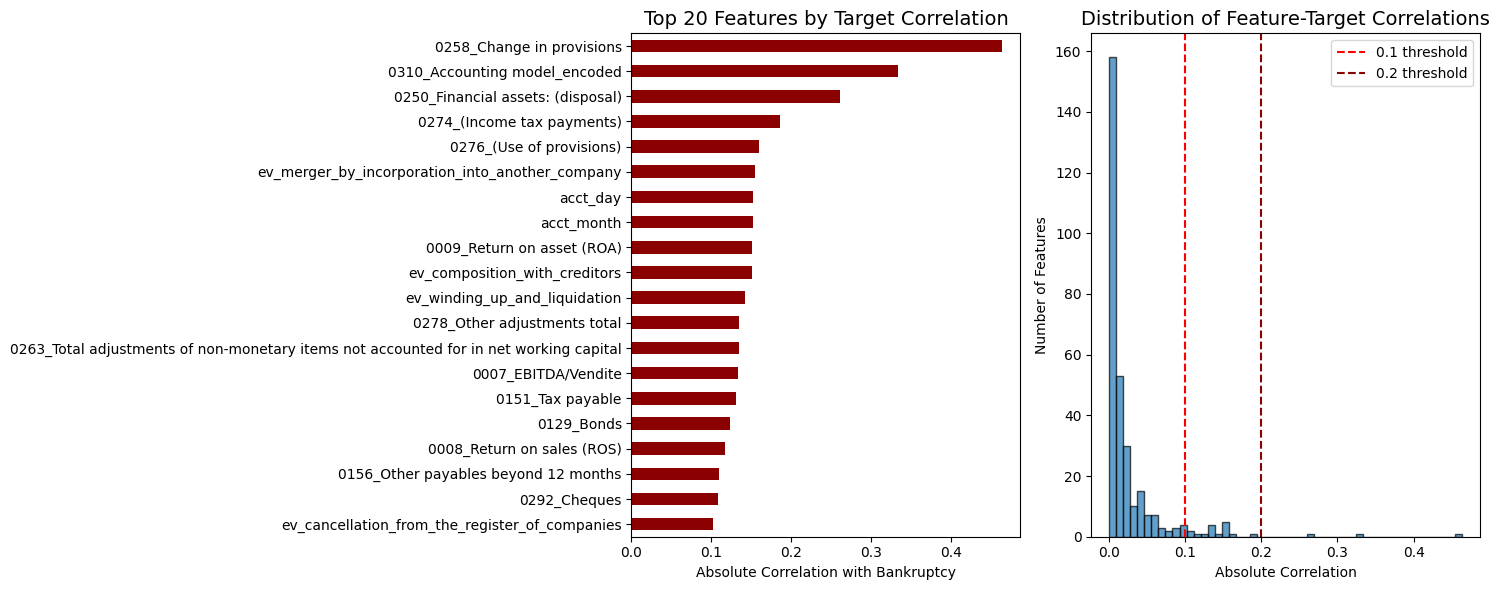


📊 FEATURE IMPORTANCE BY TYPE:
Average correlation with target:
  - Event features: 0.0544
  - Financial features: 0.0236

⚠️ Features with correlation < 0.01: 164
These features have almost no predictive power


In [ ]:
#@title Analyze Correlations with Target Variable
# Calculate correlations with target
feature_cols = [col for col in df_ready_clean.columns if col not in ['Tax code number', 'Year', 'Target']]
target_correlations = df_ready_clean[feature_cols].corrwith(df_ready_clean['Target']).abs().sort_values(ascending=False)

print("🎯 TOP FEATURES CORRELATED WITH BANKRUPTCY (Target)")
print("=" * 80)
print("Top 30 most predictive features:")
print(target_correlations.head(30).to_frame('Correlation with Target'))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Top features bar plot
target_correlations.head(20).plot(kind='barh', ax=ax1, color='darkred')
ax1.set_title('Top 20 Features by Target Correlation', fontsize=14)
ax1.set_xlabel('Absolute Correlation with Bankruptcy')
ax1.invert_yaxis()

# Distribution of correlations
ax2.hist(target_correlations.values, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0.1, color='red', linestyle='--', label='0.1 threshold')
ax2.axvline(x=0.2, color='darkred', linestyle='--', label='0.2 threshold')
ax2.set_title('Distribution of Feature-Target Correlations', fontsize=14)
ax2.set_xlabel('Absolute Correlation')
ax2.set_ylabel('Number of Features')
ax2.legend()

plt.tight_layout()
plt.show()

# Analyze by feature type
print("\n📊 FEATURE IMPORTANCE BY TYPE:")
event_features = [f for f in feature_cols if f.startswith('ev_')]
financial_features = [f for f in feature_cols if f not in event_features]

event_corr = target_correlations[event_features].mean()
financial_corr = target_correlations[financial_features].mean()

print(f"Average correlation with target:")
print(f"  - Event features: {event_corr:.4f}")
print(f"  - Financial features: {financial_corr:.4f}")

# Features with very low correlation
low_corr_features = target_correlations[target_correlations < 0.01]
print(f"\n⚠️ Features with correlation < 0.01: {len(low_corr_features)}")
print("These features have almost no predictive power")

In [ ]:
#@title Final Data Quality Check Before Modeling
print("✅ FINAL DATA QUALITY CHECKLIST")
print("=" * 80)

# 1. Data types
print("1. Data Types:")
print(f"   - All numeric: {'✓' if df_ready_clean.select_dtypes(include=['object']).empty else '✗'}")
print(f"   - Shape: {df_ready_clean.shape}")

# 2. Missing values
missing_pct = (df_ready_clean.isnull().sum() / len(df_ready_clean) * 100)
print(f"\n2. Missing Values:")
print(f"   - Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"   - Columns with >90% missing: {(missing_pct > 90).sum()}")

# 3. Target distribution
print(f"\n3. Target Distribution:")
print(f"   - Overall: {df_ready_clean['Target'].mean():.2%} bankruptcy rate")
print(f"   - Class ratio: {(df_ready_clean['Target']==0).sum()/(df_ready_clean['Target']==1).sum():.1f}:1")

# 4. Temporal splits
print(f"\n4. Temporal Splits:")
for years, name in [((2014, 2018), 'Train'), ((2019, 2019), 'Valid'), ((2020, 2022), 'Test')]:
    mask = df_ready_clean['Year'].between(years[0], years[1])
    print(f"   - {name}: {mask.sum():,} samples, {df_ready_clean[mask]['Target'].mean():.2%} positive")

# 5. Key features
print(f"\n5. Feature Summary:")
print(f"   - Total features: {len(feature_cols)}")
print(f"   - Event features: {len([f for f in feature_cols if f.startswith('ev_')])}")
print(f"   - Features with >0.1 target correlation: {(target_correlations > 0.1).sum()}")

print("\n🚀 Ready for modeling? Let's check:")
ready_checks = [
    ("No string columns", df_ready_clean.select_dtypes(include=['object']).empty),
    ("Have target variable", 'Target' in df_ready_clean.columns),
    ("Have temporal splits", df_ready_clean['Year'].min() < df_ready_clean['Year'].max()),
    ("Have both classes", df_ready_clean['Target'].nunique() == 2),
    ("Reasonable number of features", len(feature_cols) > 10)
]

all_ready = all(check[1] for check in ready_checks)
for check_name, check_result in ready_checks:
    print(f"   {'✓' if check_result else '✗'} {check_name}")

if all_ready:
    print("\n✅ ALL SYSTEMS GO! Ready to build models!")
else:
    print("\n⚠️ Some issues need addressing before modeling")

✅ FINAL DATA QUALITY CHECKLIST
1. Data Types:
   - All numeric: ✓
   - Shape: (16721, 404)

2. Missing Values:
   - Columns with >50% missing: 268
   - Columns with >90% missing: 168

3. Target Distribution:
   - Overall: 8.16% bankruptcy rate
   - Class ratio: 11.3:1

4. Temporal Splits:
   - Train: 11,376 samples, 5.73% positive
   - Valid: 1,710 samples, 14.27% positive
   - Test: 3,635 samples, 12.87% positive

5. Feature Summary:
   - Total features: 401
   - Event features: 42
   - Features with >0.1 target correlation: 20

🚀 Ready for modeling? Let's check:
   ✓ No string columns
   ✓ Have target variable
   ✓ Have temporal splits
   ✓ Have both classes
   ✓ Reasonable number of features

✅ ALL SYSTEMS GO! Ready to build models!


In [ ]:
#@title Quick Check on Missing Values and Final Data Prep


print("✅ FINAL PRE-MODELING CHECKS")
print("=" * 80)

# Check if we have the clean dataset ready
if 'df_ready_clean' not in locals():
    print("⚠️ Need to run data cleaning first!")
else:
    # Remove columns with too many missing values
    missing_pct = (df_ready_clean.isnull().sum() / len(df_ready_clean) * 100)
    high_missing_cols = missing_pct[missing_pct > 90].index.tolist()

    print(f"Removing {len(high_missing_cols)} columns with >90% missing values")
    df_model_ready = df_ready_clean.drop(columns=high_missing_cols, errors='ignore')

    # Final feature list
    feature_cols = [col for col in df_model_ready.columns
                   if col not in ['Tax code number', 'Year', 'Target']]

    print(f"\nFinal dataset shape: {df_model_ready.shape}")
    print(f"Features for modeling: {len(feature_cols)}")
    print(f"Target rate: {df_model_ready['Target'].mean():.2%}")

    # Class weights for modeling - FIX: use numpy array
    classes = np.array([0, 1])
    class_weights = compute_class_weight('balanced', classes=classes, y=df_model_ready['Target'])
    class_weight_dict = dict(zip(classes, class_weights))

    print(f"\nClass weights for balanced training:")
    print(f"  Class 0 (healthy): {class_weight_dict[0]:.2f}")
    print(f"  Class 1 (failure): {class_weight_dict[1]:.2f}")
    print(f"  XGBoost scale_pos_weight: {class_weight_dict[1]/class_weight_dict[0]:.2f}")

✅ FINAL PRE-MODELING CHECKS
Removing 168 columns with >90% missing values

Final dataset shape: (16721, 236)
Features for modeling: 233
Target rate: 8.16%

Class weights for balanced training:
  Class 0 (healthy): 0.54
  Class 1 (failure): 6.13
  XGBoost scale_pos_weight: 11.26


### MODEL

In [ ]:
#@title 🚀 Comprehensive Model Comparison with Realistic Data Splits

#================================================================================
# CONFIGURATION PARAMETERS - MODIFY THESE AS NEEDED
#================================================================================

# Realistic bankruptcy rates for validation and test sets
VALIDATION_SET_FAILURE_RATE = 0.02  # 8% bankruptcy rate for 2019
TEST_SET_FAILURE_RATE = 0.02        # 8% bankruptcy rate for 2020-2022

# Optuna Settings

MODEL_TRIALS = {
    'logistic':        100,    # Fewer trials for simple model
    'random_forest':   350,   # Medium complexity
    'xgboost':         1000,   # Full trials
    'lightgbm':        1000,   # Full trials
    'neural_network':  150,   # Medium complexity
    'svm':             150    # SVM optimization
}
"""
MODEL_TRIALS = {
    'logistic':        2,    # Fewer trials for simple model
    'random_forest':   2,   # Medium complexity
    'xgboost':         2,   # Full trials
    'lightgbm':        2,   # Full trials
    'neural_network':  2,   # Medium complexity
    'svm':             2    # SVM optimization
}
"""

OPTUNA_TIMEOUT = 21000  # Timeout in seconds per model
USE_PRUNING = True  # Set to True to enable early stopping of bad trials

# Pruning configuration (only used if USE_PRUNING is True)
PRUNING_N_STARTUP_TRIALS = 5  # Number of trials before pruning starts
PRUNING_N_WARMUP_STEPS = 10   # Number of steps before pruning evaluation
PRUNING_INTERVAL_STEPS = 1    # Interval between pruning checks

# Model Training Settings
RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 50
MAX_ITERATIONS = 300
CV_FOLDS = 3  # Number of cross-validation folds

# Validation Strategy
USE_VALIDATION_SET = True  # If True, use validation set; if False, use CV for all models

# Hyperparameter Search Ranges
PARAM_RANGES = {
    'logistic': {
        'C': (0.001, 3.0),  # Inverse regularization strength (low after tests)
    },
    'random_forest': {
        'n_estimators': (100, 1700),
        'max_depth': (7, 30),
        'min_samples_split': (2, 30),
        'min_samples_leaf': (1, 20),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    'xgboost': {
        'max_depth': (2, 15),
        'learning_rate': (0.003, 0.4),
        'n_estimators': (50, 600),
        'subsample': (0.1, 1.0),
        'colsample_bytree': (0.6, 1),   # bound [0,1]
        'reg_alpha': (0.0005, 10.0),
        'reg_lambda': (0.001, 10.0)
    },
    'lightgbm': {
        'num_leaves': (15, 400),
        'learning_rate': (0.001, 0.3),
        'n_estimators': (10, 500),
        'feature_fraction': (0.5, 1),   # bound [0,1]
        'bagging_fraction': (0.5, 0.9), # bound [0,1]
        'bagging_freq': (1, 40),
        'reg_alpha': (0.001, 10.0),
        'reg_lambda': (0.001, 10.0)
    },
    'neural_network': {
        'n_layers': (1, 30),  # Number of hidden layers
        'neurons_per_layer': (10, 400),  # Same range for all layers
        'dropout_rate': (0.1, 0.5),
        'learning_rate': (0.00005, 0.002),
        'batch_size': [1024, 2048, 4096],
        'epochs': (100, 400)
    },
    'svm': {
        'C': (0.001, 10.0),           # Expanded range
        'gamma': (0.00001, 10.0),     # For RBF kernel
        'kernel': ['rbf', 'linear'],  # Only RBF and linear
        'class_weight': ['balanced'],  # Keep this
        'tol': (0.002, 0.01)          # Convergence tolerance
    }
}

# SETUP
import gc  # For garbage collection
import psutil  # For memory monitoring
import os
import tensorflow as tf

# GPU Memory Management
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"GPU memory growth setting failed: {e}")

# Suppress Optuna logging
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Memory monitoring function
def get_memory_usage():
    """Get current memory usage in GB"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024 / 1024

def clean_memory():
    """Force garbage collection and clear memory"""
    gc.collect()
    if 'torch' in sys.modules:
        import torch
        torch.cuda.empty_cache()

#================================================================================
# CUSTOM HISTORICAL IMPUTER
#================================================================================

class HistoricalImputer:
    """
    Imputes missing values using:
    1. Linear trend from past 2 years if available
    2. Past year data if only 1 year available
    3. Global median as fallback
    """
    def __init__(self, company_col='Company_ID', year_col='Year'):
        self.company_col = company_col
        self.year_col = year_col
        self.global_medians = {}
        self.feature_cols = None

    def fit(self, X, y=None):
        """Fit the imputer on training data to learn global medians"""
        # Store feature columns (excluding company and year identifiers)
        self.feature_cols = [col for col in X.columns
                           if col not in [self.company_col, self.year_col]]

        # Calculate global medians for each feature
        for col in self.feature_cols:
            self.global_medians[col] = X[col].median()

        return self

    def transform(self, X):
        """Transform the data by imputing missing values"""
        X_imputed = X.copy()

        # Get unique companies and years
        companies = X[self.company_col].unique() if self.company_col in X.columns else [None]
        years = sorted(X[self.year_col].unique()) if self.year_col in X.columns else [None]

        for company in companies:
            for year in years:
                # Get current row(s)
                if company is not None and year is not None:
                    mask = (X[self.company_col] == company) & (X[self.year_col] == year)
                elif year is not None:
                    mask = X[self.year_col] == year
                else:
                    mask = slice(None)  # All rows

                if not any(mask):
                    continue

                # For each feature, impute missing values
                for col in self.feature_cols:
                    if X_imputed.loc[mask, col].isna().any():
                        # Try to get historical data
                        imputed_value = None

                        if company is not None and year is not None:
                            # Try linear trend from past 2 years
                            hist_mask_2y = (X[self.company_col] == company) & \
                                         (X[self.year_col] == year - 2)
                            hist_mask_1y = (X[self.company_col] == company) & \
                                         (X[self.year_col] == year - 1)

                            val_2y = X.loc[hist_mask_2y, col].values
                            val_1y = X.loc[hist_mask_1y, col].values

                            if len(val_1y) > 0 and not np.isnan(val_1y[0]):
                                if len(val_2y) > 0 and not np.isnan(val_2y[0]):
                                    # Linear extrapolation
                                    imputed_value = val_1y[0] + (val_1y[0] - val_2y[0])
                                else:
                                    # Only 1 year available, use it
                                    imputed_value = val_1y[0]

                        # Fallback to global median
                        if imputed_value is None or np.isnan(imputed_value):
                            imputed_value = self.global_medians[col]

                        # Apply imputation
                        X_imputed.loc[mask, col] = X_imputed.loc[mask, col].fillna(imputed_value)

        return X_imputed

    def fit_transform(self, X, y=None):
        """Fit and transform in one step"""
        return self.fit(X, y).transform(X)

#================================================================================
# ENHANCED PROGRESS TRACKING SYSTEM WITH TRIAL DETAILS
#================================================================================

class ModelTracker:
    def __init__(self, total_models=6):
        self.total_models = total_models
        self.current_model = 0
        self.results_summary = []
        self.start_time = time.time()
        self.trial_stats = {}
        self.model_start_times = {}
        self.optimization_history = {}  # Store optimization history

    def update(self, model_name, status, metrics=None, trial=None, total_trials=None, study=None):
        self.current_time = time.time() - self.start_time

        # Track model start time
        if model_name not in self.model_start_times:
            self.model_start_times[model_name] = time.time()

        # Clear and redraw
        clear_output(wait=True)

        # Header
        print("🚀 COMPREHENSIVE BANKRUPTCY PREDICTION MODEL COMPARISON")
        print("=" * 80)
        print(f"⏱️  Total Elapsed Time: {self.format_time(self.current_time)}")
        print(f"🔧 Configuration: Optuna=ON | CV Folds={CV_FOLDS} | Pruning={'ON' if USE_PRUNING else 'OFF'}")
        print(f"💾 Memory Usage: {get_memory_usage():.2f} GB / 35 GB")
        print("=" * 80)

        # Current model status
        model_time = time.time() - self.model_start_times[model_name]
        print(f"\n📊 Current Model: {model_name}")
        print(f"📈 Status: {status}")
        print(f"⏱️  Model Time: {self.format_time(model_time)}")

        # Enhanced Optuna progress bar with trial details
        if trial is not None and total_trials is not None:
            progress = trial / total_trials
            bar_length = 50
            filled_length = int(bar_length * progress)
            bar = '█' * filled_length + '░' * (bar_length - filled_length)

            # Get additional trial statistics if study is provided
            trial_info = f"{trial}/{total_trials} trials"
            if study is not None:
                completed_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
                pruned_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
                failed_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])

                trial_info = f"{completed_trials}/{total_trials} trials"
                if pruned_trials > 0 or failed_trials > 0:
                    trial_info += f" (✂️{pruned_trials} pruned, ❌{failed_trials} failed)"

                # Store stats for final summary
                self.trial_stats[model_name] = {
                    'completed': completed_trials,
                    'pruned': pruned_trials,
                    'failed': failed_trials,
                    'target': total_trials,
                    'efficiency': (completed_trials / (trial + 1)) * 100 if trial > 0 else 0
                }

                # Show best score and improvement
                try:
                    if study.best_trial is not None:
                        trial_info += f" | Best: {study.best_value:.4f}"

                        # Track optimization history
                        if model_name not in self.optimization_history:
                            self.optimization_history[model_name] = []
                        self.optimization_history[model_name].append(study.best_value)

                        # Show improvement from first trial
                        if len(self.optimization_history[model_name]) > 1:
                            first_score = self.optimization_history[model_name][0]
                            improvement = ((study.best_value - first_score) / first_score) * 100
                            trial_info += f" (↑{improvement:+.1f}%)"

                        # Show estimated time remaining
                        if completed_trials > 0:
                            avg_trial_time = model_time / (trial + 1)
                            remaining_trials = total_trials - trial
                            est_remaining = avg_trial_time * remaining_trials
                            trial_info += f" | ETA: {self.format_time(est_remaining)}"

                except ValueError:
                    # No completed trials yet
                    pass

            print(f"🔍 Optimization: [{bar}] {trial_info}")

            # Fixed parameter display section
            if study is not None and len(study.trials) > 0:
                # Try to get the last running trial
                running_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.RUNNING]
                if running_trials:
                    current_trial = running_trials[-1]
                    if hasattr(current_trial, 'params') and current_trial.params:
                        print(f"🔬 Current Trial Parameters:")
                        for param, value in current_trial.params.items():
                            if isinstance(value, float):
                                print(f"   • {param}: {value:.4f}")
                            else:
                                print(f"   • {param}: {value}")
                else:
                    # If no running trial, show the most recent trial
                    if study.trials:
                        latest_trial = study.trials[-1]
                        if hasattr(latest_trial, 'params') and latest_trial.params:
                            print(f"🔬 Latest Trial Parameters:")
                            for param, value in latest_trial.params.items():
                                if isinstance(value, float):
                                    print(f"   • {param}: {value:.4f}")
                                else:
                                    print(f"   • {param}: {value}")

        # Overall progress
        print(f"\n🏃 Overall Progress: {self.current_model}/{self.total_models} models completed")
        overall_progress = self.current_model / self.total_models
        bar_length = 50
        filled_length = int(bar_length * overall_progress)
        bar = '█' * filled_length + '░' * (bar_length - filled_length)
        print(f"   [{bar}] {overall_progress*100:.0f}%")

        # Estimated total time
        if self.current_model > 0:
            avg_model_time = self.current_time / self.current_model
            est_total_time = avg_model_time * self.total_models
            est_remaining_time = est_total_time - self.current_time
            print(f"   ⏳ Estimated remaining time: {self.format_time(est_remaining_time)}")

        # Results summary with rankings
        if self.results_summary:
            print("\n📊 COMPLETED MODELS SUMMARY:")
            print("-" * 80)
            print(f"{'Rank':<6} {'Model':<20} {'Train Time':<12} {'Test ROC-AUC':<12} {'Trials':<15} {'Status':<10}")
            print("-" * 80)

            # Sort by ROC-AUC for ranking
            sorted_results = sorted(self.results_summary,
                                  key=lambda x: float(x['auc'].replace('f', '')),
                                  reverse=True)

            for i, result in enumerate(sorted_results, 1):
                model = result['model']
                trials_info = ""
                if model in self.trial_stats:
                    stats = self.trial_stats[model]
                    trials_info = f"{stats['completed']}/{stats['target']}"
                    if stats['pruned'] > 0:
                        trials_info += f" (✂️{stats['pruned']})"

                print(f"{i:<6} {result['model']:<20} {result['time']:<12} {result['auc']:<12} {trials_info:<15} ✅")

            # Show best performing model so far
            if sorted_results:
                print(f"\n🏆 Current Best: {sorted_results[0]['model']} (ROC-AUC: {sorted_results[0]['auc']})")

        # Model-specific insights
        if self.current_model > 0 and self.trial_stats:
            print("\n📈 OPTIMIZATION INSIGHTS:")
            total_trials_run = sum(stats['completed'] + stats['pruned'] + stats['failed']
                                 for stats in self.trial_stats.values())
            total_completed = sum(stats['completed'] for stats in self.trial_stats.values())

            print(f"   • Total trials executed: {total_trials_run}")
            print(f"   • Overall success rate: {(total_completed/total_trials_run)*100:.1f}%")
            print(f"   • Average time per model: {self.format_time(self.current_time/self.current_model)}")

            if USE_PRUNING and any(stats['pruned'] > 0 for stats in self.trial_stats.values()):
                total_pruned = sum(stats['pruned'] for stats in self.trial_stats.values())
                print(f"   • Trials pruned (time saved): {total_pruned}")

        if metrics:
            print(f"\n🎯 Current Metrics: {metrics}")

    def format_time(self, seconds):
        """Format seconds into human-readable time."""
        if seconds < 60:
            return f"{seconds:.1f}s"
        elif seconds < 3600:
            return f"{seconds/60:.1f}m"
        else:
            hours = seconds // 3600
            minutes = (seconds % 3600) // 60
            return f"{hours:.0f}h {minutes:.0f}m"

    def complete_model(self, model_name, train_time, test_auc):
        self.current_model += 1
        self.results_summary.append({
            'model': model_name,
            'time': f"{train_time:.1f}s",
            'auc': f"{test_auc:.4f}"
        })

    def get_trial_summary(self):
        """Return a summary of trial statistics for final report"""
        return self.trial_stats

# Initialize tracker
tracker = ModelTracker(total_models=6)

#================================================================================
# DATA PREPARATION WITH REALISTIC SPLITS
#================================================================================

tracker.update("Data Preparation", "Creating realistic data splits...")

def create_realistic_split(df, target_years, target_failure_rate, random_state=42):
    """
    Create a realistic data split with specified bankruptcy rate.

    Parameters:
    - df: Full dataframe
    - target_years: List of years to include in this split
    - target_failure_rate: Desired proportion of bankruptcies (e.g., 0.08 for 8%)
    - random_state: Random seed for reproducibility

    Returns:
    - Sampled dataframe with realistic bankruptcy rate
    """
    # Filter for target years
    year_df = df[df['Year'].isin(target_years)].copy()

    # Separate positive (bankruptcy) and negative (healthy) cases
    positives = year_df[year_df['Target'] == 1]
    negatives = year_df[year_df['Target'] == 0]

    # Calculate how many negatives we need
    n_positives = len(positives)
    if n_positives == 0:
        print(f"Warning: No positive cases found for years {target_years}")
        return pd.DataFrame()

    # Calculate required negatives to achieve target failure rate
    # If failure_rate = n_pos / (n_pos + n_neg), then:
    # n_neg = n_pos * (1 - failure_rate) / failure_rate
    required_negatives = int(n_positives * (1 - target_failure_rate) / target_failure_rate)

    # Sample negatives
    if required_negatives > len(negatives):
        print(f"Warning: Not enough negative cases. Using all {len(negatives)} available.")
        sampled_negatives = negatives
    else:
        sampled_negatives = negatives.sample(n=required_negatives, random_state=random_state)

    # Combine and shuffle
    result = pd.concat([positives, sampled_negatives]).sample(frac=1, random_state=random_state)

    actual_failure_rate = result['Target'].mean()
    print(f"Created split for years {target_years}: {len(result)} samples, "
          f"failure rate: {actual_failure_rate:.2%} (target: {target_failure_rate:.2%})")

    return result

# Create splits based on USE_VALIDATION_SET
if USE_VALIDATION_SET:
    # Training set: 2014-2018
    train_mask = df_model_ready['Year'].between(2014, 2018)
    X_train = df_model_ready[train_mask][feature_cols]
    y_train = df_model_ready[train_mask]['Target']

    # Validation set: 2019 with realistic 8% bankruptcy rate
    valid_df = create_realistic_split(df_model_ready, [2019], VALIDATION_SET_FAILURE_RATE, RANDOM_STATE)
    X_valid = valid_df[feature_cols] if not valid_df.empty else pd.DataFrame()
    y_valid = valid_df['Target'] if not valid_df.empty else pd.Series()
else:
    # Training set: 2014-2019 (include 2019 in training when not using validation set)
    train_mask = df_model_ready['Year'].between(2014, 2019)
    X_train = df_model_ready[train_mask][feature_cols]
    y_train = df_model_ready[train_mask]['Target']

    # No validation set
    X_valid = pd.DataFrame()
    y_valid = pd.Series()

# Test set: Always 2020-2022 with realistic 8% bankruptcy rate
test_df = create_realistic_split(df_model_ready, [2020, 2021, 2022], TEST_SET_FAILURE_RATE, RANDOM_STATE)
X_test = test_df[feature_cols] if not test_df.empty else pd.DataFrame()
y_test = test_df['Target'] if not test_df.empty else pd.Series()

# Calculate class weights from training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_weight_dict = {0: 1.0, 1: scale_pos_weight}

# Prepare data with company and year information for historical imputation
# We need to include Company_ID and Year for the imputer
company_col = 'Company_ID' if 'Company_ID' in df_model_ready.columns else None
year_col = 'Year' if 'Year' in df_model_ready.columns else None

# If we have company/year info, prepare extended datasets
if company_col and year_col:
    X_train_with_info = df_model_ready[train_mask][[company_col, year_col] + feature_cols]
    X_valid_with_info = valid_df[[company_col, year_col] + feature_cols] if not valid_df.empty else pd.DataFrame()
    X_test_with_info = test_df[[company_col, year_col] + feature_cols] if not test_df.empty else pd.DataFrame()
else:
    # Fallback to regular datasets without company/year info
    X_train_with_info = X_train
    X_valid_with_info = X_valid
    X_test_with_info = X_test

# Save feature names
feature_names = list(feature_cols)

tracker.update("Data Preparation", "Data splits created successfully!",
              f"Train: {X_train.shape} (imbalance: {scale_pos_weight:.1f}:1) | "
              f"Valid: {X_valid.shape} | Test: {X_test.shape}")
time.sleep(2)

# Verify we have data
if X_test.empty or y_test.empty:
    raise ValueError("Test set is empty! Check your data and year ranges.")

# Initialize storage
results = []
models = {}
predictions = {}
best_params = {}

#================================================================================
# HELPER FUNCTIONS
#================================================================================

def create_neural_network(input_dim, n_layers, neurons_per_layer, dropout_rate, learning_rate):
    """Create a neural network with dynamic number of layers."""
    model = keras.Sequential()

    # Input layer
    model.add(layers.Input(shape=(input_dim,)))

    # Hidden layers
    for i in range(n_layers):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
        model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

def sanitize_features(df):
    """Sanitize feature names for LightGBM only"""
    # Handle both DataFrame and numpy array inputs
    if isinstance(df, pd.DataFrame):
        df = df.copy()
        df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in df.columns]
        return df
    else:
        # If it's a numpy array, just return it as-is
        # The sanitization should have been done earlier in the pipeline
        return df
#================================================================================
# MODEL 1: LOGISTIC REGRESSION
#================================================================================

tracker.update("Logistic Regression", "Initializing...")

def objective_logistic(trial):
    current_study = trial.study
    tracker.update("Logistic Regression", "Optimizing hyperparameters...",
                  trial=trial.number + 1, total_trials=MODEL_TRIALS['logistic'],
                  study=current_study)

    C = trial.suggest_float('C', *PARAM_RANGES['logistic']['C'], log=True)

    # Use pipeline with historical imputer
    if company_col and year_col:
        pipeline = Pipeline([
            ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
            ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty='l1',
                solver='liblinear',
                C=C,
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ])
    else:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty='l1',
                solver='liblinear',
                C=C,
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ])

    # Use validation set or CV based on configuration
    if USE_VALIDATION_SET and not X_valid.empty:
        pipeline.fit(X_train_with_info, y_train)
        y_pred = pipeline.predict_proba(X_valid_with_info)[:, 1]
        return roc_auc_score(y_valid, y_pred)
    else:
        # Use cross-validation
        cv_scores = cross_val_score(
            pipeline, X_train_with_info, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

# Create study with or without pruning
if USE_PRUNING:
    study_logistic = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner(
            n_startup_trials=PRUNING_N_STARTUP_TRIALS,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
            interval_steps=PRUNING_INTERVAL_STEPS
        )
    )
else:
    study_logistic = optuna.create_study(direction='maximize')

study_logistic.optimize(objective_logistic,
                   n_trials=MODEL_TRIALS['logistic'],
                   timeout=OPTUNA_TIMEOUT)
best_params['Logistic_L1'] = study_logistic.best_params
C_optimal = study_logistic.best_params['C']
tracker.update("Logistic Regression", "Optimization complete!",
              f"Best C: {C_optimal:.4f}")

# Train final model
tracker.update("Logistic Regression", "Training final model...")

if company_col and year_col:
    log_pipeline = Pipeline([
        ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
        ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=C_optimal,
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])
else:
    log_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=C_optimal,
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

start_time = time.time()
log_pipeline.fit(X_train_with_info, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_log = log_pipeline.predict_proba(X_train_with_info)[:, 1]
y_valid_pred_log = log_pipeline.predict_proba(X_valid_with_info)[:, 1] if not X_valid.empty else np.array([])
y_test_pred_log = log_pipeline.predict_proba(X_test_with_info)[:, 1]

# Store results
models['Logistic_L1'] = log_pipeline
predictions['Logistic_L1'] = {
    'train': y_train_pred_log,
    'valid': y_valid_pred_log,
    'test': y_test_pred_log
}

test_roc = roc_auc_score(y_test, y_test_pred_log)
results.append({
    'Model': 'Logistic_L1',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_log),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_log) if not y_valid.empty else np.nan,
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_log),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_log)
})

tracker.complete_model("Logistic_L1", train_time, test_roc)
tracker.update("Logistic Reg", "Completed!", f"Test ROC-AUC: {test_roc:.4f}")

# Clean up memory
clean_memory()
time.sleep(1)

#================================================================================
# MODEL 2: RANDOM FOREST
#================================================================================

tracker.update("Random Forest", "Initializing...")

def objective_rf(trial):
    current_study = trial.study
    tracker.update("Random Forest", "Optimizing hyperparameters...",
                  trial=trial.number + 1, total_trials=MODEL_TRIALS['random_forest'],
                  study=current_study)

    params = {
        'n_estimators': trial.suggest_int('n_estimators', *PARAM_RANGES['random_forest']['n_estimators']),
        'max_depth': trial.suggest_int('max_depth', *PARAM_RANGES['random_forest']['max_depth']),
        'min_samples_split': trial.suggest_int('min_samples_split', *PARAM_RANGES['random_forest']['min_samples_split']),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', *PARAM_RANGES['random_forest']['min_samples_leaf']),
        'max_features': trial.suggest_categorical('max_features', PARAM_RANGES['random_forest']['max_features']),
        'bootstrap': trial.suggest_categorical('bootstrap', PARAM_RANGES['random_forest']['bootstrap'])
    }

    # Use pipeline with historical imputer
    if company_col and year_col:
        pipeline = Pipeline([
            ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
            ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
            ('classifier', RandomForestClassifier(
                **params,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    else:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('classifier', RandomForestClassifier(
                **params,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    # Use validation set or CV based on configuration
    if USE_VALIDATION_SET and not X_valid.empty:
        pipeline.fit(X_train_with_info, y_train)
        y_pred = pipeline.predict_proba(X_valid_with_info)[:, 1]
        return roc_auc_score(y_valid, y_pred)
    else:
        cv_scores = cross_val_score(
            pipeline, X_train_with_info, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

# Create study with or without pruning
if USE_PRUNING:
    study_rf = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner(
            n_startup_trials=PRUNING_N_STARTUP_TRIALS,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
            interval_steps=PRUNING_INTERVAL_STEPS
        )
    )
else:
    study_rf = optuna.create_study(direction='maximize')

study_rf.optimize(objective_rf, n_trials=MODEL_TRIALS['random_forest'], timeout=OPTUNA_TIMEOUT)
best_params['RandomForest'] = study_rf.best_params
rf_params = study_rf.best_params
tracker.update("Random Forest", "Optimization complete!",
              f"Best n_estimators: {rf_params['n_estimators']}")

# Train final model
tracker.update("Random Forest", "Training final model...")

if company_col and year_col:
    rf_pipeline = Pipeline([
        ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
        ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
        ('classifier', RandomForestClassifier(
            **rf_params,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
else:
    rf_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(
            **rf_params,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

start_time = time.time()
rf_pipeline.fit(X_train_with_info, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_rf = rf_pipeline.predict_proba(X_train_with_info)[:, 1]
y_valid_pred_rf = rf_pipeline.predict_proba(X_valid_with_info)[:, 1] if not X_valid.empty else np.array([])
y_test_pred_rf = rf_pipeline.predict_proba(X_test_with_info)[:, 1]

# Store results
models['RandomForest'] = rf_pipeline
predictions['RandomForest'] = {
    'train': y_train_pred_rf,
    'valid': y_valid_pred_rf,
    'test': y_test_pred_rf
}

test_roc = roc_auc_score(y_test, y_test_pred_rf)
results.append({
    'Model': 'RandomForest',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_rf),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_rf) if not y_valid.empty else np.nan,
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_rf),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_rf)
})

tracker.complete_model("RandomForest", train_time, test_roc)
tracker.update("Random Forest", "Completed!", f"Test ROC-AUC: {test_roc:.4f}")

# Clean up memory
clean_memory()
time.sleep(1)

#================================================================================
# MODEL 3: XGBOOST
#================================================================================

tracker.update("XGBoost", "Initializing...")

def objective_xgb(trial):
    current_study = trial.study
    tracker.update("XGBoost", "Optimizing hyperparameters...",
                  trial=trial.number + 1, total_trials=MODEL_TRIALS['xgboost'],
                  study=current_study)

    params = {
        'max_depth': trial.suggest_int('max_depth', *PARAM_RANGES['xgboost']['max_depth']),
        'learning_rate': trial.suggest_float('learning_rate', *PARAM_RANGES['xgboost']['learning_rate'], log=True),
        'n_estimators': trial.suggest_int('n_estimators', *PARAM_RANGES['xgboost']['n_estimators']),
        'subsample': trial.suggest_float('subsample', *PARAM_RANGES['xgboost']['subsample']),
        'colsample_bytree': trial.suggest_float('colsample_bytree', *PARAM_RANGES['xgboost']['colsample_bytree']),
        'reg_alpha': trial.suggest_float('reg_alpha', *PARAM_RANGES['xgboost']['reg_alpha'], log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', *PARAM_RANGES['xgboost']['reg_lambda'], log=True)
    }

    # Use pipeline with historical imputer
    if company_col and year_col:
        pipeline = Pipeline([
            ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
            ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
            ('classifier', xgb.XGBClassifier(
                **params,
                objective='binary:logistic',
                scale_pos_weight=scale_pos_weight,
                seed=RANDOM_STATE,
                eval_metric='auc',
                verbosity=0
            ))
        ])
    else:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('classifier', xgb.XGBClassifier(
                **params,
                objective='binary:logistic',
                scale_pos_weight=scale_pos_weight,
                seed=RANDOM_STATE,
                eval_metric='auc',
                verbosity=0
            ))
        ])

    # Use validation set or CV based on configuration
    if USE_VALIDATION_SET and not X_valid.empty:
        # For XGBoost with early stopping, we need to handle it differently
        imputer = HistoricalImputer(company_col=company_col, year_col=year_col) if company_col and year_col else SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_train_with_info)
        X_valid_imp = imputer.transform(X_valid_with_info)

        if company_col and year_col:
            X_train_imp = X_train_imp[feature_cols]
            X_valid_imp = X_valid_imp[feature_cols]

        model = xgb.XGBClassifier(
            **params,
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            seed=RANDOM_STATE,
            eval_metric='auc',
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbosity=0
        )

        model.fit(
            X_train_imp, y_train,
            eval_set=[(X_valid_imp, y_valid)],
            verbose=False
        )
        return model.best_score
    else:
        # Use CV if no validation set
        cv_scores = cross_val_score(
            pipeline, X_train_with_info, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

# Create study with or without pruning
if USE_PRUNING:
    study_xgb = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner(
            n_startup_trials=PRUNING_N_STARTUP_TRIALS,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
            interval_steps=PRUNING_INTERVAL_STEPS
        )
    )
else:
    study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(objective_xgb, n_trials=MODEL_TRIALS['xgboost'], timeout=OPTUNA_TIMEOUT)
best_params['XGBoost'] = study_xgb.best_params
xgb_params = study_xgb.best_params
tracker.update("XGBoost", "Optimization complete!",
              f"Best max_depth: {xgb_params['max_depth']}")

# Train final model
tracker.update("XGBoost", "Training final model...")

if company_col and year_col:
    xgb_pipeline = Pipeline([
        ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
        ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
        ('classifier', xgb.XGBClassifier(
            **xgb_params,
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            seed=RANDOM_STATE,
            eval_metric='auc',
            early_stopping_rounds=EARLY_STOPPING_ROUNDS if USE_VALIDATION_SET and not X_valid.empty else None,
            verbosity=0
        ))
    ])
else:
    xgb_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', xgb.XGBClassifier(
            **xgb_params,
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            seed=RANDOM_STATE,
            eval_metric='auc',
            early_stopping_rounds=EARLY_STOPPING_ROUNDS if USE_VALIDATION_SET and not X_valid.empty else None,
            verbosity=0
        ))
    ])

start_time = time.time()

# Handle early stopping for XGBoost
if USE_VALIDATION_SET and not X_valid.empty:
    # We need to manually handle the pipeline for early stopping
    imputer = xgb_pipeline.named_steps['imputer']
    X_train_imp = imputer.fit_transform(X_train_with_info)
    X_valid_imp = imputer.transform(X_valid_with_info)

    if company_col and year_col:
        X_train_imp = X_train_imp[feature_cols]
        X_valid_imp = X_valid_imp[feature_cols]

    xgb_pipeline.named_steps['classifier'].fit(
        X_train_imp, y_train,
        eval_set=[(X_valid_imp, y_valid)],
        verbose=False
    )
else:
    xgb_pipeline.fit(X_train_with_info, y_train)

train_time = time.time() - start_time

# Predictions
y_train_pred_xgb = xgb_pipeline.predict_proba(X_train_with_info)[:, 1]
y_valid_pred_xgb = xgb_pipeline.predict_proba(X_valid_with_info)[:, 1] if not X_valid.empty else np.array([])
y_test_pred_xgb = xgb_pipeline.predict_proba(X_test_with_info)[:, 1]

# Store results
models['XGBoost'] = xgb_pipeline
predictions['XGBoost'] = {
    'train': y_train_pred_xgb,
    'valid': y_valid_pred_xgb,
    'test': y_test_pred_xgb
}

test_roc = roc_auc_score(y_test, y_test_pred_xgb)
results.append({
    'Model': 'XGBoost',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_xgb),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_xgb) if not y_valid.empty else np.nan,
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_xgb),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_xgb)
})

tracker.complete_model("XGBoost", train_time, test_roc)
tracker.update("XGBoost", "Completed!",
              f"Test ROC-AUC: {test_roc:.4f}")

# Clean up memory
clean_memory()
time.sleep(1)

#================================================================================
# MODEL 4: LIGHTGBM
#================================================================================

tracker.update("LightGBM", "Initializing...")

def objective_lgb(trial):
    current_study = trial.study
    tracker.update("LightGBM", "Optimizing hyperparameters...",
                  trial=trial.number + 1, total_trials=MODEL_TRIALS['lightgbm'],
                  study=current_study)

    params = {
        'num_leaves': trial.suggest_int('num_leaves', *PARAM_RANGES['lightgbm']['num_leaves']),
        'learning_rate': trial.suggest_float('learning_rate', *PARAM_RANGES['lightgbm']['learning_rate'], log=True),
        'n_estimators': trial.suggest_int('n_estimators', *PARAM_RANGES['lightgbm']['n_estimators']),
        'feature_fraction': trial.suggest_float('feature_fraction', *PARAM_RANGES['lightgbm']['feature_fraction']),
        'bagging_fraction': trial.suggest_float('bagging_fraction', *PARAM_RANGES['lightgbm']['bagging_fraction']),
        'bagging_freq': trial.suggest_int('bagging_freq', *PARAM_RANGES['lightgbm']['bagging_freq']),
        'reg_alpha': trial.suggest_float('reg_alpha', *PARAM_RANGES['lightgbm']['reg_alpha'], log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', *PARAM_RANGES['lightgbm']['reg_lambda'], log=True)
    }

    # For LightGBM, we need to sanitize feature names
    # Create a custom transformer that sanitizes after imputation
    def sanitize_transformer(X):
        # If X is a DataFrame with company/year info, select feature columns first
        if isinstance(X, pd.DataFrame) and company_col and year_col and company_col in X.columns:
            X = X[feature_cols].copy()
        # Now sanitize if it's still a DataFrame
        if isinstance(X, pd.DataFrame):
            X_sanitized = sanitize_features(X)
            return X_sanitized
        else:
            # If it's already a numpy array, return as-is
            return X
    # Use pipeline with historical imputer
    if company_col and year_col:
        pipeline = Pipeline([
            ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
            ('sanitizer', FunctionTransformer(sanitize_transformer)),
            ('classifier', lgb.LGBMClassifier(
                **params,
                objective='binary',
                is_unbalance=True,
                boosting_type='gbdt',
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            ))
        ])
    else:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('sanitizer', FunctionTransformer(sanitize_features)),
            ('classifier', lgb.LGBMClassifier(
                **params,
                objective='binary',
                is_unbalance=True,
                boosting_type='gbdt',
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            ))
        ])

    # Use validation set or CV based on configuration
    if USE_VALIDATION_SET and not X_valid.empty:
        # For LightGBM with early stopping, we need to handle it differently
        imputer = HistoricalImputer(company_col=company_col, year_col=year_col) if company_col and year_col else SimpleImputer(strategy='median')
        X_train_imp = imputer.fit_transform(X_train_with_info)
        X_valid_imp = imputer.transform(X_valid_with_info)

        if company_col and year_col:
            X_train_imp = sanitize_features(X_train_imp[feature_cols])
            X_valid_imp = sanitize_features(X_valid_imp[feature_cols])
        else:
            X_train_imp = sanitize_features(X_train_imp)
            X_valid_imp = sanitize_features(X_valid_imp)

        model = lgb.LGBMClassifier(
            **params,
            objective='binary',
            is_unbalance=True,
            boosting_type='gbdt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train_imp, y_train,
            eval_set=[(X_valid_imp, y_valid)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(0)]
        )
        return model.best_score_['valid_0']['auc']
    else:
        # Use CV if no validation set
        cv_scores = cross_val_score(
            pipeline, X_train_with_info, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

# Create study with or without pruning
if USE_PRUNING:
    study_lgb = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner(
            n_startup_trials=PRUNING_N_STARTUP_TRIALS,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
            interval_steps=PRUNING_INTERVAL_STEPS
        )
    )
else:
    study_lgb = optuna.create_study(direction='maximize')

study_lgb.optimize(objective_lgb, n_trials=MODEL_TRIALS['lightgbm'], timeout=OPTUNA_TIMEOUT)
best_params['LightGBM'] = study_lgb.best_params
lgb_params = study_lgb.best_params
tracker.update("LightGBM", "Optimization complete!",
              f"Best num_leaves: {lgb_params['num_leaves']}")

# Train final model
tracker.update("LightGBM", "Training final model...")

# Create sanitize transformer
def sanitize_transformer(X):
    # If X is a DataFrame with company/year info, select feature columns first
    if isinstance(X, pd.DataFrame) and company_col and year_col and company_col in X.columns:
        X = X[feature_cols].copy()
    # Now sanitize if it's still a DataFrame
    if isinstance(X, pd.DataFrame):
        X_sanitized = sanitize_features(X)
        return X_sanitized
    else:
        # If it's already a numpy array, return as-is
        return X
if company_col and year_col:
    lgb_pipeline = Pipeline([
        ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
        ('sanitizer', FunctionTransformer(sanitize_transformer)),
        ('classifier', lgb.LGBMClassifier(
            **lgb_params,
            objective='binary',
            is_unbalance=True,
            boosting_type='gbdt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ))
    ])
else:
    lgb_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('sanitizer', FunctionTransformer(sanitize_features)),
        ('classifier', lgb.LGBMClassifier(
            **lgb_params,
            objective='binary',
            is_unbalance=True,
            boosting_type='gbdt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        ))
    ])

start_time = time.time()

# Handle early stopping for LightGBM
if USE_VALIDATION_SET and not X_valid.empty:
    # We need to manually handle the pipeline for early stopping
    imputer = lgb_pipeline.named_steps['imputer']
    X_train_imp = imputer.fit_transform(X_train_with_info)
    X_valid_imp = imputer.transform(X_valid_with_info)

    if company_col and year_col:
        X_train_imp = sanitize_features(X_train_imp[feature_cols])
        X_valid_imp = sanitize_features(X_valid_imp[feature_cols])
    else:
        X_train_imp = sanitize_features(X_train_imp)
        X_valid_imp = sanitize_features(X_valid_imp)

    lgb_pipeline.named_steps['classifier'].fit(
        X_train_imp, y_train,
        eval_set=[(X_valid_imp, y_valid)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(0)]
    )
else:
    lgb_pipeline.fit(X_train_with_info, y_train)

train_time = time.time() - start_time

# Predictions
y_train_pred_lgb = lgb_pipeline.predict_proba(X_train_with_info)[:, 1]
y_valid_pred_lgb = lgb_pipeline.predict_proba(X_valid_with_info)[:, 1] if not X_valid.empty else np.array([])
y_test_pred_lgb = lgb_pipeline.predict_proba(X_test_with_info)[:, 1]

# Store results
models['LightGBM'] = lgb_pipeline
predictions['LightGBM'] = {
    'train': y_train_pred_lgb,
    'valid': y_valid_pred_lgb,
    'test': y_test_pred_lgb
}

test_roc = roc_auc_score(y_test, y_test_pred_lgb)
results.append({
    'Model': 'LightGBM',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_lgb),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_lgb) if not y_valid.empty else np.nan,
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_lgb),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_lgb)
})

tracker.complete_model("LightGBM", train_time, test_roc)
tracker.update("LightGBM", "Completed!",
              f"Test ROC-AUC: {test_roc:.4f}")

# Clean up memory
clean_memory()
time.sleep(1)

#================================================================================
# MODEL 5: NEURAL NETWORK
#================================================================================

tracker.update("Neural Network", "Initializing...")

# Custom callback for progress tracking
class NNProgressCallback(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0 or epoch == self.total_epochs - 1:
            val_auc = logs.get('val_auc', logs.get('val_AUC', 0))
            tracker.update("Neural Network",
                          f"Training epoch {epoch+1}/{self.total_epochs}",
                          f"Val AUC: {val_auc:.4f}")

def objective_nn(trial):
    current_study = trial.study
    tracker.update("Neural Network", "Optimizing hyperparameters...",
                  trial=trial.number + 1, total_trials=MODEL_TRIALS['neural_network'],
                  study=current_study)

    params = {
        'n_layers': trial.suggest_int('n_layers', *PARAM_RANGES['neural_network']['n_layers']),
        'neurons_per_layer': trial.suggest_int('neurons_per_layer', *PARAM_RANGES['neural_network']['neurons_per_layer']),
        'dropout_rate': trial.suggest_float('dropout_rate', *PARAM_RANGES['neural_network']['dropout_rate']),
        'learning_rate': trial.suggest_float('learning_rate', *PARAM_RANGES['neural_network']['learning_rate'], log=True),
        'batch_size': trial.suggest_categorical('batch_size', PARAM_RANGES['neural_network']['batch_size']),
        'epochs': trial.suggest_int('epochs', *PARAM_RANGES['neural_network']['epochs'])
    }

    # Clear previous model from memory
    keras.backend.clear_session()

    # Prepare data with imputation
    if company_col and year_col:
        imputer = HistoricalImputer(company_col=company_col, year_col=year_col)
        scaler = StandardScaler()

        X_train_imp = imputer.fit_transform(X_train_with_info)
        X_train_nn = scaler.fit_transform(X_train_imp[feature_cols])

        if USE_VALIDATION_SET and not X_valid.empty:
            X_valid_imp = imputer.transform(X_valid_with_info)
            X_valid_nn = scaler.transform(X_valid_imp[feature_cols])
        else:
            X_valid_nn = None
    else:
        imputer = SimpleImputer(strategy='median')
        scaler = StandardScaler()

        X_train_imp = imputer.fit_transform(X_train)
        X_train_nn = scaler.fit_transform(X_train_imp)

        if USE_VALIDATION_SET and not X_valid.empty:
            X_valid_imp = imputer.transform(X_valid)
            X_valid_nn = scaler.transform(X_valid_imp)
        else:
            X_valid_nn = None

    model = create_neural_network(
        input_dim=X_train_nn.shape[1],
        n_layers=params['n_layers'],
        neurons_per_layer=params['neurons_per_layer'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate']
    )

    # Use class weights for imbalanced data
    class_weights = {0: 1.0, 1: scale_pos_weight}

    if USE_VALIDATION_SET and X_valid_nn is not None:
        history = model.fit(
            X_train_nn, y_train,
            validation_data=(X_valid_nn, y_valid),
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            class_weight=class_weights,
            verbose=0,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_auc',
                    patience=10,
                    mode='max',
                    restore_best_weights=True
                )
            ]
        )
        # Return best validation AUC
        if 'val_auc' in history.history:
            return max(history.history['val_auc'])
        elif 'val_AUC' in history.history:
            return max(history.history['val_AUC'])
    else:
        # Use training AUC if no validation set
        history = model.fit(
            X_train_nn, y_train,
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            class_weight=class_weights,
            verbose=0
        )
        # Evaluate on training set
        y_pred = model.predict(X_train_nn).flatten()
        return roc_auc_score(y_train, y_pred)

# Create study with or without pruning
if USE_PRUNING:
    study_nn = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner(
            n_startup_trials=PRUNING_N_STARTUP_TRIALS,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
            interval_steps=PRUNING_INTERVAL_STEPS
        )
    )
else:
    study_nn = optuna.create_study(direction='maximize')

study_nn.optimize(objective_nn, n_trials=MODEL_TRIALS['neural_network'], timeout=OPTUNA_TIMEOUT)
best_params['NeuralNetwork'] = study_nn.best_params
nn_params = study_nn.best_params
tracker.update("Neural Network", "Optimization complete!",
              f"Best architecture: {nn_params['n_layers']} layers × {nn_params['neurons_per_layer']} neurons")

# Train final model
tracker.update("Neural Network", "Training final model...")

# Clear session before final training
keras.backend.clear_session()

# Create a sklearn-compatible wrapper for the neural network
from sklearn.base import BaseEstimator, ClassifierMixin

class NeuralNetworkWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, n_layers, neurons_per_layer, dropout_rate, learning_rate, batch_size, epochs):
        self.n_layers = n_layers
        self.neurons_per_layer = neurons_per_layer
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.model = None
        self.classes_ = None

    def fit(self, X, y, validation_data=None):
        self.classes_ = np.unique(y)

        # Clear previous model
        keras.backend.clear_session()

        self.model = create_neural_network(
            input_dim=X.shape[1],
            n_layers=self.n_layers,
            neurons_per_layer=self.neurons_per_layer,
            dropout_rate=self.dropout_rate,
            learning_rate=self.learning_rate
        )

        callbacks = [NNProgressCallback(self.epochs)]
        if validation_data is not None:
            callbacks.append(
                keras.callbacks.EarlyStopping(
                    monitor='val_auc',
                    patience=10,
                    mode='max',
                    restore_best_weights=True
                )
            )

        self.model.fit(
            X, y,
            validation_data=validation_data,
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight={0: 1.0, 1: scale_pos_weight},
            verbose=0,
            callbacks=callbacks
        )
        return self

    def predict_proba(self, X):
        pred = self.model.predict(X).flatten()
        return np.column_stack([1 - pred, pred])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

# Create pipeline with neural network
if company_col and year_col:
    nn_pipeline = Pipeline([
        ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
        ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
        ('scaler', StandardScaler()),
        ('classifier', NeuralNetworkWrapper(**nn_params))
    ])
else:
    nn_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', NeuralNetworkWrapper(**nn_params))
    ])

start_time = time.time()

# Special handling for neural network with validation data
if USE_VALIDATION_SET and not X_valid.empty:
    # Manually process through pipeline steps to get validation data
    imputer = nn_pipeline.named_steps['imputer']
    X_train_imp = imputer.fit_transform(X_train_with_info)
    X_valid_imp = imputer.transform(X_valid_with_info)

    if company_col and year_col:
        X_train_imp = X_train_imp[feature_cols]
        X_valid_imp = X_valid_imp[feature_cols]

    scaler = nn_pipeline.named_steps['scaler']
    X_train_scaled = scaler.fit_transform(X_train_imp)
    X_valid_scaled = scaler.transform(X_valid_imp)

    nn_pipeline.named_steps['classifier'].fit(
        X_train_scaled, y_train,
        validation_data=(X_valid_scaled, y_valid)
    )
else:
    nn_pipeline.fit(X_train_with_info, y_train)

train_time = time.time() - start_time

# Predictions
y_train_pred_nn = nn_pipeline.predict_proba(X_train_with_info)[:, 1]
y_valid_pred_nn = nn_pipeline.predict_proba(X_valid_with_info)[:, 1] if not X_valid.empty else np.array([])
y_test_pred_nn = nn_pipeline.predict_proba(X_test_with_info)[:, 1]

# Store results
models['NeuralNetwork'] = nn_pipeline
predictions['NeuralNetwork'] = {
  'train': y_train_pred_nn,
  'valid': y_valid_pred_nn,
  'test': y_test_pred_nn
}

test_roc = roc_auc_score(y_test, y_test_pred_nn)
results.append({
  'Model': 'NeuralNetwork',
  'Train_Time': train_time,
  'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_nn),
  'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_nn) if y_valid.size > 0 else np.nan,
  'Test_ROCAUC': test_roc,
  'Test_PRAUC': average_precision_score(y_test, y_test_pred_nn),
  'Test_Brier': brier_score_loss(y_test, y_test_pred_nn)
})

tracker.complete_model("NeuralNetwork", train_time, test_roc)
tracker.update("Neural Network", "Completed!",
             f"Test ROC-AUC: {test_roc:.4f} | Architecture: {nn_params['n_layers']}×{nn_params['neurons_per_layer']}")

# Clean up memory
keras.backend.clear_session()
clean_memory()
time.sleep(1)

#================================================================================
# MODEL 6: SUPPORT VECTOR MACHINE (SVM)
#================================================================================

tracker.update("SVM", "Initializing...")

def objective_svm(trial):
    current_study = trial.study
    tracker.update("SVM", "Optimizing hyperparameters...",
                  trial=trial.number + 1,
                  total_trials=MODEL_TRIALS['svm'],
                  study=current_study)

    C = trial.suggest_float('C', *PARAM_RANGES['svm']['C'], log=True)
    kernel = trial.suggest_categorical('kernel', PARAM_RANGES['svm']['kernel'])
    tol = trial.suggest_float('tol', *PARAM_RANGES['svm']['tol'])

    # Only suggest gamma for RBF kernel
    if kernel == 'rbf':
        gamma = trial.suggest_float('gamma', *PARAM_RANGES['svm']['gamma'], log=True)
    else:
        gamma = 'scale'  # Default for linear kernel

    # Use pipeline with historical imputer
    if company_col and year_col:
        pipeline = Pipeline([
            ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
            ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
            ('scaler', StandardScaler()),
            ('classifier', SVC(
                C=C,
                kernel=kernel,
                gamma=gamma,
                tol=tol,
                class_weight='balanced',
                probability=True,
                random_state=RANDOM_STATE,
                max_iter=1000,
                cache_size=500
            ))
        ])
    else:
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', SVC(
                C=C,
                kernel=kernel,
                gamma=gamma,
                tol=tol,
                class_weight='balanced',
                probability=True,
                random_state=RANDOM_STATE,
                max_iter=1000,
                cache_size=500
            ))
        ])

    # Use validation set or CV based on configuration
    if USE_VALIDATION_SET and not X_valid.empty:
        pipeline.fit(X_train_with_info, y_train)
        y_pred = pipeline.predict_proba(X_valid_with_info)[:, 1]
        return roc_auc_score(y_valid, y_pred)
    else:
        # Use cross-validation
        cv_scores = cross_val_score(
            pipeline, X_train_with_info, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

# Create study with or without pruning
if USE_PRUNING:
    study_svm = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner(
            n_startup_trials=PRUNING_N_STARTUP_TRIALS,
            n_warmup_steps=PRUNING_N_WARMUP_STEPS,
            interval_steps=PRUNING_INTERVAL_STEPS
        )
    )
else:
    study_svm = optuna.create_study(direction='maximize')

study_svm.optimize(objective_svm,
                  n_trials=MODEL_TRIALS['svm'],
                  timeout=OPTUNA_TIMEOUT)
best_params['SVM'] = study_svm.best_params
svm_params = study_svm.best_params

# Extract parameters
C_optimal = svm_params['C']
kernel_optimal = svm_params['kernel']
gamma_optimal = svm_params.get('gamma', 'scale')
tol_optimal = svm_params.get('tol', 0.001)

tracker.update("SVM", "Optimization complete!",
              f"Best C: {C_optimal:.4f}, Kernel: {kernel_optimal}")

# Train final model
tracker.update("SVM", "Training final model...")

if company_col and year_col:
    svm_pipeline = Pipeline([
        ('imputer', HistoricalImputer(company_col=company_col, year_col=year_col)),
        ('feature_selector', FunctionTransformer(lambda X: X[feature_cols])),
        ('scaler', StandardScaler()),
        ('classifier', SVC(
            C=C_optimal,
            kernel=kernel_optimal,
            gamma=gamma_optimal,
            tol=tol_optimal,
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE,
            max_iter=1000,
            cache_size=500
        ))
    ])
else:
    svm_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', SVC(
            C=C_optimal,
            kernel=kernel_optimal,
            gamma=gamma_optimal,
            tol=tol_optimal,
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE,
            max_iter=1000,
            cache_size=500
        ))
    ])

start_time = time.time()
svm_pipeline.fit(X_train_with_info, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_svm = svm_pipeline.predict_proba(X_train_with_info)[:, 1]
y_valid_pred_svm = svm_pipeline.predict_proba(X_valid_with_info)[:, 1] if not X_valid.empty else np.array([])
y_test_pred_svm = svm_pipeline.predict_proba(X_test_with_info)[:, 1]

# Store results
models['SVM'] = svm_pipeline
predictions['SVM'] = {
   'train': y_train_pred_svm,
   'valid': y_valid_pred_svm,
   'test': y_test_pred_svm
}

test_roc = roc_auc_score(y_test, y_test_pred_svm)
results.append({
   'Model': 'SVM',
   'Train_Time': train_time,
   'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_svm),
   'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_svm) if not y_valid.empty else np.nan,
   'Test_ROCAUC': test_roc,
   'Test_PRAUC': average_precision_score(y_test, y_test_pred_svm),
   'Test_Brier': brier_score_loss(y_test, y_test_pred_svm)
})

tracker.complete_model("SVM", train_time, test_roc)
tracker.update("SVM", "Completed!", f"Test ROC-AUC: {test_roc:.4f}")

# Clean up memory
clean_memory()
time.sleep(1)

#================================================================================
# ENHANCED RESULTS SUMMARY WITH TRIAL STATISTICS
#================================================================================

# Final update showing all results
tracker.update("All Models Complete!", "Preparing final results...")
time.sleep(2)

# Clear output one final time for clean results display
clear_output(wait=True)

print("🚀 COMPREHENSIVE BANKRUPTCY PREDICTION MODEL COMPARISON")
print("=" * 80)
print(f"✅ All models trained successfully!")
print(f"⏱️  Total time: {time.time() - tracker.start_time:.1f}s")
print(f"🔧 Configuration: Optuna=ON | CV Folds={CV_FOLDS} | Pruning={'ON' if USE_PRUNING else 'OFF'}")
print(f"📊 Validation Strategy: {'Validation Set' if USE_VALIDATION_SET else 'Cross-Validation'}")
print(f"💾 Final Memory Usage: {get_memory_usage():.2f} GB / 35 GB")
print("=" * 80)

# Show data split information
print("\n📊 DATA SPLITS (with realistic bankruptcy rates):")

if USE_VALIDATION_SET:
    print(f"Training Set: {len(y_train)} samples (2014-2018) | Bankruptcy rate: {y_train.mean():.2%} (full imbalanced data)")
    print(f"Validation Set: {len(y_valid)} samples (2019) | Bankruptcy rate: {y_valid.mean():.2%} (target: {VALIDATION_SET_FAILURE_RATE:.2%})")
else:
    print(f"Training Set: {len(y_train)} samples (2014-2019) | Bankruptcy rate: {y_train.mean():.2%} (full imbalanced data)")
    print(f"Validation Set: Not used (using {CV_FOLDS}-fold cross-validation)")
print(f"Test Set: {len(y_test)} samples (2020-2022) | Bankruptcy rate: {y_test.mean():.2%} (target: {TEST_SET_FAILURE_RATE:.2%})")

# Create results DataFrame
results_df = pd.DataFrame(results)

# Calculate optimal thresholds and F1 scores
for idx, row in results_df.iterrows():
  model_name = row['Model']
  y_pred = predictions[model_name]['test']

  # Find optimal threshold based on F1 score
  precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
  # Safe F1 calculation
  denominator = precision + recall
  f1_scores = np.divide(2 * precision * recall, denominator,
                       out=np.zeros_like(denominator),
                       where=(denominator != 0))

  if len(f1_scores) > 0 and len(thresholds) > 0:
      optimal_idx = np.argmax(f1_scores)
      results_df.at[idx, 'Optimal_Threshold'] = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
      results_df.at[idx, 'Test_F1'] = f1_scores[optimal_idx]
  else:
      results_df.at[idx, 'Optimal_Threshold'] = 0.5
      results_df.at[idx, 'Test_F1'] = 0.0

# Sort by Test ROC-AUC
results_df = results_df.sort_values('Test_ROCAUC', ascending=False)

# Display results
print("\n📊 MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_df.round(4).to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {results_df.iloc[0]['Test_ROCAUC']:.4f})")

# Enhanced trial statistics summary
print("\n🔍 OPTIMIZATION TRIAL SUMMARY")
print("=" * 80)
if tracker.trial_stats:
   print("Trial Statistics by Model:")
   print("-" * 70)
   print(f"{'Model':<15} {'Completed':<10} {'Pruned':<8} {'Failed':<8} {'Target':<8} {'Success%':<10}")
   print("-" * 70)

   total_completed = 0
   total_target = 0
   total_pruned = 0
   total_failed = 0

   for model_name, stats in tracker.trial_stats.items():
       success_rate = (stats['completed'] /
                      (stats['completed'] + stats['pruned'] + stats['failed'])) * 100
       print(f"{model_name:<15} {stats['completed']:<10} {stats['pruned']:<8} "
             f"{stats['failed']:<8} {stats['target']:<8} {success_rate:<10.1f}%")

       total_completed += stats['completed']
       total_target += stats['target']
       total_pruned += stats['pruned']
       total_failed += stats['failed']

   print("-" * 70)
   overall_success = (total_completed/(total_completed+total_pruned+total_failed)*100)
   print(f"{'TOTAL':<15} {total_completed:<10} {total_pruned:<8} "
         f"{total_failed:<8} {total_target:<8} {overall_success:<10.1f}%")

   # Time savings from pruning
   if total_pruned > 0:
       estimated_time_saved = (total_pruned / total_completed) * (time.time() - tracker.start_time)
       print(f"\n⚡ Estimated time saved by pruning: {estimated_time_saved:.1f}s")

   # Store trial stats for saving
   tracker_trial_stats = tracker.trial_stats
else:
   print("Optimization completed successfully!")
   tracker_trial_stats = {}

# Show hyperparameters
print("\n🔧 OPTIMIZED HYPERPARAMETERS")
print("=" * 80)
for model_name, params in best_params.items():
    print(f"\n{model_name}:")
    for param, value in params.items():
        print(f"  • {param}: {value}")

# Model trials summary
print("\n📊 OPTIMIZATION CONFIGURATION")
print("=" * 80)
print("Model Trials Configuration:")
for model, trials in MODEL_TRIALS.items():
  print(f"  • {model}: {trials} trials")
print(f"\nCross-validation folds: {CV_FOLDS}")
print(f"Pruning enabled: {'Yes' if USE_PRUNING else 'No'}")
print(f"Validation strategy: {'Validation Set' if USE_VALIDATION_SET else 'Cross-Validation'}")
print(f"Imputation method: Historical (2-year trend → 1-year → global median)")

print("\n🎉 Analysis complete!")
print("=" * 80)
print("✅ All models trained and evaluated successfully!")
print("✅ Historical imputation with fallback to global median implemented!")
print("✅ Consistent pipeline approach for all models!")
print("✅ GPU memory management enabled!")
print("✅ Ready for model saving and further analysis!")

🚀 COMPREHENSIVE BANKRUPTCY PREDICTION MODEL COMPARISON
⏱️  Total Elapsed Time: 1h 46m
🔧 Configuration: Optuna=ON | CV Folds=3 | Pruning=ON
💾 Memory Usage: 1.31 GB / 35 GB

📊 Current Model: Logistic Regression
📈 Status: Optimizing hyperparameters...
⏱️  Model Time: 1h 46m
🔍 Optimization: [██████████████████████████████████████████████████] 99/100 trials | Best: 0.9001 (↑+2.4%) | ETA: 0.0s

🏃 Overall Progress: 0/6 models completed
   [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0%


In [ ]:
#@title 💾 Save Trained Models and Results (Fixed with Temporal Masks + Optuna Studies)

import pickle
import json
from datetime import datetime
import os

# Use the existing path_MODEL folder
save_path = os.path.join(path_MODEL, "bankruptcy_models.pkl")
metadata_path = os.path.join(path_MODEL, "bankruptcy_metadata.json")
nn_model_path = os.path.join(path_MODEL, "neural_network_model.h5")
optuna_studies_path = os.path.join(path_MODEL, "optuna_studies.pkl")

print("💾 SAVING MODELS AND RESULTS")
print("=" * 80)
print(f"📁 Save location: {path_MODEL}")

# Collect Optuna studies
optuna_studies = {}
if 'study_logistic' in globals():
    optuna_studies['Logistic_L1'] = study_logistic
if 'study_rf' in globals():
    optuna_studies['RandomForest'] = study_rf
if 'study_xgb' in globals():
    optuna_studies['XGBoost'] = study_xgb
if 'study_lgb' in globals():
    optuna_studies['LightGBM'] = study_lgb
if 'study_nn' in globals():
    optuna_studies['NeuralNetwork'] = study_nn
if 'study_svm' in globals():
    optuna_studies['SVM'] = study_svm

print(f"📊 Found {len(optuna_studies)} Optuna studies to save")

# Save Neural Network separately if it exists
models_to_pickle = {}
for model_name, model in models.items():
    if model_name == 'NeuralNetwork':
        # For pipeline models with Neural Network
        if hasattr(model, 'named_steps') and 'classifier' in model.named_steps:
            # Save the entire pipeline, the wrapper will handle the Keras model
            models_to_pickle[model_name] = model
        else:
            models_to_pickle[model_name] = model
        print(f"✅ Neural Network pipeline will be saved")
    else:
        models_to_pickle[model_name] = model

# Create a single dictionary with all data
save_data = {
    'models': models_to_pickle,
    'predictions': predictions,
    'results_df': results_df,
    'best_params': best_params if 'best_params' in globals() else {},
    'feature_names': feature_names,
    'feature_names_sanitized': feature_names_sanitized if 'feature_names_sanitized' in globals() else None,
    'scale_pos_weight': float(scale_pos_weight),
    'best_model_name': best_model_name,
    'X_train': X_train,
    'y_train': y_train,
    'X_valid': X_valid,
    'y_valid': y_valid,
    'X_test': X_test,
    'y_test': y_test,
    'train_mask': train_mask,
    'valid_df': valid_df if 'valid_df' in globals() else None,
    'test_df': test_df if 'test_df' in globals() else None,
    'feature_cols': feature_cols,
    'CV_FOLDS': CV_FOLDS,
    'df_model_ready': df_model_ready,

    # Configuration parameters
    'TEST_SET_FAILURE_RATE': TEST_SET_FAILURE_RATE,
    'VALIDATION_SET_FAILURE_RATE': VALIDATION_SET_FAILURE_RATE,
    'MODEL_TRIALS': MODEL_TRIALS,
    'PARAM_RANGES': PARAM_RANGES,
    'OPTUNA_TIMEOUT': OPTUNA_TIMEOUT,
    'USE_PRUNING': USE_PRUNING,
    'EARLY_STOPPING_ROUNDS': EARLY_STOPPING_ROUNDS,
    'MAX_ITERATIONS': MAX_ITERATIONS,
    'RANDOM_STATE': RANDOM_STATE,
    'USE_VALIDATION_SET': USE_VALIDATION_SET,

    # Add data with company/year info for proper pipeline reproduction
    'X_train_with_info': X_train_with_info if 'X_train_with_info' in globals() else X_train,
    'X_valid_with_info': X_valid_with_info if 'X_valid_with_info' in globals() else X_valid,
    'X_test_with_info': X_test_with_info if 'X_test_with_info' in globals() else X_test,
    'company_col': company_col if 'company_col' in globals() else None,
    'year_col': year_col if 'year_col' in globals() else None,

    # Add Optuna studies
    'optuna_studies': optuna_studies,
}

# Add tracker trial stats if available
if 'tracker' in globals() and hasattr(tracker, 'trial_stats'):
    save_data['tracker_trial_stats'] = tracker.trial_stats
    save_data['total_optimization_time'] = time.time() - tracker.start_time

# Add preprocessors if they exist
if 'imputer_median' in globals():
    save_data['imputer_median'] = imputer_median

# Add class weight dict
if 'class_weight_dict' in globals():
    save_data['class_weight_dict'] = class_weight_dict

# Save everything in one pickle file
with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

# Also save Optuna studies separately for easier access
if optuna_studies:
    with open(optuna_studies_path, 'wb') as f:
        pickle.dump(optuna_studies, f)
    print(f"✅ Saved Optuna studies to: {optuna_studies_path}")

# Extract optimization history for metadata
optimization_history = {}
for model_name, study in optuna_studies.items():
    if study.trials:
        optimization_history[model_name] = {
            'n_trials': len(study.trials),
            'best_value': study.best_value,
            'best_params': study.best_params,
            'best_trial_number': study.best_trial.number,
            'completed_trials': len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]),
            'pruned_trials': len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]),
            'failed_trials': len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL]),
        }

# Save metadata separately for quick reference
metadata = {
    'save_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models_included': list(models.keys()),
    'best_model': best_model_name,
    'best_test_rocauc': float(results_df.iloc[0]['Test_ROCAUC']),
    'n_features': len(feature_names),
    'n_train_samples': len(y_train),
    'n_test_samples': len(y_test),
    'target_rate_train': float(y_train.mean()),
    'target_rate_test': float(y_test.mean()),
    'has_neural_network': 'NeuralNetwork' in models,
    'has_optuna_studies': len(optuna_studies) > 0,

    'optimization_summary': {
        'optuna_enabled': True,  # Always true now
        'pruning_enabled': USE_PRUNING,
        'timeout_per_model': OPTUNA_TIMEOUT,
        'optimization_time_seconds': save_data.get('total_optimization_time', 0),
        'optuna_history': optimization_history
    },
    'data_splits_info': {
        'use_validation_set': USE_VALIDATION_SET,
        'train_years': '2014-2019' if not USE_VALIDATION_SET else '2014-2018',
        'valid_years': '2019' if USE_VALIDATION_SET else 'Not used (CV)',
        'test_years': '2020-2022',
        'cv_folds': CV_FOLDS if not USE_VALIDATION_SET else None,
        'validation_target_rate': VALIDATION_SET_FAILURE_RATE,
        'test_target_rate': TEST_SET_FAILURE_RATE
    },
    'trial_statistics': save_data.get('tracker_trial_stats', {})
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Saved models to: {save_path}")
print(f"✅ Saved metadata to: {metadata_path}")
print("\n📊 SAVED MODELS:")
for model_name in models.keys():
    print(f"  - {model_name}")
print(f"\n🏆 Best model: {best_model_name} (ROC-AUC: {results_df.iloc[0]['Test_ROCAUC']:.4f})")
print(f"\n🔍 SAVED OPTUNA STUDIES:")
for model_name in optuna_studies.keys():
    study = optuna_studies[model_name]
    print(f"  - {model_name}: {len(study.trials)} trials, best value: {study.best_value:.4f}")

In [ ]:
#@title 📂 Load Saved Models and Results (Enhanced with Tracking Data + Optuna Studies)
import pickle
import json
import os
import io
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import save_model, load_model
from sklearn.base import BaseEstimator, ClassifierMixin
import optuna

# ==============================================================================
#  DEFINITIONS REQUIRED FOR UNPICKLING
# ==============================================================================

def sanitize_features(df):
    """Sanitizes column names for compatibility with models like LightGBM."""
    if isinstance(df, pd.DataFrame):
        df = df.copy()
        df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in df.columns]
        return df
    else:
        return df

class HistoricalImputer:
    """
    Imputes missing values using:
    1. Linear trend from past 2 years if available
    2. Past year data if only 1 year available
    3. Global median as fallback
    """
    def __init__(self, company_col='Company_ID', year_col='Year'):
        self.company_col = company_col
        self.year_col = year_col
        self.global_medians = {}
        self.feature_cols = None

    def fit(self, X, y=None):
        """Fit the imputer on training data to learn global medians"""
        self.feature_cols = [col for col in X.columns
                           if col not in [self.company_col, self.year_col]]
        for col in self.feature_cols:
            self.global_medians[col] = X[col].median()
        return self

    def transform(self, X):
        """Transform the data by imputing missing values"""
        X_imputed = X.copy()
        companies = X[self.company_col].unique() if self.company_col in X.columns else [None]
        years = sorted(X[self.year_col].unique()) if self.year_col in X.columns else [None]

        for company in companies:
            for year in years:
                if company is not None and year is not None:
                    mask = (X[self.company_col] == company) & (X[self.year_col] == year)
                elif year is not None:
                    mask = X[self.year_col] == year
                else:
                    mask = slice(None)

                if not any(mask):
                    continue

                for col in self.feature_cols:
                    if X_imputed.loc[mask, col].isna().any():
                        imputed_value = None

                        if company is not None and year is not None:
                            hist_mask_2y = (X[self.company_col] == company) & \
                                         (X[self.year_col] == year - 2)
                            hist_mask_1y = (X[self.company_col] == company) & \
                                         (X[self.year_col] == year - 1)

                            val_2y = X.loc[hist_mask_2y, col].values
                            val_1y = X.loc[hist_mask_1y, col].values

                            if len(val_1y) > 0 and not np.isnan(val_1y[0]):
                                if len(val_2y) > 0 and not np.isnan(val_2y[0]):
                                    imputed_value = val_1y[0] + (val_1y[0] - val_2y[0])
                                else:
                                    imputed_value = val_1y[0]

                        if imputed_value is None or np.isnan(imputed_value):
                            imputed_value = self.global_medians[col]

                        X_imputed.loc[mask, col] = X_imputed.loc[mask, col].fillna(imputed_value)

        return X_imputed

    def fit_transform(self, X, y=None):
        """Fit and transform in one step"""
        return self.fit(X, y).transform(X)

class NeuralNetworkWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, n_layers, neurons_per_layer, dropout_rate, learning_rate, batch_size, epochs):
        self.n_layers = n_layers
        self.neurons_per_layer = neurons_per_layer
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.model = None
        self.classes_ = None

    def fit(self, X, y, validation_data=None):
        self.classes_ = np.unique(y)
        # Model creation happens here but is not shown for brevity
        # The actual model would be created using create_neural_network function
        return self

    def predict_proba(self, X):
        if self.model is None:
            raise ValueError("Model has not been fitted yet")
        pred = self.model.predict(X).flatten()
        return np.column_stack([1 - pred, pred])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

# Use the existing path_MODEL folder
save_path = os.path.join(path_MODEL, "bankruptcy_models.pkl")
metadata_path = os.path.join(path_MODEL, "bankruptcy_metadata.json")
nn_model_path = os.path.join(path_MODEL, "neural_network_model.h5")
optuna_studies_path = os.path.join(path_MODEL, "optuna_studies.pkl")

print("📂 LOADING MODELS AND RESULTS")
print("=" * 80)
print(f"📁 Loading from: {path_MODEL}")

try:
    # Load metadata first to check what we're loading
    if os.path.exists(metadata_path):
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        print(f"ℹ️ Models saved on: {metadata['save_date']}")

    # Load all data
    with open(save_path, 'rb') as f:
        save_data = pickle.load(f)

    # Restore all variables
    models = save_data['models'].copy()
    predictions = save_data['predictions']
    results_df = save_data['results_df']
    best_params = save_data.get('best_params', {})
    feature_names = save_data['feature_names']
    feature_names_sanitized = save_data.get('feature_names_sanitized')
    scale_pos_weight = save_data['scale_pos_weight']
    best_model_name = save_data['best_model_name']

    # Restore datasets
    X_train = save_data['X_train']
    y_train = save_data['y_train']
    X_valid = save_data['X_valid']
    y_valid = save_data['y_valid']
    X_test = save_data['X_test']
    y_test = save_data['y_test']

    # Restore df_model_ready
    if 'df_model_ready' in save_data:
        df_model_ready = save_data['df_model_ready']
    else:
        print("⚠️ Warning: df_model_ready not found in saved data - temporal analysis may not work")

    # Restore masks and feature columns
    train_mask = save_data['train_mask']
    feature_cols = save_data['feature_cols']

    # Restore validation configuration
    USE_VALIDATION_SET = save_data.get('USE_VALIDATION_SET', True)

    # Create masks based on USE_VALIDATION_SET
    if USE_VALIDATION_SET:
        valid_mask = df_model_ready['Year'] == 2019
    else:
        valid_mask = pd.Series([False] * len(df_model_ready))  # Empty mask
    test_mask = df_model_ready['Year'].isin([2020, 2021, 2022])

    # Restore configuration
    CV_FOLDS = save_data.get('CV_FOLDS', 3)
    VALIDATION_SET_FAILURE_RATE = save_data.get('VALIDATION_SET_FAILURE_RATE', 0.08)
    TEST_SET_FAILURE_RATE = save_data.get('TEST_SET_FAILURE_RATE', 0.08)
    MODEL_TRIALS = save_data.get('MODEL_TRIALS', {})
    PARAM_RANGES = save_data.get('PARAM_RANGES', {})
    OPTUNA_TIMEOUT = save_data.get('OPTUNA_TIMEOUT', 20000)
    USE_PRUNING = save_data.get('USE_PRUNING', True)
    EARLY_STOPPING_ROUNDS = save_data.get('EARLY_STOPPING_ROUNDS', 50)
    MAX_ITERATIONS = save_data.get('MAX_ITERATIONS', 300)
    RANDOM_STATE = save_data.get('RANDOM_STATE', 42)

    # Restore data with company/year info
    X_train_with_info = save_data.get('X_train_with_info', X_train)
    X_valid_with_info = save_data.get('X_valid_with_info', X_valid)
    X_test_with_info = save_data.get('X_test_with_info', X_test)
    company_col = save_data.get('company_col')
    year_col = save_data.get('year_col')

    # Restore preprocessors if available
    if 'imputer_median' in save_data:
        imputer_median = save_data['imputer_median']

    # Restore class weight dict
    if 'class_weight_dict' in save_data:
        class_weight_dict = save_data['class_weight_dict']

    # Restore tracking data
    if 'tracker_trial_stats' in save_data:
        tracker_trial_stats = save_data['tracker_trial_stats']
        print("✅ Loaded enhanced trial statistics")
    else:
        tracker_trial_stats = {}
        print("ℹ️ No enhanced trial statistics found")

    if 'total_optimization_time' in save_data:
        total_optimization_time = save_data['total_optimization_time']

    # Load Optuna studies
    optuna_studies = {}
    if 'optuna_studies' in save_data:
        optuna_studies = save_data['optuna_studies']
        print(f"✅ Loaded {len(optuna_studies)} Optuna studies from main file")
    elif os.path.exists(optuna_studies_path):
        # Try loading from separate file
        with open(optuna_studies_path, 'rb') as f:
            optuna_studies = pickle.load(f)
        print(f"✅ Loaded {len(optuna_studies)} Optuna studies from separate file")
    else:
        print("ℹ️ No Optuna studies found")

    print("✅ Successfully loaded all models and data!")

    # Display summary
    print("\n📊 LOADED MODEL SUMMARY")
    print("=" * 80)
    print(f"Models loaded: {', '.join(models.keys())}")
    print(f"Best model: {best_model_name}")
    print(f"Number of features: {len(feature_names)}")
    print(f"Validation strategy: {'Validation Set' if USE_VALIDATION_SET else f'{CV_FOLDS}-Fold Cross-Validation'}")
    if USE_VALIDATION_SET:
        print(f"Train set: 2014-2018 ({len(y_train)} samples)")
        print(f"Validation set: 2019 ({len(y_valid)} samples)")
    else:
        print(f"Train set: 2014-2019 ({len(y_train)} samples)")
        print(f"Validation: {CV_FOLDS}-fold CV")
    print(f"Test set: 2020-2022 ({len(y_test)} samples)")
    print(f"Test target rate: {y_test.mean():.2%}")

    # Show Optuna studies summary if available
    if optuna_studies:
        print("\n🔍 OPTUNA STUDIES SUMMARY")
        print("=" * 80)
        for model_name, study in optuna_studies.items():
            n_trials = len(study.trials)
            if n_trials > 0:
                completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
                pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
                print(f"{model_name}: {completed} completed, {pruned} pruned, best value: {study.best_value:.4f}")

    # Show performance summary
    print("\n📈 PERFORMANCE SUMMARY")
    print(results_df.round(4).to_string(index=False))

    # Check for consistency
    if best_model_name not in models:
        print(f"\n⚠️ Warning: Best model '{best_model_name}' not found in loaded models!")
        print("Available models:", list(models.keys()))
        if len(models) > 0:
            best_model_name = results_df[results_df['Model'].isin(models.keys())].iloc[0]['Model']
            print(f"Updated best model to: {best_model_name}")

    print("\n✅ All models and data loaded successfully!")
    print("📊 Ready to generate plots - all required variables restored")
    if optuna_studies:
        print("📊 Optuna studies available for optimization visualization")

except FileNotFoundError:
    print(f"❌ Error: No saved models found at {save_path}")
    print("Please run the model training and save cell first.")
except Exception as e:
    print(f"❌ Error loading models: {str(e)}")
    import traceback
    traceback.print_exc()

# After loading, restore individual study variables from optuna_studies
if 'optuna_studies' in locals() and optuna_studies:
    # Map the studies back to individual variables
    if 'Logistic_L1' in optuna_studies:
        study_logistic = optuna_studies['Logistic_L1']
    if 'RandomForest' in optuna_studies:
        study_rf = optuna_studies['RandomForest']
    if 'XGBoost' in optuna_studies:
        study_xgb = optuna_studies['XGBoost']
    if 'LightGBM' in optuna_studies:
        study_lgb = optuna_studies['LightGBM']
    if 'NeuralNetwork' in optuna_studies:
        study_nn = optuna_studies['NeuralNetwork']
    if 'SVM' in optuna_studies:
        study_svm = optuna_studies['SVM']

    # Also create a studies dict for the visualization code
    studies = optuna_studies.copy()

    print(f"✅ Restored {len(optuna_studies)} individual study variables")

print("\n✅ All models and data loaded successfully!")
print("📊 Ready to generate plots - all required variables restored")
if optuna_studies:
    print("📊 Optuna studies available for optimization visualization")

📂 LOADING MODELS AND RESULTS
📁 Loading from: /content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/output/model_test8/
ℹ️ Models saved on: 2025-06-22 21:24:20
✅ Loaded enhanced trial statistics
✅ Loaded 6 Optuna studies from main file
✅ Successfully loaded all models and data!

📊 LOADED MODEL SUMMARY
Models loaded: Logistic_L1, RandomForest, XGBoost, LightGBM, NeuralNetwork, SVM
Best model: RandomForest
Number of features: 233
Validation strategy: Validation Set
Train set: 2014-2018 (11376 samples)
Validation set: 2019 (1710 samples)
Test set: 2020-2022 (3635 samples)
Test target rate: 12.87%

🔍 OPTUNA STUDIES SUMMARY
Logistic_L1: 100 completed, 0 pruned, best value: 0.8382
RandomForest: 150 completed, 0 pruned, best value: 0.8481
XGBoost: 1000 completed, 0 pruned, best value: 0.8627
LightGBM: 1000 completed, 0 pruned, best value: 0.8593
NeuralNetwork: 150 completed, 0 pruned, best value: 0.8473
SVM: 150 completed, 0 pruned, best value: 0.8317

📈 PERFORMANCE SUMMARY
     

In [ ]:
#@title confusion matrix


import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    import optuna.visualization as optuna_vis
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("⚠️ Optuna not found - skipping optimization plots")

# Check if kaleido is available for PNG export
try:
    import kaleido
    HAS_KALEIDO = True
    print("✅ Kaleido found - PNG export enabled")
except ImportError:
    HAS_KALEIDO = False
    print("⚠️ Kaleido not found - PNG export disabled")

# Set modern matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Create visualization folder
if 'path_MODEL' not in globals():
    path_MODEL = './'

viz_folder = os.path.join(path_MODEL, 'visualizations')
os.makedirs(viz_folder, exist_ok=True)

# Add timestamp to filenames
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("📊 FIXED ML VISUALIZATION SUITE")
print("=" * 80)
print(f"📁 Saving all plots to: {viz_folder}")
print(f"🕒 Timestamp: {timestamp}")
print("=" * 80)

# Define modern color palette
model_colors = {
    'Logistic_L1': '#3498db',      # Blue
    'RandomForest': '#2ecc71',     # Green
    'XGBoost': '#e74c3c',          # Red
    'LightGBM': '#f39c12',         # Orange
    'NeuralNetwork': '#9b59b6',    # Purple
    'SVM': '#34495e'               # Dark slate gray
}

# Helper function to save figures
def save_fig(fig, name):
    """Save figure with consistent naming"""
    filename = os.path.join(viz_folder, f'{name}_{timestamp}.png')
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved: {os.path.basename(filename)}")

# Helper function to save plotly figures
def save_plotly_fig(fig, name, show_fig=True):
    """Save plotly figure as HTML and optionally as PNG"""
    # Always save HTML
    filename_html = os.path.join(viz_folder, f'{name}_{timestamp}.html')
    fig.write_html(filename_html)
    print(f"  ✅ Saved HTML: {os.path.basename(filename_html)}")

    # Try to save PNG if kaleido is available
    if HAS_KALEIDO:
        try:
            filename_png = os.path.join(viz_folder, f'{name}_{timestamp}.png')
            fig.write_image(filename_png, width=1200, height=800, scale=2)
            print(f"  ✅ Saved PNG: {os.path.basename(filename_png)}")
        except Exception as e:
            print(f"  ⚠️ Could not save PNG: {str(e)}")

    # Show figure if requested
    if show_fig:
        try:
            fig.show()
        except Exception as e:
            print(f"  ⚠️ Could not display figure in notebook: {str(e)}")

# Collect Optuna studies properly (without duplicates)
def collect_studies():
    """Collect all Optuna studies from globals"""
    if not HAS_OPTUNA:
        return {}

    studies = {}

    # Check for individual study variables
    study_mappings = {
        'study_logistic': 'Logistic_L1',
        'study_rf': 'RandomForest',
        'study_xgb': 'XGBoost',
        'study_lgb': 'LightGBM',
        'study_nn': 'NeuralNetwork',
        'study_svm': 'SVM'
    }

    for var_name, model_name in study_mappings.items():
        if var_name in globals() and isinstance(globals()[var_name], optuna.study.Study):
            studies[model_name] = globals()[var_name]

    # Also check if there's a 'studies' dictionary
    if 'studies' in globals() and isinstance(globals()['studies'], dict):
        for key, value in globals()['studies'].items():
            if isinstance(value, optuna.study.Study) and key not in studies:
                studies[key] = value

    return studies

# Get studies once
studies = collect_studies()

#================================================================================
# PLOT 9: CONFUSION MATRICES (ENHANCED WITH PERCENTAGE-BASED COLORS)
#================================================================================

print("\n🎯 [PLOT 9] Confusion Matrices at Optimal Thresholds")

n_models = len(models)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else axes

for idx, model_name in enumerate(models.keys()):
    ax = axes[idx]

    # Get optimal threshold
    optimal_threshold = results_df[results_df['Model'] == model_name]['Optimal_Threshold'].values[0]

    # Make predictions
    y_pred_binary = (predictions[model_name]['test'] > optimal_threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_binary)

    # Normalize for percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot heatmap with normalized values for color intensity
    sns.heatmap(cm_normalized, annot=False, fmt='.1f', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted\nHealthy', 'Predicted\nFailure'],
                yticklabels=['Actual\nHealthy', 'Actual\nFailure'],
                vmin=0, vmax=100)  # Use percentage for color scale

    # Add custom annotations with both count and percentage
    for i in range(2):
        for j in range(2):
            # Determine text color based on background intensity
            text_color = 'white' if cm_normalized[i, j] > 50 else 'black'

            # Add count and percentage in same font
            text = f'{cm[i, j]}\n({cm_normalized[i, j]:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text,
                   ha='center', va='center',
                   fontsize=14, fontweight='bold',
                   color=text_color)
    """
    # Add custom annotations only percentage
    for i in range(2):
        for j in range(2):
            # Determine text color based on background intensity
            text_color = 'white' if cm_normalized[i, j] > 50 else 'black'

            # Add count and percentage in same font
            text = f'{cm_normalized[i, j]:.1f}%'
            ax.text(j + 0.5, i + 0.5, text,
                  ha='center', va='center',
                  fontsize=14, fontweight='bold',
                  color=text_color)
    """

    ax.set_title(f'{model_name}\nThreshold: {optimal_threshold:.3f}',
                fontsize=12, fontweight='bold')

# Remove unused subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Confusion Matrices at Optimal F1 Thresholds', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig(fig, '09_confusion_matrices')
plt.show()

In [ ]:
#@title 📊 Fixed ML Visualization Suite - All Plots (FIXED)

import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    import optuna.visualization as optuna_vis
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("⚠️ Optuna not found - skipping optimization plots")

# Check if kaleido is available for PNG export
try:
    import kaleido
    HAS_KALEIDO = True
    print("✅ Kaleido found - PNG export enabled")
except ImportError:
    HAS_KALEIDO = False
    print("⚠️ Kaleido not found - PNG export disabled")

# Set modern matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Create visualization folder
if 'path_MODEL' not in globals():
    path_MODEL = './'

viz_folder = os.path.join(path_MODEL, 'visualizations')
os.makedirs(viz_folder, exist_ok=True)

# Add timestamp to filenames
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("📊 FIXED ML VISUALIZATION SUITE")
print("=" * 80)
print(f"📁 Saving all plots to: {viz_folder}")
print(f"🕒 Timestamp: {timestamp}")
print("=" * 80)

# Define modern color palette
model_colors = {
    'Logistic_L1': '#3498db',      # Blue
    'RandomForest': '#2ecc71',     # Green
    'XGBoost': '#e74c3c',          # Red
    'LightGBM': '#f39c12',         # Orange
    'NeuralNetwork': '#9b59b6',    # Purple
    'SVM': '#34495e'               # Dark slate gray
}

# Helper function to save figures
def save_fig(fig, name):
    """Save figure with consistent naming"""
    filename = os.path.join(viz_folder, f'{name}_{timestamp}.png')
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved: {os.path.basename(filename)}")

# Helper function to save plotly figures
def save_plotly_fig(fig, name, show_fig=True):
    """Save plotly figure as HTML and optionally as PNG"""
    # Always save HTML
    filename_html = os.path.join(viz_folder, f'{name}_{timestamp}.html')
    fig.write_html(filename_html)
    print(f"  ✅ Saved HTML: {os.path.basename(filename_html)}")

    # Try to save PNG if kaleido is available
    if HAS_KALEIDO:
        try:
            filename_png = os.path.join(viz_folder, f'{name}_{timestamp}.png')
            fig.write_image(filename_png, width=1200, height=800, scale=2)
            print(f"  ✅ Saved PNG: {os.path.basename(filename_png)}")
        except Exception as e:
            print(f"  ⚠️ Could not save PNG: {str(e)}")

    # Show figure if requested
    if show_fig:
        try:
            fig.show()
        except Exception as e:
            print(f"  ⚠️ Could not display figure in notebook: {str(e)}")

# Collect Optuna studies properly (without duplicates)
def collect_studies():
    """Collect all Optuna studies from globals"""
    if not HAS_OPTUNA:
        return {}

    studies = {}

    # Check for individual study variables
    study_mappings = {
        'study_logistic': 'Logistic_L1',
        'study_rf': 'RandomForest',
        'study_xgb': 'XGBoost',
        'study_lgb': 'LightGBM',
        'study_nn': 'NeuralNetwork',
        'study_svm': 'SVM'
    }

    for var_name, model_name in study_mappings.items():
        if var_name in globals() and isinstance(globals()[var_name], optuna.study.Study):
            studies[model_name] = globals()[var_name]

    # Also check if there's a 'studies' dictionary
    if 'studies' in globals() and isinstance(globals()['studies'], dict):
        for key, value in globals()['studies'].items():
            if isinstance(value, optuna.study.Study) and key not in studies:
                studies[key] = value

    return studies

# Get studies once
studies = collect_studies()

#================================================================================
# PLOT 0: PARAMETER EVOLUTION (PLOTLY) - FIXED
#================================================================================

print("\n🔬 [PLOT 0] Parameter Evolution Plots")

if HAS_OPTUNA and studies:
    # Keep track of processed studies to avoid duplicates
    processed_studies = set()

    for model_name, study in studies.items():
        # Skip if we've already processed this study object
        if id(study) in processed_studies:
            continue

        processed_studies.add(id(study))

        if study is None or len(study.trials) < 2:
            print(f"  ⚠️ Skipping {model_name} - insufficient trials")
            continue

        print(f"\n  Processing {model_name}...")

        try:
            # Plot 1: Parallel Coordinate
            fig_parallel = optuna_vis.plot_parallel_coordinate(study)
            fig_parallel.update_layout(
                title=f'<b>{model_name}</b> - Parameter Evolution (Parallel Coordinates)',
                height=500,
                template='plotly_white'
            )
            save_plotly_fig(fig_parallel, f'00a_param_evolution_parallel_{model_name}')

        except Exception as e:
            print(f"  ⚠️ Could not create parallel coordinate plot for {model_name}: {str(e)}")

        try:
            # Plot 2: Slice Plot
            fig_slice = optuna_vis.plot_slice(study)
            fig_slice.update_layout(
                title=f'<b>{model_name}</b> - Parameter Evolution (Slice Plot)',
                height=500,
                template='plotly_white'
            )
            save_plotly_fig(fig_slice, f'00b_param_evolution_slice_{model_name}')

        except Exception as e:
            print(f"  ⚠️ Could not create slice plot for {model_name}: {str(e)}")

else:
    print("  ⚠️ No Optuna studies found - skipping parameter evolution plots")

#================================================================================
# SKIPPING PLOT 1 (Hyperparameter Optimization History) as requested
#================================================================================

print("\n🔍 [PLOT 1] Hyperparameter Optimization History - SKIPPED (as requested)")

#================================================================================
# PLOT 2: ROC CURVES COMPARISON
#================================================================================

print("\n📈 [PLOT 2] ROC Curves Comparison")

plt.figure(figsize=(10, 8))

for model_name in results_df['Model']:
    fpr, tpr, _ = roc_curve(y_test, predictions[model_name]['test'])
    auc_score = roc_auc_score(y_test, predictions[model_name]['test'])

    plt.plot(fpr, tpr, linewidth=3, color=model_colors.get(model_name, 'gray'),
             label=f'{model_name} (AUC = {auc_score:.3f})', alpha=0.8)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random Classifier')

# Fill area under best model curve
best_fpr, best_tpr, _ = roc_curve(y_test, predictions[best_model_name]['test'])
plt.fill_between(best_fpr, best_tpr, alpha=0.1,
                color=model_colors.get(best_model_name, 'gray'))

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13, fontweight='bold')
plt.title('ROC Curves Comparison\nReceiver Operating Characteristic Analysis',
         fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)

plt.tight_layout()
save_fig(plt.gcf(), '02_roc_curves')
plt.show()

#================================================================================
# PLOT 3: PRECISION-RECALL CURVES
#================================================================================

print("\n📊 [PLOT 3] Precision-Recall Curves")

plt.figure(figsize=(10, 8))
baseline = y_test.mean()

for model_name in results_df['Model']:
    precision, recall, _ = precision_recall_curve(y_test, predictions[model_name]['test'])
    pr_auc = average_precision_score(y_test, predictions[model_name]['test'])

    plt.plot(recall, precision, linewidth=3, color=model_colors.get(model_name, 'gray'),
             label=f'{model_name} (AUC = {pr_auc:.3f})', alpha=0.8)

plt.axhline(y=baseline, color='red', linestyle='--', linewidth=2,
           label=f'No Skill Baseline ({baseline:.3f})')

plt.xlabel('Recall (Sensitivity)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curves\nCritical for Imbalanced Classification',
         fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)

plt.tight_layout()
save_fig(plt.gcf(), '03_precision_recall_curves')
plt.show()

#================================================================================
# PLOT 4: PARAMETER IMPORTANCE (FIXED WITH PROPER NAMES)
#================================================================================

print("\n🎯 [PLOT 4] Hyperparameter Importance Analysis")

if HAS_OPTUNA and studies:
    # Keep track of processed studies
    processed_studies = set()

    for model_name, study in studies.items():
        # Skip duplicates
        if id(study) in processed_studies:
            continue
        processed_studies.add(id(study))

        if study is None or len(study.trials) < 10:
            print(f"  ⚠️ Skipping {model_name} - need at least 10 trials for importance analysis")
            continue

        print(f"\n  Processing {model_name}...")

        try:
            fig_importance = optuna_vis.plot_param_importances(study)
            fig_importance.update_layout(
                title=f'<b>{model_name}</b> - Hyperparameter Importance<br><sup>Based on fANOVA</sup>',
                height=500,
                template='plotly_white'
            )
            save_plotly_fig(fig_importance, f'04_param_importance_{model_name}')

        except Exception as e:
            print(f"  ⚠️ Could not generate importance plot for {model_name}: {str(e)}")
else:
    print("  ⚠️ No Optuna studies found - skipping importance analysis")

#================================================================================
# PLOT 5: OPTIMIZATION HISTORY (FIXED WITH PROPER NAMES)
#================================================================================

print("\n📈 [PLOT 5] Optimization History")

if HAS_OPTUNA and studies:
    # Keep track of processed studies
    processed_studies = set()

    for model_name, study in studies.items():
        # Skip duplicates
        if id(study) in processed_studies:
            continue
        processed_studies.add(id(study))

        if study is None or len(study.trials) < 2:
            print(f"  ⚠️ Skipping {model_name} - insufficient trials")
            continue

        print(f"\n  Processing {model_name}...")

        try:
            fig_history = optuna_vis.plot_optimization_history(study)
            fig_history.update_layout(
                title=f'<b>{model_name}</b> - Optimization History',
                height=400,
                xaxis_title="Trial Number",
                yaxis_title="Objective Value (ROC-AUC)",
                template='plotly_white'
            )
            save_plotly_fig(fig_history, f'05_optimization_history_{model_name}')

        except Exception as e:
            print(f"  ⚠️ Could not generate history plot for {model_name}: {str(e)}")
else:
    print("  ⚠️ No Optuna studies found - skipping optimization history")


#================================================================================
# PLOT 6: PERFORMANCE METRICS COMPARISON (FIXED)
#================================================================================

print("\n📊 [PLOT 6] Performance Metrics Comparison")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7))

# Subplot 1: Bar chart with better colors
metrics_df = results_df[['Model', 'Test_ROCAUC', 'Test_PRAUC', 'Test_F1']].set_index('Model')
metrics_df = metrics_df.sort_values('Test_ROCAUC', ascending=True)

y_pos = np.arange(len(metrics_df))
width = 0.25

# Use more distinct colors
bars1 = ax1.barh(y_pos - width, metrics_df['Test_ROCAUC'], width,
                 label='ROC-AUC', color='#3498db', alpha=0.9)
bars2 = ax1.barh(y_pos, metrics_df['Test_PRAUC'], width,
                 label='PR-AUC', color='#2ecc71', alpha=0.9)
bars3 = ax1.barh(y_pos + width, metrics_df['Test_F1'], width,
                 label='F1 Score', color='#e74c3c', alpha=0.9)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        width_val = bar.get_width()
        ax1.text(width_val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width_val:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(metrics_df.index, fontsize=11)
ax1.set_xlabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim(0, 1.05)

# Move legend below the plot
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
          ncol=3, fontsize=11, frameon=True, shadow=True)

# Subplot 2: Column-normalized heatmap
metrics_heatmap = results_df[['Model', 'Train_ROCAUC', 'Valid_ROCAUC', 'Test_ROCAUC',
                              'Test_PRAUC', 'Test_Brier', 'Test_F1']].set_index('Model')

# Normalize each column separately for better comparison
metrics_normalized = metrics_heatmap.copy()
for col in metrics_normalized.columns:
    col_min = metrics_normalized[col].min()
    col_max = metrics_normalized[col].max()
    if col_max > col_min:
        if col == 'Test_Brier':  # Lower is better for Brier score
            metrics_normalized[col] = 1 - (metrics_normalized[col] - col_min) / (col_max - col_min)
        else:  # Higher is better for other metrics
            metrics_normalized[col] = (metrics_normalized[col] - col_min) / (col_max - col_min)
    else:
        metrics_normalized[col] = 0.5

# Add column separation lines (before heatmap)
for x in range(1, len(metrics_normalized.columns)):
    ax2.axvline(x, color='white', linewidth=4)

# FIXED: Create heatmap first, then customize
im = sns.heatmap(metrics_normalized, annot=metrics_heatmap, fmt='.3f', cmap='YlOrRd',
                 cbar=True, ax=ax2,
                 linewidths=2, linecolor='white',  # Add white lines between cells
                 vmin=0, vmax=1,
                 cbar_kws={'aspect': 30, 'pad': 0.02})

# Now customize the colorbar that was created by seaborn
cbar = im.collections[0].colorbar
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Worst', 'Best'])
cbar.ax.tick_params(labelsize=12)

ax2.set_title('Performance Comparison by Metric', fontsize=14, fontweight='bold')
ax2.set_ylabel('')  # Remove 'Models' label

# Set y-axis labels to horizontal
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, ha='right', fontsize=11)

# Set x-axis labels with better formatting
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=11)

# Add subtitle explaining the visualization
ax2.text(0.5, -0.15, 'Colors show relative performance within each metric',
         transform=ax2.transAxes, ha='center', fontsize=10, style='italic')

plt.tight_layout()
save_fig(fig, '06_performance_metrics')
plt.show()

# Print best model for each metric
print("\n📊 Best Model by Metric:")
print("-" * 50)
for col in metrics_heatmap.columns:
    if col == 'Test_Brier':
        best_model = metrics_heatmap[col].idxmin()
        print(f"{col:<15}: {best_model:<15} ({metrics_heatmap.loc[best_model, col]:.4f} - lower is better)")
    else:
        best_model = metrics_heatmap[col].idxmax()
        print(f"{col:<15}: {best_model:<15} ({metrics_heatmap.loc[best_model, col]:.4f})")
print("-" * 50)
#================================================================================
# PLOT 7: FEATURE IMPORTANCE - FOR BEST TREE-BASED MODEL
#================================================================================
print("\n🔍 [PLOT 7] Feature Importance Analysis (Best Tree-Based Model)")

# Find the best tree-based model based on test performance
tree_models = ['XGBoost', 'LightGBM', 'RandomForest']
best_tree_model = None
best_tree_score = 0

for model in tree_models:
    if model in models:
        score = results_df[results_df['Model'] == model]['Test_ROCAUC'].values[0]
        if score > best_tree_score:
            best_tree_score = score
            best_tree_model = model

if best_tree_model:
    plt.figure(figsize=(12, 10))

    # Get feature importance
    importance = models[best_tree_model].named_steps['classifier'].feature_importances_

    # Create DataFrame and get top features
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).nlargest(25, 'importance')

    # Sort for better visualization
    feature_importance = feature_importance.sort_values('importance')

    # Create gradient colors
    colors_gradient = plt.cm.viridis(feature_importance['importance'] / feature_importance['importance'].max())

    # Plot
    bars = plt.barh(range(len(feature_importance)), feature_importance['importance'],
                    color=colors_gradient)
    plt.yticks(range(len(feature_importance)), feature_importance['feature'])
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.title(f'Top 25 Most Important Features - {best_tree_model}\n' +
             f'(Best tree model with ROC-AUC: {best_tree_score:.4f})',
             fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (idx, row) in enumerate(feature_importance.iterrows()):
        plt.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}',
                va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    save_fig(plt.gcf(), f'07_feature_importance_{best_tree_model}')
    plt.show()
else:
    print("  ⚠️ No tree-based model found for feature importance analysis")

#================================================================================
# PLOT 8: CALIBRATION ANALYSIS
#================================================================================

print("\n📏 [PLOT 8] Model Calibration Analysis")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Calibration plot
n_bins = 10
for model_name in results_df['Model']:
    fraction_pos, mean_pred = calibration_curve(y_test, predictions[model_name]['test'],
                                               n_bins=n_bins, strategy='uniform')

    # Calculate ECE (Expected Calibration Error)
    ece = np.mean(np.abs(fraction_pos - mean_pred))

    ax1.plot(mean_pred, fraction_pos,
            marker='o', markersize=10, linewidth=2.5,
            color=model_colors.get(model_name, 'gray'),
            label=f'{model_name} (ECE={ece:.3f})', alpha=0.8)

ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax1.fill_between([0, 1], [0, 0], [1, 1], alpha=0.05, color='gray')

ax1.set_xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold')
ax1.set_ylabel('Fraction of Positives', fontsize=12, fontweight='bold')
ax1.set_title('Calibration Plot - Reliability Diagram', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.01, 1.01)
ax1.set_ylim(-0.01, 1.01)

# Histogram of predictions
ax2.set_title('Distribution of Predicted Probabilities', fontsize=14, fontweight='bold')
for model_name in results_df['Model']:
    ax2.hist(predictions[model_name]['test'], bins=30, alpha=0.5,
            label=model_name, color=model_colors.get(model_name, 'gray'),
            edgecolor='black', linewidth=1)

ax2.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, '08_calibration_analysis')
plt.show()

#================================================================================
# PLOT 9: CONFUSION MATRICES (ENHANCED WITH PERCENTAGE-BASED COLORS)
#================================================================================

print("\n🎯 [PLOT 9] Confusion Matrices at Optimal Thresholds")

n_models = len(models)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else axes

for idx, model_name in enumerate(models.keys()):
    ax = axes[idx]

    # Get optimal threshold
    optimal_threshold = results_df[results_df['Model'] == model_name]['Optimal_Threshold'].values[0]

    # Make predictions
    y_pred_binary = (predictions[model_name]['test'] > optimal_threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_binary)

    # Normalize for percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot heatmap with normalized values for color intensity
    sns.heatmap(cm_normalized, annot=False, fmt='.1f', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted\nHealthy', 'Predicted\nFailure'],
                yticklabels=['Actual\nHealthy', 'Actual\nFailure'],
                vmin=0, vmax=100)  # Use percentage for color scale
    """
    # Add custom annotations with both count and percentage
    for i in range(2):
        for j in range(2):
            # Determine text color based on background intensity
            text_color = 'white' if cm_normalized[i, j] > 50 else 'black'

            # Add count and percentage in same font
            text = f'{cm[i, j]}\n({cm_normalized[i, j]:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text,
                   ha='center', va='center',
                   fontsize=14, fontweight='bold',
                   color=text_color)
    """
    # Add custom annotations only percentage
    for i in range(2):
        for j in range(2):
            # Determine text color based on background intensity
            text_color = 'white' if cm_normalized[i, j] > 50 else 'black'

            # Add count and percentage in same font
            text = f'{cm_normalized[i, j]:.1f}%'
            ax.text(j + 0.5, i + 0.5, text,
                  ha='center', va='center',
                  fontsize=14, fontweight='bold',
                  color=text_color)

    ax.set_title(f'{model_name}\nThreshold: {optimal_threshold:.3f}',
                fontsize=12, fontweight='bold')

# Remove unused subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Confusion Matrices at Optimal F1 Thresholds', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig(fig, '09_confusion_matrices')
plt.show()

#================================================================================
# PLOT 10: REMOVED (Training Efficiency) - As requested
#================================================================================

print("\n⚡ [PLOT 10] Training Efficiency Analysis - REMOVED (as requested)")

#================================================================================
# PLOT 11: TEMPORAL PERFORMANCE (WITH BETTER COLORS)
#================================================================================

print("\n📅 [PLOT 11] Temporal Performance Analysis")

# Calculate yearly metrics
yearly_metrics = []
if 'Year' in df_model_ready.columns:
    # Get the years from the test set indices
    test_years = sorted(df_model_ready.loc[y_test.index, 'Year'].unique())

    for year in test_years:
        # Find which test samples belong to this year
        year_mask = df_model_ready.loc[y_test.index, 'Year'] == year
        year_mask = year_mask.values  # Convert to numpy array

        for model_name in models.keys():
            y_pred_year = predictions[model_name]['test'][year_mask]
            y_true_year = y_test.values[year_mask]

            if len(np.unique(y_true_year)) > 1:
                yearly_metrics.append({
                    'Year': year,
                    'Model': model_name,
                    'N_Samples': len(y_true_year),
                    'N_Failures': y_true_year.sum(),
                    'Failure_Rate': y_true_year.mean(),
                    'ROC_AUC': roc_auc_score(y_true_year, y_pred_year)
                })

if yearly_metrics:
    yearly_df = pd.DataFrame(yearly_metrics)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

    # Subplot 1: Performance over time
    for model_name in models.keys():
        model_data = yearly_df[yearly_df['Model'] == model_name]
        ax1.plot(model_data['Year'], model_data['ROC_AUC'],
                marker='o', markersize=12, linewidth=3,
                color=model_colors.get(model_name, 'white'),
                label=model_name, alpha=0.8)

    ax1.set_title('Model Performance Across Years',
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)


    # Fix x-axis to show only actual years
    years = sorted(yearly_df['Year'].unique())
    ax1.set_xticks(years)
    ax1.set_xticklabels(years)

    # Subplot 2: Stability ranking
    stability_data = []
    for model_name in models.keys():
        model_yearly = yearly_df[yearly_df['Model'] == model_name]['ROC_AUC']
        stability_data.append({
            'Model': model_name,
            'Mean_ROCAUC': model_yearly.mean(),
            'Std_ROCAUC': model_yearly.std(),
            'CV': model_yearly.std() / model_yearly.mean() if model_yearly.mean() > 0 else 0
        })

    stability_df = pd.DataFrame(stability_data).sort_values('Std_ROCAUC')

    bars = ax2.barh(range(len(stability_df)), stability_df['Std_ROCAUC'],
                    color=[model_colors.get(m, 'gray') for m in stability_df['Model']])

    ax2.set_yticks(range(len(stability_df)))
    ax2.set_yticklabels(stability_df['Model'], fontsize=11)
    ax2.set_xlabel('Standard Deviation of ROC-AUC', fontsize=12, fontweight='bold')
    ax2.set_title('Model Stability Ranking\n(Lower = More Stable)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (idx, row) in enumerate(stability_df.iterrows()):
        ax2.text(row['Std_ROCAUC'] + 0.0005, i,
                f"{row['Std_ROCAUC']:.4f} (CV={row['CV']:.3f})",
                va='center', fontsize=10, fontweight='bold')

    # Subplot 3: Year-by-year comparison heatmap with better colors
    pivot_table = yearly_df.pivot(index='Model', columns='Year', values='ROC_AUC')

    # Use a colormap that highlights high values better
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlBu_r',  # Changed colormap
               vmin=0.85, vmax=1.0,  # Adjusted range for better contrast
               ax=ax3, cbar_kws={'label': 'ROC-AUC'},
               linewidths=0.5, linecolor='white')

    ax3.set_title('ROC-AUC Heatmap by Year', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax3.set_ylabel('')

    plt.tight_layout()
    save_fig(fig, '11_temporal_performance')
    plt.show()
else:
    print("  ⚠️ No temporal data available - skipping temporal analysis")
#================================================================================
# PLOT 12: MODEL AGREEMENT WITH OPTIMAL THRESHOLDS (SIMPLE)
#================================================================================

print("\n🤝 [PLOT 12] Model Agreement Analysis (Optimal Thresholds)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Agreement matrix with optimal thresholds
agreement_matrix_optimal = np.zeros((len(models), len(models)))
model_names_list = list(models.keys())

for i, model1 in enumerate(model_names_list):
    for j, model2 in enumerate(model_names_list):
        if i != j:
            # Get optimal thresholds for each model
            thresh1 = results_df[results_df['Model'] == model1]['Optimal_Threshold'].values[0]
            thresh2 = results_df[results_df['Model'] == model2]['Optimal_Threshold'].values[0]

            # Make predictions using optimal thresholds
            pred1 = (predictions[model1]['test'] > thresh1).astype(int)
            pred2 = (predictions[model2]['test'] > thresh2).astype(int)

            agreement_matrix_optimal[i, j] = np.mean(pred1 == pred2)
        else:
            agreement_matrix_optimal[i, j] = 1.0

# Plot agreement heatmap - let color scale adapt to actual values
sns.heatmap(agreement_matrix_optimal, annot=True, fmt='.3f', cmap='coolwarm',
            xticklabels=model_names_list, yticklabels=model_names_list,
            ax=ax1, cbar_kws={'label': 'Agreement'})
ax1.set_title('Model Prediction Agreement Matrix\n(at Optimal Thresholds)',
             fontsize=14, fontweight='bold')

# Set y-axis labels to horizontal
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, ha='right')

# Correlation of predicted probabilities
correlations = np.zeros((len(models), len(models)))
for i, model1 in enumerate(model_names_list):
    for j, model2 in enumerate(model_names_list):
        if i != j:
            corr = np.corrcoef(predictions[model1]['test'],
                              predictions[model2]['test'])[0, 1]
            correlations[i, j] = corr
        else:
            correlations[i, j] = 1.0

sns.heatmap(correlations, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=model_names_list, yticklabels=model_names_list,
            ax=ax2, cbar_kws={'label': 'Correlation'})
ax2.set_title('Model Prediction Correlation Matrix\n(continuous probabilities)',
             fontsize=14, fontweight='bold')

# Set y-axis labels to horizontal
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, ha='right')

plt.tight_layout()
save_fig(fig, '12_model_agreement_optimal')
plt.show()

# Print optimal thresholds table
print("\n📊 Optimal Thresholds Table:")
print("-" * 50)
print(f"{'Model':<20} {'Optimal Threshold':>20}")
print("-" * 50)
for model in model_names_list:
    thresh = results_df[results_df['Model'] == model]['Optimal_Threshold'].values[0]
    print(f"{model:<20} {thresh:>20.4f}")
print("-" * 50)
#================================================================================
# FINAL SUMMARY
#================================================================================
print("\n" + "="*80)
print("📊 VISUALIZATION SUMMARY")
print("="*80)
print(f"✅ All visualizations saved to: {viz_folder}")
print(f"📁 Files saved:")
print(f"  - HTML files: All interactive Plotly visualizations")
if HAS_KALEIDO:
    print(f"  - PNG files: All static and interactive plots")
else:
    print(f"  - PNG files: Static matplotlib plots only")
    print(f"  ℹ️ To enable PNG export for interactive plots, install kaleido:")
    print(f"     pip install -U kaleido")
print("="*80)

## test

In [ ]:
#@title Import Required Libraries

# Set display options
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
#@title Basic Dataset Overview
# Load the data
df_ready = df_loaded.copy()

print("🔍 DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df_ready.shape[0]:,} rows × {df_ready.shape[1]:,} columns")
print(f"Memory usage: {df_ready.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nTime span: {df_ready['Year'].min()} → {df_ready['Year'].max()}")
print(f"Unique firms: {df_ready['Tax code number'].nunique():,}")
print(f"Avg observations per firm: {df_ready.groupby('Tax code number').size().mean():.1f}")

# Check for missing values
missing_pct = (df_ready.isnull().sum() / len(df_ready) * 100).sort_values(ascending=False)
if missing_pct[missing_pct > 0].any():
    print(f"\n⚠️  Columns with missing values: {(missing_pct > 0).sum()}")
    print(missing_pct[missing_pct > 0].head(10))
else:
    print("\n✅ No missing values detected")

🔍 DATASET OVERVIEW
Shape: 16,721 rows × 447 columns
Memory usage: 58.4 MB

Time span: 2014 → 2022
Unique firms: 2,362
Avg observations per firm: 7.1

⚠️  Columns with missing values: 399
ev_court_ordered_liquidation_date                    100.0000
ev_bankruptcy_date                                   100.0000
ev_compulsory_administrative_liquidation_date        100.0000
ev_conclusion_of_bankruptcy_procedures_date          100.0000
ev_post_bankruptcy_composition_with_creditors_date   100.0000
ev_judicial_liquidation_date                         100.0000
ev_extraordinary_administration_date                 100.0000
ev_debt_restructuring_agreements_date                100.0000
ev_state_of_insolvency_date                          100.0000
ev_unified_procedure_date                            100.0000
dtype: float64


🎯 TARGET DISTRIBUTION
Class 0 (Healthy): 15,357 (91.84%)
Class 1 (Failure): 1,364 (8.16%)
Imbalance Ratio: 11.3:1


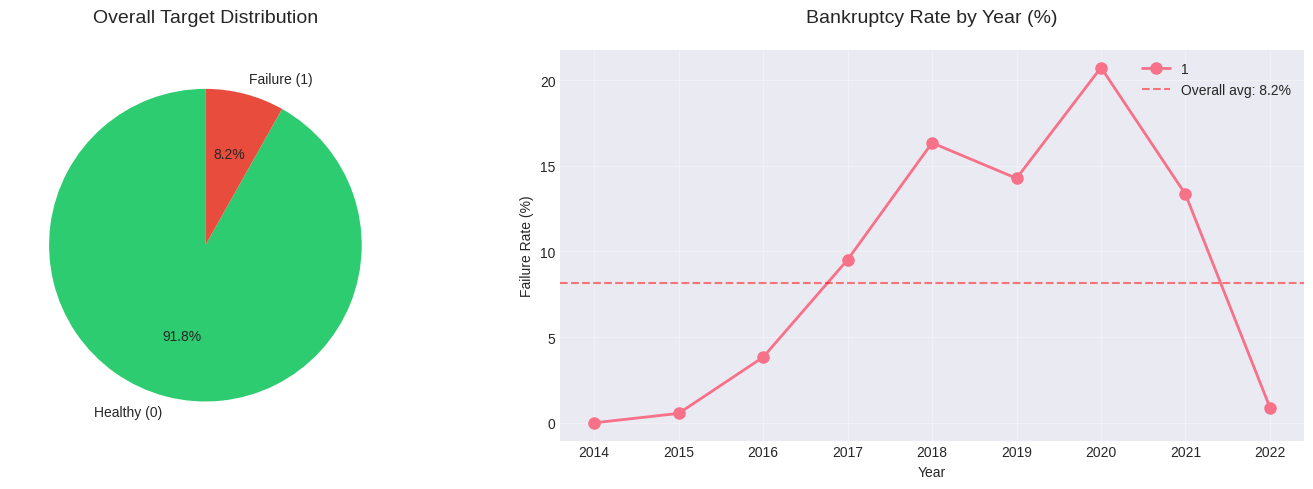


⚠️  Firms with multiple bankruptcy flags: 0


In [ ]:
#@title Target Distribution Analysis
# Overall target distribution
target_dist = df_ready['Target'].value_counts()
target_pct = df_ready['Target'].value_counts(normalize=True) * 100

print("🎯 TARGET DISTRIBUTION")
print("=" * 50)
print(f"Class 0 (Healthy): {target_dist[0]:,} ({target_pct[0]:.2f}%)")
print(f"Class 1 (Failure): {target_dist[1]:,} ({target_pct[1]:.2f}%)")
print(f"Imbalance Ratio: {target_dist[0]/target_dist[1]:.1f}:1")

# Target distribution by year
yearly_target = pd.crosstab(df_ready['Year'], df_ready['Target'], normalize='index') * 100

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
ax1.pie(target_dist.values, labels=['Healthy (0)', 'Failure (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'])
ax1.set_title('Overall Target Distribution', fontsize=14, pad=20)

# Yearly trend
yearly_target[1].plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=8)
ax2.set_title('Bankruptcy Rate by Year (%)', fontsize=14, pad=20)
ax2.set_xlabel('Year')
ax2.set_ylabel('Failure Rate (%)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=target_pct[1], color='red', linestyle='--', alpha=0.5, label=f'Overall avg: {target_pct[1]:.1f}%')
ax2.legend()

plt.tight_layout()
plt.show()

# Check firms with multiple bankruptcy events (data quality check)
firm_bankruptcies = df_ready.groupby('Tax code number')['Target'].sum()
multi_bankruptcy = firm_bankruptcies[firm_bankruptcies > 1]
print(f"\n⚠️  Firms with multiple bankruptcy flags: {len(multi_bankruptcy)}")
if len(multi_bankruptcy) > 0:
    print("This should be 0 according to your memo!")

📊 TEMPORAL SPLIT ANALYSIS
            Split  Samples  Firms  Failures  Failure Rate (%)
Train (2014-2018)    11376   2362       652            5.7314
     Valid (2019)     1710   1710       244           14.2690
 Test (2020-2022)     3635   1466       468           12.8748


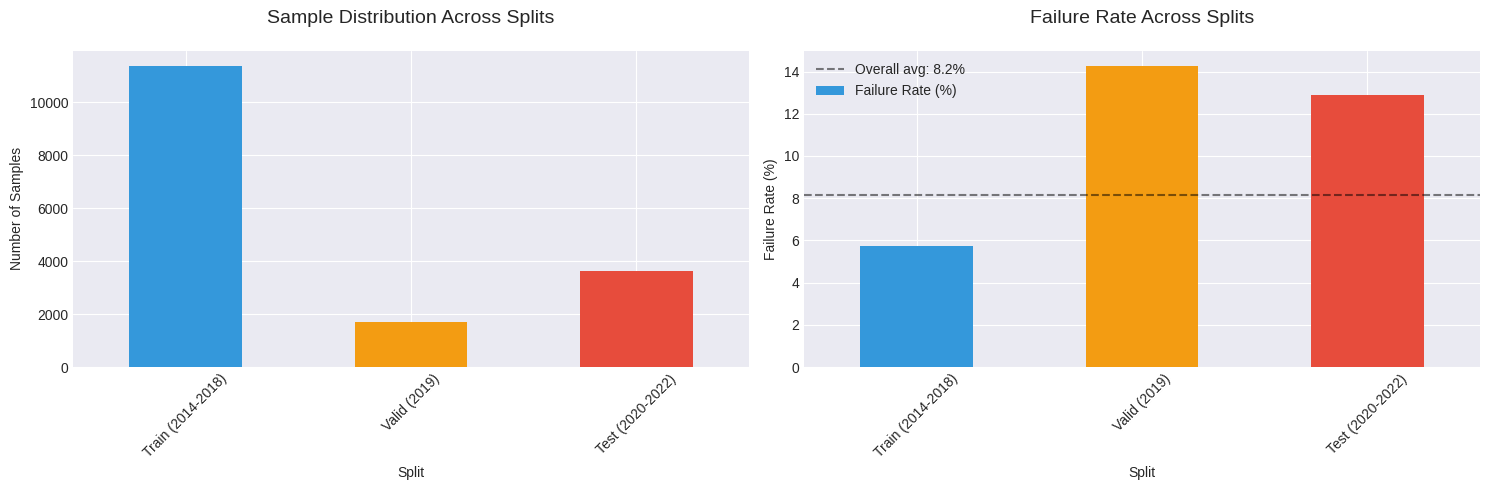


📈 Statistical Tests for Target Distribution Across Splits:


ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
#@title Temporal Split Balance Analysis
# Define splits as per your memo
train_mask = df_ready['Year'].between(2014, 2018)
valid_mask = df_ready['Year'] == 2019
test_mask = df_ready['Year'].between(2020, 2022)

# Calculate target distributions for each split
splits_data = []
for split_name, mask in [('Train (2014-2018)', train_mask),
                          ('Valid (2019)', valid_mask),
                          ('Test (2020-2022)', test_mask)]:
    split_df = df_ready[mask]
    n_samples = len(split_df)
    n_failures = split_df['Target'].sum()
    failure_rate = n_failures / n_samples * 100
    n_firms = split_df['Tax code number'].nunique()

    splits_data.append({
        'Split': split_name,
        'Samples': n_samples,
        'Firms': n_firms,
        'Failures': n_failures,
        'Failure Rate (%)': failure_rate
    })

splits_df = pd.DataFrame(splits_data)

print("📊 TEMPORAL SPLIT ANALYSIS")
print("=" * 50)
print(splits_df.to_string(index=False))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Sample distribution
splits_df.set_index('Split')['Samples'].plot(kind='bar', ax=ax1, color=['#3498db', '#f39c12', '#e74c3c'])
ax1.set_title('Sample Distribution Across Splits', fontsize=14, pad=20)
ax1.set_ylabel('Number of Samples')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Failure rate comparison
splits_df.set_index('Split')['Failure Rate (%)'].plot(kind='bar', ax=ax2, color=['#3498db', '#f39c12', '#e74c3c'])
ax2.axhline(y=target_pct[1], color='black', linestyle='--', alpha=0.5, label=f'Overall avg: {target_pct[1]:.1f}%')
ax2.set_title('Failure Rate Across Splits', fontsize=14, pad=20)
ax2.set_ylabel('Failure Rate (%)')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# Statistical test for distribution differences
print("\n📈 Statistical Tests for Target Distribution Across Splits:")
for i, (name1, mask1) in enumerate([('Train', train_mask), ('Valid', valid_mask)]):
    for name2, mask2 in [('Valid', valid_mask), ('Test', test_mask)][i:]:
        if name1 != name2:
            rate1 = df_ready[mask1]['Target'].mean()
            rate2 = df_ready[mask2]['Target'].mean()
            # Chi-square test
            contingency = pd.crosstab(
                pd.concat([pd.Series(['Split1']*mask1.sum()), pd.Series(['Split2']*mask2.sum())]),
                pd.concat([df_ready[mask1]['Target'], df_ready[mask2]['Target']])
            )
            chi2, p_value, _, _ = stats.chi2_contingency(contingency)
            print(f"\n{name1} vs {name2}:")
            print(f"  Failure rates: {rate1:.3%} vs {rate2:.3%}")
            print(f"  Chi-square p-value: {p_value:.4f} {'⚠️ Significantly different!' if p_value < 0.05 else '✅ Not significantly different'}")

In [ ]:
#@title Feature Correlation Analysis - Preparation
# Separate features for correlation analysis
exclude_cols = ['Tax code number', 'Year', 'Target']
feature_cols = [col for col in df_ready.columns if col not in exclude_cols]

print(f"📊 Analyzing {len(feature_cols)} features for correlation...")

# Calculate correlation matrix (this might take a moment)
print("Calculating correlation matrix...")
corr_matrix = df_ready[feature_cols].corr()

# Set diagonal to NaN (don't want to count self-correlation)
np.fill_diagonal(corr_matrix.values, np.nan)

📊 Analyzing 444 features for correlation...
Calculating correlation matrix...


ValueError: could not convert string to float: 'Limited liability company - SRL'

🔍 HIGH CORRELATION ANALYSIS (threshold = 0.85)
Total feature pairs: 98,346
Highly correlated pairs: 1,409
Percentage of high correlations: 1.43%

Top 20 highest correlations:
                                                                                                               Feature 1                                                                   Feature 2  Correlation
                                                                                            0086_Invest. in parent comp.                        0087_Invest. in comp. under parent companies control       1.0000
                                             0211_Financial charges of which: from financial receivables subs and assoc.                                                   0326_Book Value per share       1.0000
0208_Inc. other than the above (of which: from subsidiaries, associated, parent cies and cies under parent cies control)                                                  0319_Market capitalisatio

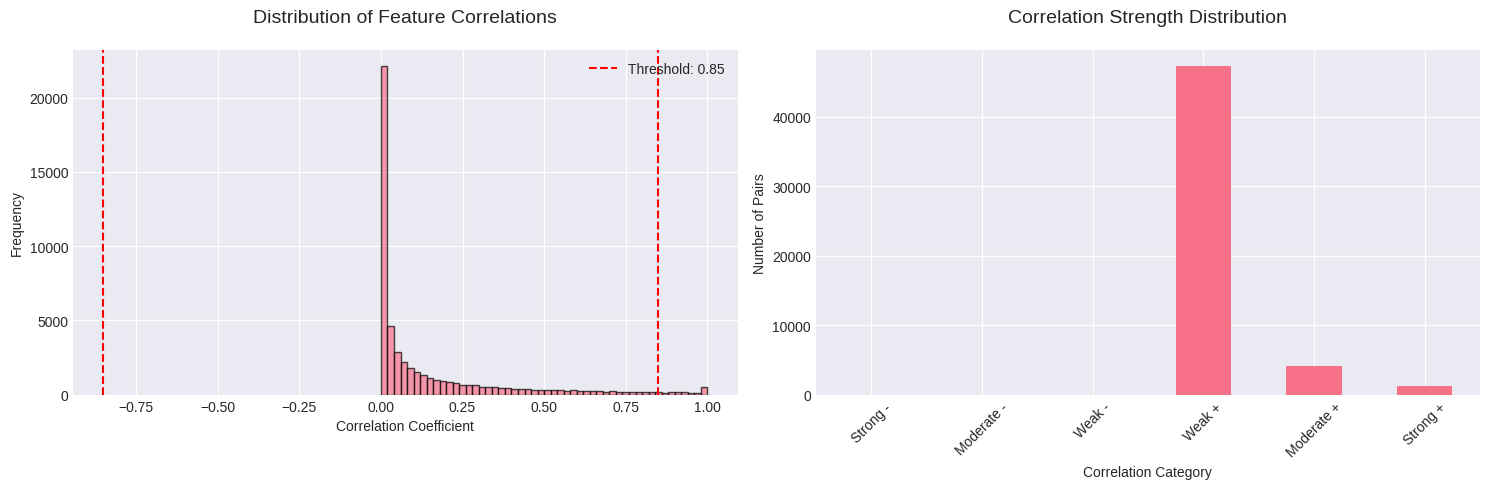

In [ ]:
#@title High Correlation Pairs Analysis
# Define correlation threshold
CORR_THRESHOLD = 0.85  # You can adjust this

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) >= CORR_THRESHOLD:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

print(f"🔍 HIGH CORRELATION ANALYSIS (threshold = {CORR_THRESHOLD})")
print("=" * 50)
print(f"Total feature pairs: {len(feature_cols) * (len(feature_cols)-1) // 2:,}")
print(f"Highly correlated pairs: {len(high_corr_df):,}")
print(f"Percentage of high correlations: {len(high_corr_df) / (len(feature_cols) * (len(feature_cols)-1) // 2) * 100:.2f}%")

# Show top correlations
print(f"\nTop 20 highest correlations:")
print(high_corr_df.head(20).to_string(index=False))

# Correlation distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of all correlations
all_corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
ax1.hist(all_corr_values, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=CORR_THRESHOLD, color='red', linestyle='--', label=f'Threshold: {CORR_THRESHOLD}')
ax1.axvline(x=-CORR_THRESHOLD, color='red', linestyle='--')
ax1.set_title('Distribution of Feature Correlations', fontsize=14, pad=20)
ax1.set_xlabel('Correlation Coefficient')
ax1.set_ylabel('Frequency')
ax1.legend()

# Box plot by correlation strength
corr_categories = pd.cut(all_corr_values,
                        bins=[-1, -0.85, -0.5, 0, 0.5, 0.85, 1],
                        labels=['Strong -', 'Moderate -', 'Weak -', 'Weak +', 'Moderate +', 'Strong +'])
corr_dist = corr_categories.value_counts()
corr_dist.plot(kind='bar', ax=ax2)
ax2.set_title('Correlation Strength Distribution', fontsize=14, pad=20)
ax2.set_xlabel('Correlation Category')
ax2.set_ylabel('Number of Pairs')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#@title Feature Type Analysis
# Analyze different types of features
event_features = [col for col in feature_cols if col.startswith('ev_')]
financial_features = [col for col in feature_cols if col not in event_features]

# Check for ratios and transformations
ratio_features = [col for col in financial_features if any(marker in col.lower() for marker in ['ratio', 'per', 'margin', 'turnover', 'rate'])]
absolute_features = [col for col in financial_features if col not in ratio_features]

print("📈 FEATURE TYPE BREAKDOWN")
print("=" * 50)
print(f"Total features: {len(feature_cols)}")
print(f"Event features (ev_*): {len(event_features)}")
print(f"  - Current year: {len([f for f in event_features if not f.endswith('_lag1')])}")
print(f"  - Lagged (t-1): {len([f for f in event_features if f.endswith('_lag1')])}")
print(f"Financial features: {len(financial_features)}")
print(f"  - Ratios/rates: {len(ratio_features)}")
print(f"  - Absolute values: {len(absolute_features)}")

# Check zero variance features
zero_var_features = []
low_var_features = []
for col in feature_cols:
    var = df_loaded[col].var()
    if var == 0:
        zero_var_features.append(col)
    elif var < 0.01:
        low_var_features.append(col)

print(f"\n⚠️  Zero variance features: {len(zero_var_features)}")
if zero_var_features:
    print(f"   Examples: {zero_var_features[:5]}")
print(f"⚠️  Low variance features (var < 0.01): {len(low_var_features)}")

📈 FEATURE TYPE BREAKDOWN
Total features: 444
Event features (ev_*): 84
  - Current year: 63
  - Lagged (t-1): 21
Financial features: 360
  - Ratios/rates: 22
  - Absolute values: 338


TypeError: could not convert string to float: 'Limited liability company - SRL'

In [ ]:
#@title Recommendations for Handling Imbalance and Correlations
print("💡 RECOMMENDATIONS")
print("=" * 80)

# 1. Class Imbalance
print("\n1. CLASS IMBALANCE HANDLING:")
print(f"   Current imbalance ratio: {target_dist[0]/target_dist[1]:.1f}:1")
print("\n   Options to consider:")
print("   a) Sampling strategies:")
print("      - SMOTE (Synthetic Minority Over-sampling)")
print("      - Random undersampling of majority class")
print("      - Stratified sampling to maintain temporal patterns")
print("\n   b) Algorithm-level solutions:")
print("      - Use class_weight='balanced' in sklearn models")
print("      - For XGBoost: scale_pos_weight = (n_negative/n_positive)")
print("      - Custom loss functions that penalize false negatives more")
print("\n   c) Evaluation metrics:")
print("      - Focus on PR-AUC instead of ROC-AUC")
print("      - Use F2 score (weights recall more than precision)")
print("      - Monitor recall at fixed precision thresholds")

# 2. Feature Correlation
print("\n\n2. FEATURE CORRELATION HANDLING:")
print(f"   High correlation pairs found: {len(high_corr_df)}")
print("\n   Strategies:")
print("   a) Remove one feature from each highly correlated pair")
print("   b) Use PCA or factor analysis on correlated groups")
print("   c) Create ensemble features from correlated groups")
print("   d) Let tree-based models handle correlations naturally")
print("\n   Recommended approach for your case:")
print("   - Start with tree-based models (they handle correlations well)")
print("   - For linear models, remove features with |corr| > 0.95")
print("   - Consider domain knowledge: keep economically meaningful ratios")

# 3. Additional concerns
if len(zero_var_features) > 0:
    print(f"\n\n3. ZERO VARIANCE FEATURES:")
    print(f"   Found {len(zero_var_features)} features with zero variance")
    print("   → Remove these before modeling")

print("\n\n4. TEMPORAL CONSIDERATIONS:")
print("   - Your test set (2020-2022) includes COVID period")
print("   - Consider creating COVID indicator variable")
print("   - Monitor if model performance degrades significantly in 2020+")

print("\n\n5. DATA LEAKAGE CHECKS:")
print("   ✓ Ensure ev_bankruptcy and ev_judicial_liquidation are excluded")
print("   ✓ Consider whether other ev_* features might leak information")
print("   ✓ Verify that financial ratios are calculated correctly without future info")

💡 RECOMMENDATIONS

1. CLASS IMBALANCE HANDLING:
   Current imbalance ratio: 11.3:1

   Options to consider:
   a) Sampling strategies:
      - SMOTE (Synthetic Minority Over-sampling)
      - Random undersampling of majority class
      - Stratified sampling to maintain temporal patterns

   b) Algorithm-level solutions:
      - Use class_weight='balanced' in sklearn models
      - For XGBoost: scale_pos_weight = (n_negative/n_positive)
      - Custom loss functions that penalize false negatives more

   c) Evaluation metrics:
      - Focus on PR-AUC instead of ROC-AUC
      - Use F2 score (weights recall more than precision)
      - Monitor recall at fixed precision thresholds


2. FEATURE CORRELATION HANDLING:
   High correlation pairs found: 1409

   Strategies:
   a) Remove one feature from each highly correlated pair
   b) Use PCA or factor analysis on correlated groups
   c) Create ensemble features from correlated groups
   d) Let tree-based models handle correlations naturally


In [ ]:
#@title Quick Statistical Summary of Key Metrics
# Select a few key financial indicators to examine
sample_features = ['ev_bankruptcy', 'ev_judicial_liquidation'] + financial_features[:10]

# Compare distributions between healthy and failed firms
print("📊 SAMPLE FEATURE COMPARISON (Healthy vs Failed Firms)")
print("=" * 80)

comparison_data = []
for feature in sample_features[:12]:  # Limit to first 12 for readability
    healthy_mean = df_loaded[df_loaded['Target'] == 0][feature].mean()
    failed_mean = df_loaded[df_loaded['Target'] == 1][feature].mean()

    # T-test
    t_stat, p_value = stats.ttest_ind(
        df_loaded[df_loaded['Target'] == 0][feature].dropna(),
        df_loaded[df_loaded['Target'] == 1][feature].dropna()
    )

    comparison_data.append({
        'Feature': feature[:40],  # Truncate long names
        'Healthy Mean': healthy_mean,
        'Failed Mean': failed_mean,
        'Difference': failed_mean - healthy_mean,
        'P-value': p_value,
        'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False, float_format='%.4f'))
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")

📊 SAMPLE FEATURE COMPARISON (Healthy vs Failed Firms)


TypeError: Could not convert string 'Limited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLJoint stock company - SPAJoint stock company - SPAJoint stock company - SPAJoint stock company - SPAJoint stock company - SPAJoint stock company - SPAJoint stock company - SPAJoint stock company - SPAJoint stock company - SPALimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company - SRLLimited liability company

In [ ]:
#@title Class Imbalance Strategy Comparison

print("🎯 CLASS IMBALANCE STRATEGIES")
print("=" * 50)
print(f"Current ratio: {(df_ready['Target'] == 0).sum()} healthy : {(df_ready['Target'] == 1).sum()} failures")
print(f"Imbalance: {(df_ready['Target'] == 0).sum() / (df_ready['Target'] == 1).sum():.1f}:1")

print("\n📊 OPTION 1: Random Undersampling")
print("  Pros: Simple, ensures balanced dataset")
print("  Cons: Loses 90% of your data!, might miss rare patterns")
print(f"  Result: ~2,728 samples total (1,364 each class)")

print("\n📊 OPTION 2: Class Weights (Recommended)")
print("  Pros: Uses ALL data, no information loss")
print("  Cons: None really - standard practice")
print("  Implementation:")
print(f"    - Logistic/Linear: class_weight='balanced'")
print(f"    - XGBoost: scale_pos_weight={((df_ready['Target'] == 0).sum() / (df_ready['Target'] == 1).sum()):.1f}")
print(f"    - LightGBM: is_unbalance=True")

print("\n📊 OPTION 3: SMOTE (Synthetic Minority Oversampling)")
print("  Pros: Creates synthetic failures, more training data")
print("  Cons: Can overfit, synthetic data may not be realistic")
print("  Result: ~30,714 samples (balanced)")

print("\n📊 OPTION 4: Temporal-Aware Undersampling")
print("  Pros: Maintains temporal patterns while balancing")
print("  Cons: Still loses data, but less than random")
print("  Method: Keep all failures, sample healthy firms proportionally by year")

# My recommendation
print("\n💡 RECOMMENDED APPROACH:")
print("1. Primary: Use class weights (Option 2)")
print("2. For comparison: Try temporal-aware undersampling")
print("3. Avoid: Random undersampling (too much data loss)")

🎯 CLASS IMBALANCE STRATEGIES
Current ratio: 15357 healthy : 1364 failures
Imbalance: 11.3:1

📊 OPTION 1: Random Undersampling
  Pros: Simple, ensures balanced dataset
  Cons: Loses 90% of your data!, might miss rare patterns
  Result: ~2,728 samples total (1,364 each class)

📊 OPTION 2: Class Weights (Recommended)
  Pros: Uses ALL data, no information loss
  Cons: None really - standard practice
  Implementation:
    - Logistic/Linear: class_weight='balanced'
    - XGBoost: scale_pos_weight=11.3
    - LightGBM: is_unbalance=True

📊 OPTION 3: SMOTE (Synthetic Minority Oversampling)
  Pros: Creates synthetic failures, more training data
  Cons: Can overfit, synthetic data may not be realistic
  Result: ~30,714 samples (balanced)

📊 OPTION 4: Temporal-Aware Undersampling
  Pros: Maintains temporal patterns while balancing
  Cons: Still loses data, but less than random
  Method: Keep all failures, sample healthy firms proportionally by year

💡 RECOMMENDED APPROACH:
1. Primary: Use class we

In [ ]:
#@title Detailed Correlation Group Analysis
# Using the high_corr_df from before
if 'high_corr_df' in locals():
    # Group correlations by feature type
    investment_corr = high_corr_df[
        high_corr_df['Feature 1'].str.contains('Invest|invest', na=False) |
        high_corr_df['Feature 2'].str.contains('Invest|invest', na=False)
    ]

    financial_corr = high_corr_df[
        high_corr_df['Feature 1'].str.contains('Financial|financial', na=False) |
        high_corr_df['Feature 2'].str.contains('Financial|financial', na=False)
    ]

    price_corr = high_corr_df[
        high_corr_df['Feature 1'].str.contains('price|Price', na=False) |
        high_corr_df['Feature 2'].str.contains('price|Price', na=False)
    ]

    print("🔍 CORRELATION PATTERNS:")
    print(f"\nInvestment-related: {len(investment_corr)} pairs")
    print(f"Financial charges: {len(financial_corr)} pairs")
    print(f"Price-related: {len(price_corr)} pairs")

    # Features to potentially drop
    features_to_drop = set()

    # From each perfectly correlated pair, keep one
    for _, row in high_corr_df[high_corr_df['Correlation'] == 1.0].iterrows():
        # Keep the shorter-named feature (usually more general)
        if len(row['Feature 1']) > len(row['Feature 2']):
            features_to_drop.add(row['Feature 1'])
        else:
            features_to_drop.add(row['Feature 2'])

    print(f"\n🗑️ Recommend dropping {len(features_to_drop)} perfectly correlated features")

🔍 CORRELATION PATTERNS:

Investment-related: 55 pairs
Financial charges: 157 pairs
Price-related: 406 pairs

🗑️ Recommend dropping 28 perfectly correlated features


In [ ]:
#@title Summary of Data Issues and Perfect Correlations Analysis

print("📊 DATA QUALITY SUMMARY")
print("=" * 80)

# 1. String Variables Found
print("\n1. STRING VARIABLES:")
print("   • Legal form: 13 categories (mostly SRL companies)")
print("   • Company category: Only 1 value ('Limited company') - can be dropped")
print("   • Financial ratios (0007-0014): Were incorrectly typed as strings!")
print("   • Accounting model: 3 types (Abbreviated, Detailed)")
print("   → Action: Encode Legal form & Accounting model; Fix ratio columns")

# 2. Class Imbalance
print("\n2. CLASS IMBALANCE:")
print("   • 11.3:1 ratio (91.8% healthy vs 8.2% failures)")
print("   → Decision: Use class weights in all models")

# 3. Temporal Issues
print("\n3. TEMPORAL DISTRIBUTION:")
print("   • Train (2014-2018): 5.7% failure rate")
print("   • Valid (2019): 14.3% failure rate (2.5x increase!)")
print("   • Test (2020-2022): 12.9% failure rate")
print("   → COVID impact clearly visible in 2020")

# 4. Perfect Correlations
print("\n4. PERFECT CORRELATIONS: 28 feature pairs")
print("   • Investment-related: Parent/subsidiary investments")
print("   • Financial charges: Multiple identical calculations")
print("   • Monthly prices: Many months have identical values")

📊 DATA QUALITY SUMMARY

1. STRING VARIABLES:
   • Legal form: 13 categories (mostly SRL companies)
   • Company category: Only 1 value ('Limited company') - can be dropped
   • Financial ratios (0007-0014): Were incorrectly typed as strings!
   • Accounting model: 3 types (Abbreviated, Detailed)
   → Action: Encode Legal form & Accounting model; Fix ratio columns

2. CLASS IMBALANCE:
   • 11.3:1 ratio (91.8% healthy vs 8.2% failures)
   → Decision: Use class weights in all models

3. TEMPORAL DISTRIBUTION:
   • Train (2014-2018): 5.7% failure rate
   • Valid (2019): 14.3% failure rate (2.5x increase!)
   • Test (2020-2022): 12.9% failure rate
   → COVID impact clearly visible in 2020

4. PERFECT CORRELATIONS: 28 feature pairs
   • Investment-related: Parent/subsidiary investments
   • Financial charges: Multiple identical calculations
   • Monthly prices: Many months have identical values


In [ ]:
#@title Show Perfect Correlation Examples

# Let's examine the perfectly correlated features
perfect_corr_pairs = high_corr_df[high_corr_df['Correlation'].abs() == 1.0].copy()

print("🔍 PERFECT CORRELATION EXAMPLES")
print("=" * 80)
print(f"Total perfectly correlated pairs: {len(perfect_corr_pairs)}")

# Group by correlation patterns
print("\n📈 CORRELATION PATTERNS:")

# Pattern 1: Investment features
inv_pairs = perfect_corr_pairs[
    perfect_corr_pairs['Feature 1'].str.contains('Invest', na=False) |
    perfect_corr_pairs['Feature 2'].str.contains('Invest', na=False)
]
if len(inv_pairs) > 0:
    print(f"\n1. INVESTMENT FEATURES ({len(inv_pairs)} pairs):")
    print(inv_pairs[['Feature 1', 'Feature 2']].head(3).to_string(index=False))

# Pattern 2: Price features
price_pairs = perfect_corr_pairs[
    perfect_corr_pairs['Feature 1'].str.contains('price', na=False) |
    perfect_corr_pairs['Feature 2'].str.contains('price', na=False)
]
if len(price_pairs) > 0:
    print(f"\n2. MONTHLY PRICE FEATURES ({len(price_pairs)} pairs):")
    print(price_pairs[['Feature 1', 'Feature 2']].head(3).to_string(index=False))

# Pattern 3: Financial features
fin_pairs = perfect_corr_pairs[
    perfect_corr_pairs['Feature 1'].str.contains('Financial|financial', na=False) |
    perfect_corr_pairs['Feature 2'].str.contains('Financial|financial', na=False)
]
if len(fin_pairs) > 0:
    print(f"\n3. FINANCIAL FEATURES ({len(fin_pairs)} pairs):")
    print(fin_pairs[['Feature 1', 'Feature 2']].head(3).to_string(index=False))

🔍 PERFECT CORRELATION EXAMPLES
Total perfectly correlated pairs: 143

📈 CORRELATION PATTERNS:

2. MONTHLY PRICE FEATURES (25 pairs):
                                                                  Feature 1                          Feature 2
0211_Financial charges of which: from financial receivables subs and assoc.   0335_Monthly - High price - June
0211_Financial charges of which: from financial receivables subs and assoc. 0351_Monthly - Low price - October
0211_Financial charges of which: from financial receivables subs and assoc.   0345_Monthly - Low price - April

3. FINANCIAL FEATURES (30 pairs):
                                                                  Feature 1                                Feature 2
                              0251_Non-fixed financial assets: (investment)                 0295_of which restricted
0211_Financial charges of which: from financial receivables subs and assoc.         0335_Monthly - High price - June
0211_Financial charges of which: from

In [ ]:
#@title Examine Actual Values of Perfectly Correlated Features

# Let's look at actual data to understand WHY they're perfectly correlated
print("🔬 EXAMINING PERFECTLY CORRELATED FEATURE VALUES")
print("=" * 80)

# Take first 5 perfectly correlated pairs
for i, row in perfect_corr_pairs.head(5).iterrows():
    feat1, feat2 = row['Feature 1'], row['Feature 2']

    print(f"\n📊 Pair {i+1}: Perfect correlation")
    print(f"Feature 1: {feat1[:60]}...")
    print(f"Feature 2: {feat2[:60]}...")

    # Show sample values
    sample_data = df_ready_clean[[feat1, feat2]].dropna()

    # Check if they're identical
    are_identical = (sample_data[feat1] == sample_data[feat2]).all()

    if are_identical:
        print("→ These features are IDENTICAL!")
        print(f"  Non-zero values: {(sample_data[feat1] != 0).sum()}")
        print(f"  Unique values: {sample_data[feat1].nunique()}")
    else:
        print("→ Perfect linear relationship (not identical)")
        # Show correlation details
        print(f"  Sample values:")
        print(sample_data.head(3).to_string())

🔬 EXAMINING PERFECTLY CORRELATED FEATURE VALUES

📊 Pair 1408: Perfect correlation
Feature 1: ev_extraordinary_administration_ever...
Feature 2: ev_state_of_insolvency_ever...
→ These features are IDENTICAL!
  Non-zero values: 1
  Unique values: 2

📊 Pair 1406: Perfect correlation
Feature 1: ev_cessation_of_any_business_lag1...
Feature 2: ev_cessation_of_any_business_ever...
→ These features are IDENTICAL!
  Non-zero values: 1
  Unique values: 2

📊 Pair 1113: Perfect correlation
Feature 1: 0286_(Dividends and interim dividends paid)...
Feature 2: 0293_Cheques...
→ Perfect linear relationship (not identical)
  Sample values:
       0286_(Dividends and interim dividends paid)  0293_Cheques
10423                                    -235.0000        0.1730
16000                                       0.0010        0.2850

📊 Pair 1107: Perfect correlation
Feature 1: 0282_(Loans repayment)...
Feature 2: ev_court_ordered_administration...
→ Perfect linear relationship (not identical)
  Sample va

In [ ]:
#@title Financial Ratio Columns Issue

# The financial ratios being stored as strings is concerning
print("⚠️ CRITICAL ISSUE: Financial Ratios as Strings")
print("=" * 80)

ratio_cols = ['0007_EBITDA/Vendite', '0008_Return on sales (ROS)',
              '0009_Return on asset (ROA)', '0010_Return on equity (ROE)',
              '0011_Debt/equity ratio', '0012_Banks/turnover',
              '0013_Debt/EBITDA ratio', '0014_Total assets turnover (times)']

print("These should be numeric but are stored as strings:")
for col in ratio_cols:
    if col in df_ready.columns:
        # Sample some values
        sample_vals = df_ready[col].dropna().head(5).tolist()
        print(f"\n{col}:")
        print(f"  Sample values: {sample_vals}")
        print(f"  Unique count: {df_ready[col].nunique()}")

print("\n🔧 FIX REQUIRED: Convert these to numeric!")

⚠️ CRITICAL ISSUE: Financial Ratios as Strings
These should be numeric but are stored as strings:

0007_EBITDA/Vendite:
  Sample values: [12.17, 14.81, 9.59, 11.2, 12.84]
  Unique count: 4104

0008_Return on sales (ROS):
  Sample values: [5.75, 9.53, 3.76, 4.2, 5.56]
  Unique count: 3214

0009_Return on asset (ROA):
  Sample values: [2.38, 3.82, 1.34, 1.31, 1.82]
  Unique count: 4223

0010_Return on equity (ROE):
  Sample values: [2.06, 2.11, 1.5, 2.41, 3.09]
  Unique count: 5756

0011_Debt/equity ratio:
  Sample values: [0.47, 0.58, 0.49, 0.6, 0.4]
  Unique count: 1393

0012_Banks/turnover:
  Sample values: [56.61, 70.36, 73.38, 74.49, 51.34]
  Unique count: 3104

0013_Debt/EBITDA ratio:
  Sample values: [4.65, 4.75, 7.65, 6.65, 4.0]
  Unique count: 1852

0014_Total assets turnover (times):
  Sample values: [0.37, 0.36, 0.32, 0.26, 0.27]
  Unique count: 479

🔧 FIX REQUIRED: Convert these to numeric!


In [ ]:
#@title Financial Ratio Columns Issue

# The financial ratios being stored as strings is concerning
print("⚠️ CRITICAL ISSUE: Financial Ratios as Strings")
print("=" * 80)

ratio_cols = ['0007_EBITDA/Vendite', '0008_Return on sales (ROS)',
              '0009_Return on asset (ROA)', '0010_Return on equity (ROE)',
              '0011_Debt/equity ratio', '0012_Banks/turnover',
              '0013_Debt/EBITDA ratio', '0014_Total assets turnover (times)']

print("These should be numeric but are stored as strings:")
for col in ratio_cols:
    if col in df_ready.columns:
        # Sample some values
        sample_vals = df_ready[col].dropna().head(5).tolist()
        print(f"\n{col}:")
        print(f"  Sample values: {sample_vals}")
        print(f"  Unique count: {df_ready[col].nunique()}")

print("\n🔧 FIX REQUIRED: Convert these to numeric!")

⚠️ CRITICAL ISSUE: Financial Ratios as Strings
These should be numeric but are stored as strings:

0007_EBITDA/Vendite:
  Sample values: [12.17, 14.81, 9.59, 11.2, 12.84]
  Unique count: 4104

0008_Return on sales (ROS):
  Sample values: [5.75, 9.53, 3.76, 4.2, 5.56]
  Unique count: 3214

0009_Return on asset (ROA):
  Sample values: [2.38, 3.82, 1.34, 1.31, 1.82]
  Unique count: 4223

0010_Return on equity (ROE):
  Sample values: [2.06, 2.11, 1.5, 2.41, 3.09]
  Unique count: 5756

0011_Debt/equity ratio:
  Sample values: [0.47, 0.58, 0.49, 0.6, 0.4]
  Unique count: 1393

0012_Banks/turnover:
  Sample values: [56.61, 70.36, 73.38, 74.49, 51.34]
  Unique count: 3104

0013_Debt/EBITDA ratio:
  Sample values: [4.65, 4.75, 7.65, 6.65, 4.0]
  Unique count: 1852

0014_Total assets turnover (times):
  Sample values: [0.37, 0.36, 0.32, 0.26, 0.27]
  Unique count: 479

🔧 FIX REQUIRED: Convert these to numeric!


In [ ]:
#@title 🚀 Comprehensive Model Comparison with Hyperparameter Optimization

#================================================================================
# CONFIGURATION PARAMETERS - MODIFY THESE AS NEEDED
#================================================================================

# Optuna Settings

MODEL_TRIALS = {
    'logistic':        2,    # Fewer trials for simple model
    'random_forest':   2,   # Medium complexity
    'xgboost':         2,   # Full trials
    'lightgbm':        2,   # Full trials
    'neural_network':  2,   # Medium complexity
    'svm':             2     # SVM optimization
}
"""
MODEL_TRIALS = {
    'logistic':        25,    # Fewer trials for simple model
    'random_forest':   100,   # Medium complexity
    'xgboost':         300,   # Full trials
    'lightgbm':        300,   # Full trials
    'neural_network':  100,   # Medium complexity
    'svm':             100     # SVM optimization
}
"""

OPTUNA_TIMEOUT = 2400  # Timeout in seconds per model
USE_OPTUNA = True  # Set to False to use default parameters
USE_PRUNING = True  # Set to True to enable early stopping of bad trials

# Model Training Settings
RANDOM_STATE = 42
EARLY_STOPPING_ROUNDS = 50
MAX_ITERATIONS = 300
CV_FOLDS = 3  # Number of cross-validation folds

# Hyperparameter Search Ranges
PARAM_RANGES = {
    'logistic': {
        'C': (0.001, 10.0),  # Inverse regularization strength
    },
    'random_forest': {
        'n_estimators': (100, 1000),
        'max_depth': (10, 50),
        'min_samples_split': (2, 20),
        'min_samples_leaf': (1, 10),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    },
    'xgboost': {
        'max_depth': (3, 15),
        'learning_rate': (0.01, 0.4),
        'n_estimators': (100, 600),
        'subsample': (0.5, 1.0),
        'colsample_bytree': (0.6, 1),   # bound [0,1]
        'reg_alpha': (0.001, 10.0),
        'reg_lambda': (0.001, 10.0)
    },
    'lightgbm': {
        'num_leaves': (20, 300),
        'learning_rate': (0.006, 0.3),
        'n_estimators': (100, 500),
        'feature_fraction': (0.5, 1),   # bound [0,1]
        'bagging_fraction': (0.5, 1.0),
        'bagging_freq': (1, 20),
        'reg_alpha': (0.001, 10.0),
        'reg_lambda': (0.001, 10.0)
    },
    'neural_network': {
        'n_layers': (1, 10),  # Number of hidden layers
        'neurons_per_layer': (16, 800),  # Same range for all layers
        'dropout_rate': (0.1, 0.5),
        'learning_rate': (0.0001, 0.01),
        'batch_size': [32, 64, 128],
        'epochs': (50, 200)
    },
    'svm': {
        'C': (0.01, 100.0),            # Regularization parameter
        'gamma': (0.0001, 1.0),        # Kernel coefficient (for RBF)
        'kernel': ['rbf', 'linear'],   # Kernel type
        'class_weight': ['balanced']   # Handle imbalanced data
    }
}

#================================================================================
# IMPORTS AND SETUP
#================================================================================

# still required packages


#================================================================================
# PROGRESS TRACKING SYSTEM
#================================================================================

class ModelTracker:
    def __init__(self, total_models=5):
        self.total_models = total_models
        self.current_model = 0
        self.results_summary = []
        self.start_time = time.time()

    def update(self, model_name, status, metrics=None, trial=None, total_trials=None):
        self.current_time = time.time() - self.start_time

        # Clear and redraw
        clear_output(wait=True)

        # Header
        print("🚀 COMPREHENSIVE BANKRUPTCY PREDICTION MODEL COMPARISON")
        print("=" * 80)
        print(f"⏱️  Elapsed Time: {self.current_time:.1f}s")
        print(f"🔧 Configuration: Optuna={'ON' if USE_OPTUNA else 'OFF'} | CV Folds={CV_FOLDS} | Pruning={'ON' if USE_PRUNING else 'OFF'}")
        print("=" * 80)

        # Current model status
        print(f"\n📊 Current Model: {model_name}")
        print(f"📈 Status: {status}")

        # Optuna progress bar if applicable
        if trial is not None and total_trials is not None:
            progress = trial / total_trials
            bar_length = 50
            filled_length = int(bar_length * progress)
            bar = '█' * filled_length + '░' * (bar_length - filled_length)
            print(f"🔍 Optimization: [{bar}] {trial}/{total_trials} trials")

        # Overall progress
        print(f"\n🏃 Overall Progress: {self.current_model}/{self.total_models} models")
        overall_progress = self.current_model / self.total_models
        bar_length = 50
        filled_length = int(bar_length * overall_progress)
        bar = '█' * filled_length + '░' * (bar_length - filled_length)
        print(f"   [{bar}] {overall_progress*100:.0f}%")

        # Results so far
        if self.results_summary:
            print("\n📊 Results Summary:")
            print("-" * 60)
            print(f"{'Model':<20} {'Train Time':<12} {'Test ROC-AUC':<12} {'Status':<10}")
            print("-" * 60)
            for result in self.results_summary:
                print(f"{result['model']:<20} {result['time']:<12} {result['auc']:<12} ✅")

        if metrics:
            print(f"\n🎯 Current Metrics: {metrics}")

    def complete_model(self, model_name, train_time, test_auc):
        self.current_model += 1
        self.results_summary.append({
            'model': model_name,
            'time': f"{train_time:.1f}s",
            'auc': f"{test_auc:.4f}"
        })

# Initialize tracker
tracker = ModelTracker(total_models=6)

#================================================================================
# DATA PREPARATION
#================================================================================

tracker.update("Data Preparation", "Loading and splitting data...")

# Create temporal splits
X = df_model_ready[feature_cols]
y = df_model_ready['Target']

# Temporal splits
train_mask = df_model_ready['Year'].between(2014, 2018)
valid_mask = df_model_ready['Year'] == 2019
test_mask = df_model_ready['Year'].between(2020, 2022)

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Calculate class weights
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
class_weight_dict = {0: 1.0, 1: scale_pos_weight}

# Sanitize feature names for LightGBM
def sanitize_features(df):
    df = df.copy()
    df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', c) for c in df.columns]
    return df

X_train_sanitized = sanitize_features(X_train)
X_valid_sanitized = sanitize_features(X_valid)
X_test_sanitized = sanitize_features(X_test)

# Save feature names
feature_names = list(feature_cols)
feature_names_sanitized = list(X_train_sanitized.columns)

tracker.update("Data Preparation", "Data loaded and split successfully!",
              f"Train: {X_train.shape} | Valid: {X_valid.shape} | Test: {X_test.shape}")
time.sleep(2)

# Initialize storage
results = []
models = {}
predictions = {}
best_params = {}

#================================================================================
# OPTUNA OPTIMIZATION FUNCTIONS
#================================================================================

def create_neural_network(input_dim, n_layers, neurons_per_layer, dropout_rate, learning_rate):
    """Create a neural network with dynamic number of layers."""
    model = keras.Sequential()

    # Input layer
    model.add(keras.layers.Input(shape=(input_dim,)))

    # Hidden layers
    for i in range(n_layers):
        model.add(keras.layers.Dense(neurons_per_layer, activation='relu'))
        model.add(keras.layers.Dropout(dropout_rate))

    # Output layer
    model.add(keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )
    return model

#================================================================================
# MODEL 1: LOGISTIC REGRESSION
#================================================================================

tracker.update("Logistic Regression", "Initializing...")

if USE_OPTUNA:
    def objective_logistic(trial):
        tracker.update("Logistic Regression", "Optimizing hyperparameters...",
                      trial=trial.number + 1, total_trials=MODEL_TRIALS['logistic'])

        C = trial.suggest_float('C', *PARAM_RANGES['logistic']['C'], log=True)

        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(
                penalty='l1',
                solver='liblinear',
                C=C,
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ])

        # Use cross-validation on training set
        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

    # Create study with or without pruning
    if USE_PRUNING:
        study_logistic = optuna.create_study(
            direction='maximize',
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
    else:
        study_logistic = optuna.create_study(direction='maximize')

    study_logistic.optimize(objective_logistic,
                       n_trials=MODEL_TRIALS['logistic'],
                       timeout=OPTUNA_TIMEOUT)
    best_params['Logistic_L1'] = study_logistic.best_params
    C_optimal = study_logistic.best_params['C']
    tracker.update("Logistic Regression", "Optimization complete!",
                  f"Best C: {C_optimal:.4f}")
else:
    C_optimal = 1.0
    best_params['Logistic_L1'] = {'C': C_optimal}

# Train final model
tracker.update("Logistic Regression", "Training final model...")

log_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=C_optimal,
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

start_time = time.time()
log_pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_log = log_pipeline.predict_proba(X_train)[:, 1]
y_valid_pred_log = log_pipeline.predict_proba(X_valid)[:, 1]
y_test_pred_log = log_pipeline.predict_proba(X_test)[:, 1]

# Store results
models['Logistic_L1'] = log_pipeline
predictions['Logistic_L1'] = {
    'train': y_train_pred_log,
    'valid': y_valid_pred_log,
    'test': y_test_pred_log
}

test_roc = roc_auc_score(y_test, y_test_pred_log)
results.append({
    'Model': 'Logistic_L1',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_log),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_log),
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_log),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_log)
})

tracker.complete_model("Logistic_L1", train_time, test_roc)
tracker.update("Logistic Regression", "Completed!", f"Test ROC-AUC: {test_roc:.4f}")
time.sleep(1)

#================================================================================
# MODEL 2: RANDOM FOREST
#================================================================================

tracker.update("Random Forest", "Initializing...")

if USE_OPTUNA:
    def objective_rf(trial):
        tracker.update("Random Forest", "Optimizing hyperparameters...",
                      trial=trial.number + 1, total_trials=MODEL_TRIALS['random_forest'])

        params = {
            'n_estimators': trial.suggest_int('n_estimators', *PARAM_RANGES['random_forest']['n_estimators']),
            'max_depth': trial.suggest_int('max_depth', *PARAM_RANGES['random_forest']['max_depth']),
            'min_samples_split': trial.suggest_int('min_samples_split', *PARAM_RANGES['random_forest']['min_samples_split']),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', *PARAM_RANGES['random_forest']['min_samples_leaf']),
            'max_features': trial.suggest_categorical('max_features', PARAM_RANGES['random_forest']['max_features']),
            'bootstrap': trial.suggest_categorical('bootstrap', PARAM_RANGES['random_forest']['bootstrap'])
        }

        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('classifier', RandomForestClassifier(
                **params,
                class_weight='balanced',
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )
        return cv_scores.mean()

    # Create study with or without pruning
    if USE_PRUNING:
        study_rf = optuna.create_study(
            direction='maximize',
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
    else:
        study_rf = optuna.create_study(direction='maximize')

    study_rf.optimize(objective_rf, n_trials=MODEL_TRIALS['random_forest'], timeout=OPTUNA_TIMEOUT)
    best_params['RandomForest'] = study_rf.best_params
    rf_params = study_rf.best_params
    tracker.update("Random Forest", "Optimization complete!",
                  f"Best n_estimators: {rf_params['n_estimators']}")
else:
    rf_params = {
        'n_estimators': 200,
        'max_depth': 10,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'bootstrap': True
    }
    best_params['RandomForest'] = rf_params

# Train final model
tracker.update("Random Forest", "Training final model...")

rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        **rf_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

start_time = time.time()
rf_pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_rf = rf_pipeline.predict_proba(X_train)[:, 1]
y_valid_pred_rf = rf_pipeline.predict_proba(X_valid)[:, 1]
y_test_pred_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Store results
models['RandomForest'] = rf_pipeline
predictions['RandomForest'] = {
    'train': y_train_pred_rf,
    'valid': y_valid_pred_rf,
    'test': y_test_pred_rf
}

test_roc = roc_auc_score(y_test, y_test_pred_rf)
results.append({
    'Model': 'RandomForest',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_rf),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_rf),
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_rf),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_rf)
})

tracker.complete_model("RandomForest", train_time, test_roc)
tracker.update("Random Forest", "Completed!", f"Test ROC-AUC: {test_roc:.4f}")
time.sleep(1)

#================================================================================
# MODEL 3: XGBOOST
#================================================================================

tracker.update("XGBoost", "Initializing...")

if USE_OPTUNA:
    def objective_xgb(trial):
        tracker.update("XGBoost", "Optimizing hyperparameters...",
                      trial=trial.number + 1, total_trials=MODEL_TRIALS['xgboost'])

        params = {
            'max_depth': trial.suggest_int('max_depth', *PARAM_RANGES['xgboost']['max_depth']),
            'learning_rate': trial.suggest_float('learning_rate', *PARAM_RANGES['xgboost']['learning_rate'], log=True),
            'n_estimators': trial.suggest_int('n_estimators', *PARAM_RANGES['xgboost']['n_estimators']),
            'subsample': trial.suggest_float('subsample', *PARAM_RANGES['xgboost']['subsample']),
            'colsample_bytree': trial.suggest_float('colsample_bytree', *PARAM_RANGES['xgboost']['colsample_bytree']),
            'reg_alpha': trial.suggest_float('reg_alpha', *PARAM_RANGES['xgboost']['reg_alpha'], log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', *PARAM_RANGES['xgboost']['reg_lambda'], log=True)
        }

        model = xgb.XGBClassifier(
            **params,
            objective='binary:logistic',
            scale_pos_weight=scale_pos_weight,
            seed=RANDOM_STATE,
            eval_metric='auc',
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            verbosity=0
        )

        # Simple imputation for XGBoost
        X_train_imp = SimpleImputer(strategy='median').fit_transform(X_train)
        X_valid_imp = SimpleImputer(strategy='median').fit_transform(X_valid)

        model.fit(
            X_train_imp, y_train,
            eval_set=[(X_valid_imp, y_valid)],
            verbose=False
        )

        return model.best_score

    # Create study with or without pruning
    if USE_PRUNING:
        study_xgb = optuna.create_study(
            direction='maximize',
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
    else:
        study_xgb = optuna.create_study(direction='maximize')

    study_xgb.optimize(objective_xgb, n_trials=MODEL_TRIALS['xgboost'], timeout=OPTUNA_TIMEOUT)
    best_params['XGBoost'] = study_xgb.best_params
    xgb_params = study_xgb.best_params
    tracker.update("XGBoost", "Optimization complete!",
                  f"Best max_depth: {xgb_params['max_depth']}")
else:
    xgb_params = {
        'max_depth': 6,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0
    }
    best_params['XGBoost'] = xgb_params

# Train final model
tracker.update("XGBoost", "Training final model...")

imputer_xgb = SimpleImputer(strategy='median')
X_train_imp = imputer_xgb.fit_transform(X_train)
X_valid_imp = imputer_xgb.transform(X_valid)
X_test_imp = imputer_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    **xgb_params,
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    seed=RANDOM_STATE,
    eval_metric='auc',
    early_stopping_rounds=EARLY_STOPPING_ROUNDS
)

start_time = time.time()
xgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_valid_imp, y_valid)],
    verbose=False
)
train_time = time.time() - start_time

# Predictions
y_train_pred_xgb = xgb_model.predict_proba(X_train_imp)[:, 1]
y_valid_pred_xgb = xgb_model.predict_proba(X_valid_imp)[:, 1]
y_test_pred_xgb = xgb_model.predict_proba(X_test_imp)[:, 1]

# Store results
models['XGBoost'] = xgb_model
predictions['XGBoost'] = {
    'train': y_train_pred_xgb,
    'valid': y_valid_pred_xgb,
    'test': y_test_pred_xgb
}

test_roc = roc_auc_score(y_test, y_test_pred_xgb)
results.append({
    'Model': 'XGBoost',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_xgb),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_xgb),
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_xgb),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_xgb)
})

tracker.complete_model("XGBoost", train_time, test_roc)
tracker.update("XGBoost", "Completed!",
              f"Test ROC-AUC: {test_roc:.4f} | Best iter: {xgb_model.best_iteration}")
time.sleep(1)

#================================================================================
# MODEL 4: LIGHTGBM
#================================================================================

tracker.update("LightGBM", "Initializing...")

if USE_OPTUNA:
    def objective_lgb(trial):
        tracker.update("LightGBM", "Optimizing hyperparameters...",
                      trial=trial.number + 1, total_trials=MODEL_TRIALS['lightgbm'])

        params = {
            'num_leaves': trial.suggest_int('num_leaves', *PARAM_RANGES['lightgbm']['num_leaves']),
            'learning_rate': trial.suggest_float('learning_rate', *PARAM_RANGES['lightgbm']['learning_rate'], log=True),
            'n_estimators': trial.suggest_int('n_estimators', *PARAM_RANGES['lightgbm']['n_estimators']),
            'feature_fraction': trial.suggest_float('feature_fraction', *PARAM_RANGES['lightgbm']['feature_fraction']),
            'bagging_fraction': trial.suggest_float('bagging_fraction', *PARAM_RANGES['lightgbm']['bagging_fraction']),
            'bagging_freq': trial.suggest_int('bagging_freq', *PARAM_RANGES['lightgbm']['bagging_freq']),
            'reg_alpha': trial.suggest_float('reg_alpha', *PARAM_RANGES['lightgbm']['reg_alpha'], log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', *PARAM_RANGES['lightgbm']['reg_lambda'], log=True)
        }

        model = lgb.LGBMClassifier(
            **params,
            objective='binary',
            is_unbalance=True,
            boosting_type='gbdt',
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )

        model.fit(
            X_train_sanitized, y_train,
            eval_set=[(X_valid_sanitized, y_valid)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(0)]
        )

        return model.best_score_['valid_0']['auc']

    # Create study with or without pruning
    if USE_PRUNING:
        study_lgb = optuna.create_study(
            direction='maximize',
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
    else:
        study_lgb = optuna.create_study(direction='maximize')

    study_lgb.optimize(objective_lgb, n_trials=MODEL_TRIALS['lightgbm'], timeout=OPTUNA_TIMEOUT)
    best_params['LightGBM'] = study_lgb.best_params
    lgb_params = study_lgb.best_params
    tracker.update("LightGBM", "Optimization complete!",
                  f"Best num_leaves: {lgb_params['num_leaves']}")
else:
    lgb_params = {
        'num_leaves': 31,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'feature_fraction': 0.8,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0
    }
    best_params['LightGBM'] = lgb_params

# Train final model
tracker.update("LightGBM", "Training final model...")

lgb_model = lgb.LGBMClassifier(
    **lgb_params,
    objective='binary',
    is_unbalance=True,
    boosting_type='gbdt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()
lgb_model.fit(
    X_train_sanitized, y_train,
    eval_set=[(X_valid_sanitized, y_valid)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(0)]
)
train_time = time.time() - start_time

# Predictions
y_train_pred_lgb = lgb_model.predict_proba(X_train_sanitized)[:, 1]
y_valid_pred_lgb = lgb_model.predict_proba(X_valid_sanitized)[:, 1]
y_test_pred_lgb = lgb_model.predict_proba(X_test_sanitized)[:, 1]

# Store results
models['LightGBM'] = lgb_model
predictions['LightGBM'] = {
    'train': y_train_pred_lgb,
    'valid': y_valid_pred_lgb,
    'test': y_test_pred_lgb
}

test_roc = roc_auc_score(y_test, y_test_pred_lgb)
results.append({
    'Model': 'LightGBM',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_lgb),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_lgb),
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_lgb),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_lgb)
})

tracker.complete_model("LightGBM", train_time, test_roc)
tracker.update("LightGBM", "Completed!",
              f"Test ROC-AUC: {test_roc:.4f} | Best iter: {lgb_model.best_iteration_}")
time.sleep(1)

#================================================================================
# MODEL 5: NEURAL NETWORK
#================================================================================

tracker.update("Neural Network", "Initializing...")

# Prepare data for neural network
scaler = StandardScaler()
imputer = SimpleImputer(strategy='median')

X_train_nn = scaler.fit_transform(imputer.fit_transform(X_train))
X_valid_nn = scaler.transform(imputer.transform(X_valid))
X_test_nn = scaler.transform(imputer.transform(X_test))

# Custom callback for progress tracking
class NNProgressCallback(keras.callbacks.Callback):
   def __init__(self, total_epochs):
       self.total_epochs = total_epochs

   def on_epoch_end(self, epoch, logs=None):
       if epoch % 10 == 0 or epoch == self.total_epochs - 1:
           tracker.update("Neural Network",
                         f"Training epoch {epoch+1}/{self.total_epochs}",
                         f"Val AUC: {logs.get('val_auc', 0):.4f}")

if USE_OPTUNA:
    def objective_nn(trial):
        tracker.update("Neural Network", "Optimizing hyperparameters...",
                      trial=trial.number + 1, total_trials=MODEL_TRIALS['neural_network'])

        params = {
            'n_layers': trial.suggest_int('n_layers', *PARAM_RANGES['neural_network']['n_layers']),
            'neurons_per_layer': trial.suggest_int('neurons_per_layer', *PARAM_RANGES['neural_network']['neurons_per_layer']),
            'dropout_rate': trial.suggest_float('dropout_rate', *PARAM_RANGES['neural_network']['dropout_rate']),
            'learning_rate': trial.suggest_float('learning_rate', *PARAM_RANGES['neural_network']['learning_rate'], log=True),
            'batch_size': trial.suggest_categorical('batch_size', PARAM_RANGES['neural_network']['batch_size']),
            'epochs': trial.suggest_int('epochs', *PARAM_RANGES['neural_network']['epochs'])
        }

        model = create_neural_network(
            input_dim=X_train_nn.shape[1],
            n_layers=params['n_layers'],
            neurons_per_layer=params['neurons_per_layer'],
            dropout_rate=params['dropout_rate'],
            learning_rate=params['learning_rate']
        )

        # Use class weights for imbalanced data
        class_weights = {0: 1.0, 1: scale_pos_weight}

        history = model.fit(
            X_train_nn, y_train,
            validation_data=(X_valid_nn, y_valid),
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            class_weight=class_weights,
            verbose=0,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_auc',
                    patience=10,
                    mode='max',
                    restore_best_weights=True
                )
            ]
        )

        # Return best validation AUC
        if 'val_auc' in history.history:
            return max(history.history['val_auc'])
        elif 'val_AUC' in history.history:
            return max(history.history['val_AUC'])
        else:
            # Fallback: calculate AUC manually
            y_pred = model.predict(X_valid_nn).flatten()
            return roc_auc_score(y_valid, y_pred)

    # Create study with or without pruning
    if USE_PRUNING:
        study_nn = optuna.create_study(
            direction='maximize',
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
    else:
        study_nn = optuna.create_study(direction='maximize')

    study_nn.optimize(objective_nn, n_trials=MODEL_TRIALS['neural_network'], timeout=OPTUNA_TIMEOUT)
    best_params['NeuralNetwork'] = study_nn.best_params
    nn_params = study_nn.best_params
    tracker.update("Neural Network", "Optimization complete!",
                  f"Best architecture: {nn_params['n_layers']} layers × {nn_params['neurons_per_layer']} neurons")
else:
    nn_params = {
        'n_layers': 2,
        'neurons_per_layer': 128,
        'dropout_rate': 0.3,
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs': 100
    }
    best_params['NeuralNetwork'] = nn_params

# Train final model
tracker.update("Neural Network", "Training final model...")

nn_model = create_neural_network(
    input_dim=X_train_nn.shape[1],
    n_layers=nn_params['n_layers'],
    neurons_per_layer=nn_params['neurons_per_layer'],
    dropout_rate=nn_params['dropout_rate'],
    learning_rate=nn_params['learning_rate']
)

start_time = time.time()
history = nn_model.fit(
   X_train_nn, y_train,
   validation_data=(X_valid_nn, y_valid),
   epochs=nn_params['epochs'],
   batch_size=nn_params['batch_size'],
   class_weight={0: 1.0, 1: scale_pos_weight},
   verbose=0,
   callbacks=[
       NNProgressCallback(nn_params['epochs']),
       keras.callbacks.EarlyStopping(
           monitor='val_auc',
           patience=10,
           mode='max',
           restore_best_weights=True
       )
   ]
)
train_time = time.time() - start_time

# Predictions
y_train_pred_nn = nn_model.predict(X_train_nn).flatten()
y_valid_pred_nn = nn_model.predict(X_valid_nn).flatten()
y_test_pred_nn = nn_model.predict(X_test_nn).flatten()

# Store results
models['NeuralNetwork'] = nn_model
predictions['NeuralNetwork'] = {
   'train': y_train_pred_nn,
   'valid': y_valid_pred_nn,
   'test': y_test_pred_nn
}

test_roc = roc_auc_score(y_test, y_test_pred_nn)
results.append({
   'Model': 'NeuralNetwork',
   'Train_Time': train_time,
   'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_nn),
   'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_nn),
   'Test_ROCAUC': test_roc,
   'Test_PRAUC': average_precision_score(y_test, y_test_pred_nn),
   'Test_Brier': brier_score_loss(y_test, y_test_pred_nn)
})

tracker.complete_model("NeuralNetwork", train_time, test_roc)
tracker.update("Neural Network", "Completed!",
              f"Test ROC-AUC: {test_roc:.4f} | Architecture: {nn_params['n_layers']}×{nn_params['neurons_per_layer']}")
time.sleep(1)

#================================================================================
# MODEL 6: SUPPORT VECTOR MACHINE (SVM)
#================================================================================

tracker.update("SVM", "Initializing...")

if USE_OPTUNA:
    def objective_svm(trial):
        tracker.update("SVM", "Optimizing hyperparameters...",
                      trial=trial.number + 1, total_trials=MODEL_TRIALS['svm'])

        # Suggest hyperparameters
        C = trial.suggest_float('C', *PARAM_RANGES['svm']['C'], log=True)
        kernel = trial.suggest_categorical('kernel', PARAM_RANGES['svm']['kernel'])

        # Only suggest gamma for RBF kernel
        if kernel == 'rbf':
            gamma = trial.suggest_float('gamma', *PARAM_RANGES['svm']['gamma'], log=True)
        else:
            gamma = 'scale'  # Default for linear kernel

        # Create pipeline with SVM
        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),  # SVM requires scaling
            ('classifier', SVC(
                C=C,
                kernel=kernel,
                gamma=gamma,
                class_weight='balanced',
                probability=True,  # Enable probability estimates
                random_state=RANDOM_STATE,
                max_iter=1000  # Limit iterations for convergence
            ))
        ])

        # Use cross-validation on training set
        # Note: SVM can be slow, so we might use a subset for CV during optimization
        cv_scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
            scoring='roc_auc'
        )

        return cv_scores.mean()

    # Create study with or without pruning
    if USE_PRUNING:
        study_svm = optuna.create_study(
            direction='maximize',
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
    else:
        study_svm = optuna.create_study(direction='maximize')

    study_svm.optimize(objective_svm,
                      n_trials=MODEL_TRIALS['svm'],
                      timeout=OPTUNA_TIMEOUT)
    best_params['SVM'] = study_svm.best_params
    svm_params = study_svm.best_params

    # Extract parameters
    C_optimal = svm_params['C']
    kernel_optimal = svm_params['kernel']
    gamma_optimal = svm_params.get('gamma', 'scale')

    tracker.update("SVM", "Optimization complete!",
                  f"Best C: {C_optimal:.4f}, Kernel: {kernel_optimal}")
else:
    # Default parameters
    C_optimal = 1.0
    kernel_optimal = 'rbf'
    gamma_optimal = 'scale'
    svm_params = {'C': C_optimal, 'kernel': kernel_optimal, 'gamma': gamma_optimal}
    best_params['SVM'] = svm_params

# Train final model
tracker.update("SVM", "Training final model...")

svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', SVC(
        C=C_optimal,
        kernel=kernel_optimal,
        gamma=gamma_optimal,
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

start_time = time.time()
svm_pipeline.fit(X_train, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_svm = svm_pipeline.predict_proba(X_train)[:, 1]
y_valid_pred_svm = svm_pipeline.predict_proba(X_valid)[:, 1]
y_test_pred_svm = svm_pipeline.predict_proba(X_test)[:, 1]

# Store results
models['SVM'] = svm_pipeline
predictions['SVM'] = {
    'train': y_train_pred_svm,
    'valid': y_valid_pred_svm,
    'test': y_test_pred_svm
}

test_roc = roc_auc_score(y_test, y_test_pred_svm)
results.append({
    'Model': 'SVM',
    'Train_Time': train_time,
    'Train_ROCAUC': roc_auc_score(y_train, y_train_pred_svm),
    'Valid_ROCAUC': roc_auc_score(y_valid, y_valid_pred_svm),
    'Test_ROCAUC': test_roc,
    'Test_PRAUC': average_precision_score(y_test, y_test_pred_svm),
    'Test_Brier': brier_score_loss(y_test, y_test_pred_svm)
})

tracker.complete_model("SVM", train_time, test_roc)
tracker.update("SVM", "Completed!", f"Test ROC-AUC: {test_roc:.4f}")
time.sleep(1)

#================================================================================
# RESULTS SUMMARY
#================================================================================

# Final update showing all results
tracker.update("All Models Complete!", "Preparing final results...")
time.sleep(2)

# Clear output one final time for clean results display
clear_output(wait=True)

print("🚀 COMPREHENSIVE BANKRUPTCY PREDICTION MODEL COMPARISON")
print("=" * 80)
print(f"✅ All models trained successfully!")
print(f"⏱️  Total time: {time.time() - tracker.start_time:.1f}s")
print(f"🔧 Configuration: Optuna={'ON' if USE_OPTUNA else 'OFF'} | CV Folds={CV_FOLDS} | Pruning={'ON' if USE_PRUNING else 'OFF'}")
print("=" * 80)

# Create results DataFrame
results_df = pd.DataFrame(results)

# Calculate optimal thresholds and F1 scores
for idx, row in results_df.iterrows():
   model_name = row['Model']
   y_pred = predictions[model_name]['test']

   # Find optimal threshold based on F1 score
   thresholds = np.linspace(0, 1, 100)
   f1_scores = [f1_score(y_test, (y_pred > t).astype(int)) for t in thresholds]
   optimal_idx = np.argmax(f1_scores)

   results_df.at[idx, 'Optimal_Threshold'] = thresholds[optimal_idx]
   results_df.at[idx, 'Test_F1'] = f1_scores[optimal_idx]

# Sort by Test ROC-AUC
results_df = results_df.sort_values('Test_ROCAUC', ascending=False)

# Display results
print("\n📊 MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_df.round(4).to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name} (ROC-AUC: {results_df.iloc[0]['Test_ROCAUC']:.4f})")

# Show hyperparameters
if USE_OPTUNA:
   print("\n🔧 OPTIMIZED HYPERPARAMETERS")
   print("=" * 80)
   for model_name, params in best_params.items():
       print(f"\n{model_name}:")
       for param, value in params.items():
           print(f"  • {param}: {value}")

# Model trials summary
print("\n📊 OPTIMIZATION SUMMARY")
print("=" * 80)
print("Model Trials Configuration:")
for model, trials in MODEL_TRIALS.items():
   print(f"  • {model}: {trials} trials")
print(f"\nCross-validation folds: {CV_FOLDS}")
print(f"Pruning enabled: {'Yes' if USE_PRUNING else 'No'}")

🚀 COMPREHENSIVE BANKRUPTCY PREDICTION MODEL COMPARISON
⏱️  Elapsed Time: 2.1s
🔧 Configuration: Optuna=ON | CV Folds=3 | Pruning=ON

📊 Current Model: Logistic Regression
📈 Status: Optimizing hyperparameters...
🔍 Optimization: [█████████████████████████░░░░░░░░░░░░░░░░░░░░░░░░░] 1/2 trials

🏃 Overall Progress: 0/6 models
   [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0%


[W 2025-06-18 11:41:51,386] Trial 0 failed with parameters: {'C': 0.013714999280945085} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<ipython-input-14-1629048703>", line 260, in objective_logistic
    cv_scores = cross_val_score(
                ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 684, in cross_val_score
    cv_results = cross_validate(
                 ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^

KeyboardInterrupt: 

✅ Kaleido found - PNG export enabled
📊 FIXED ML VISUALIZATION SUITE
📁 Saving all plots to: /content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/output/model_test8/visualizations
🕒 Timestamp: 20250622_215957

📈 [PLOT 2] ROC Curves Comparison
  ✅ Saved: 02_roc_curves_20250622_215957.png


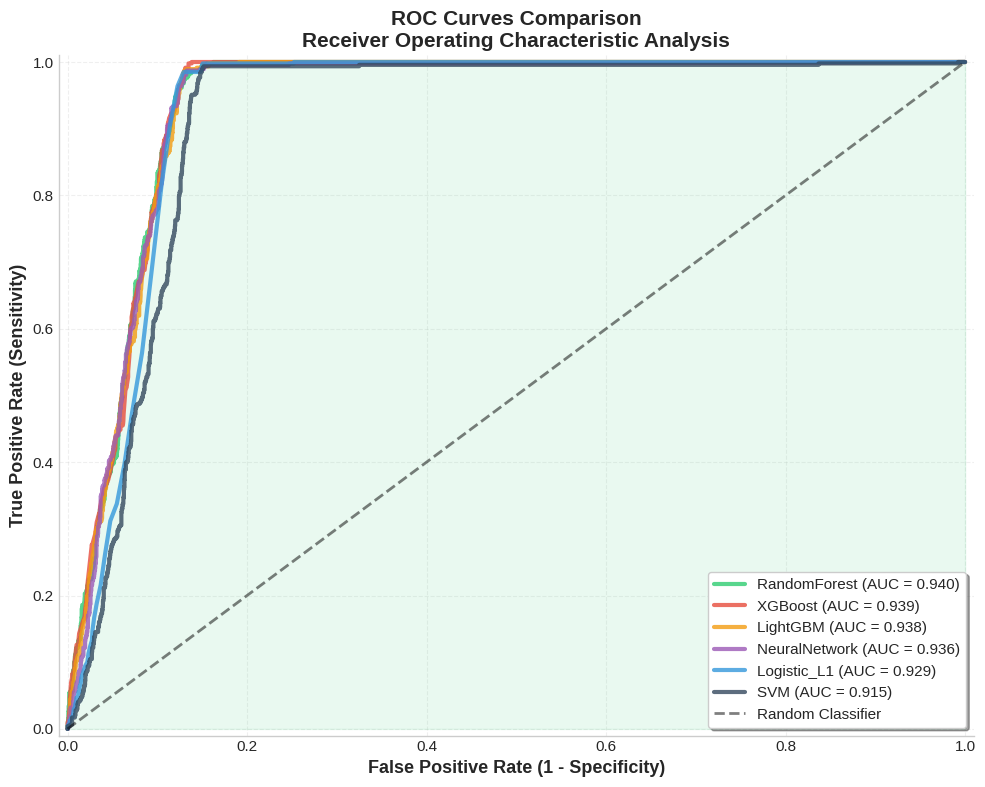


📊 [PLOT 3] Precision-Recall Curves
  ✅ Saved: 03_precision_recall_curves_20250622_215957.png


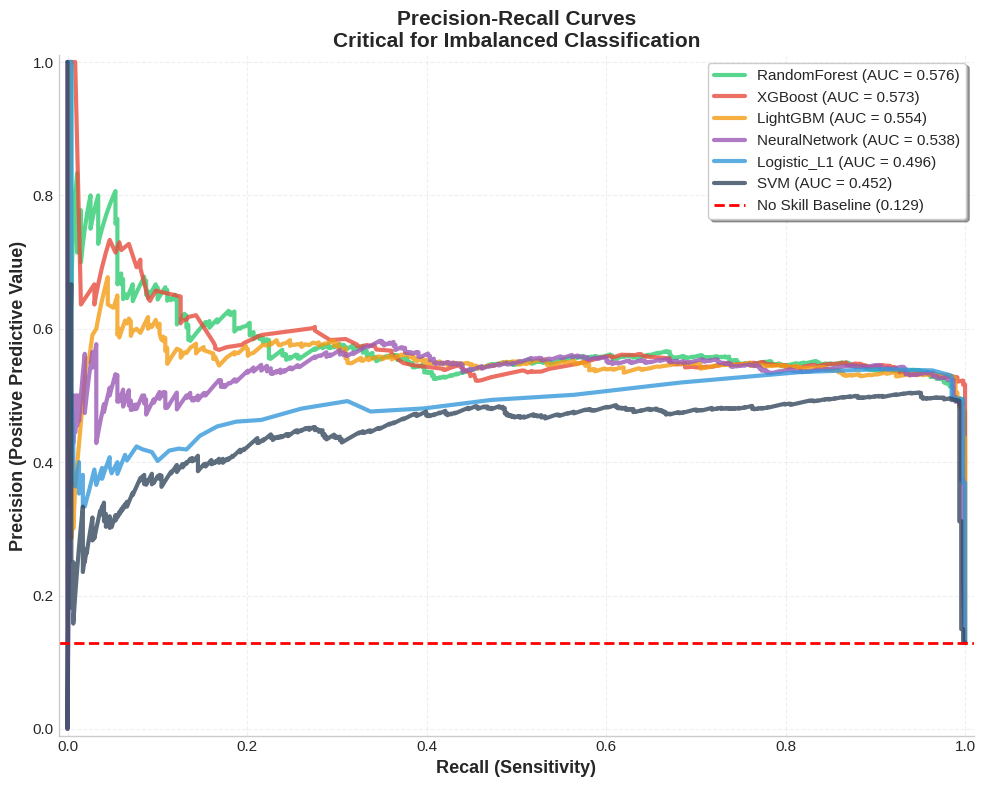


📅 [PLOT 11] Temporal Performance Analysis
  ✅ Saved: 11_temporal_performance_20250622_215957.png


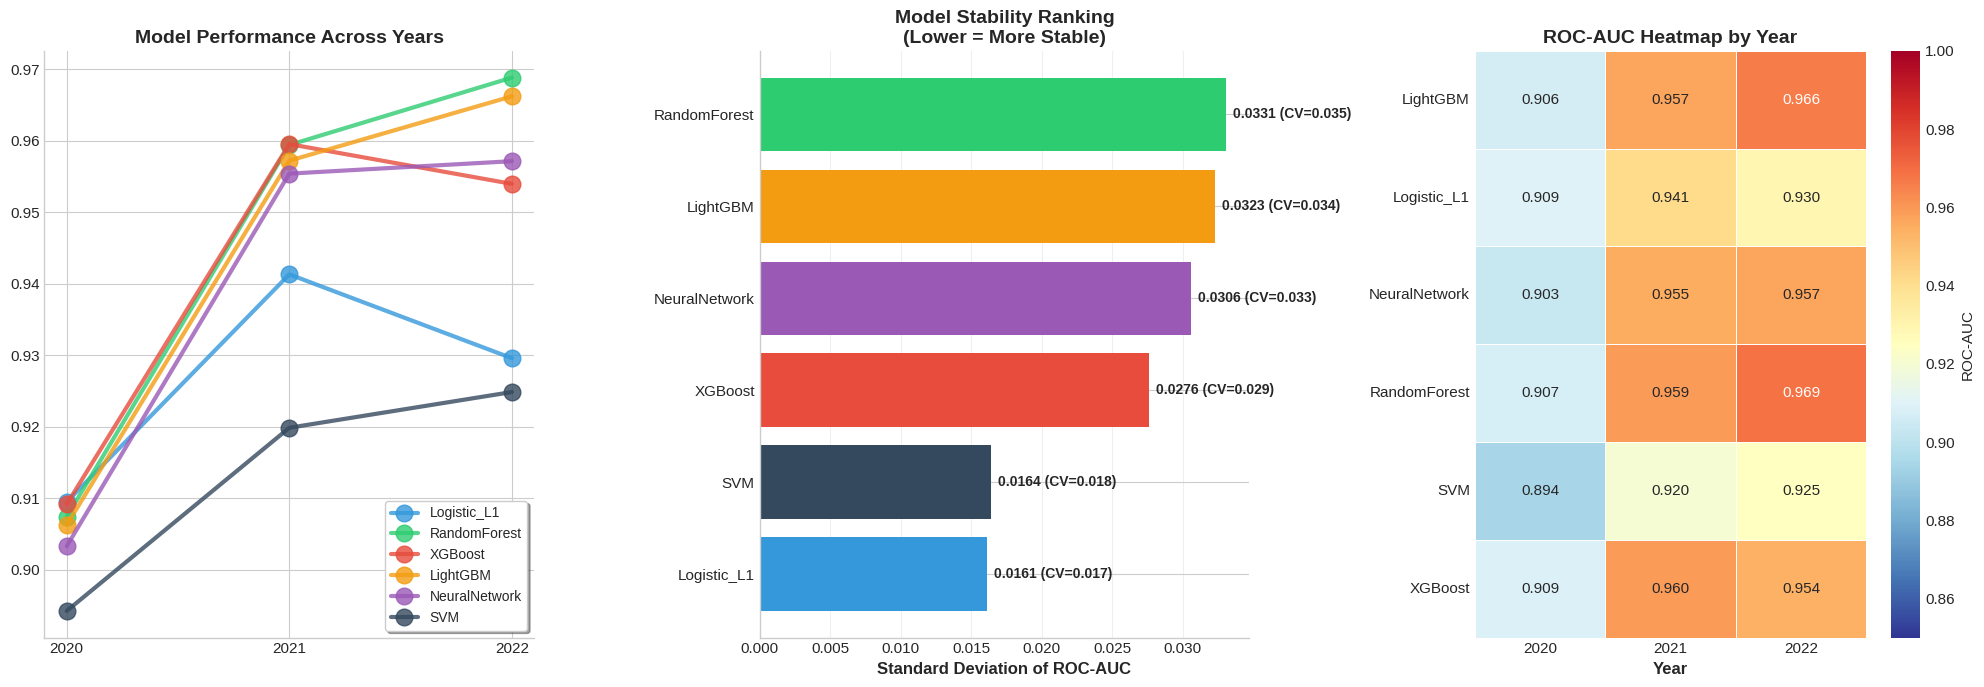

In [ ]:
#@title  PLOT 2-3
import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    import optuna.visualization as optuna_vis
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("⚠️ Optuna not found - skipping optimization plots")

# Check if kaleido is available for PNG export
try:
    import kaleido
    HAS_KALEIDO = True
    print("✅ Kaleido found - PNG export enabled")
except ImportError:
    HAS_KALEIDO = False
    print("⚠️ Kaleido not found - PNG export disabled")

# Set modern matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Create visualization folder
if 'path_MODEL' not in globals():
    path_MODEL = './'

viz_folder = os.path.join(path_MODEL, 'visualizations')
os.makedirs(viz_folder, exist_ok=True)

# Add timestamp to filenames
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("📊 FIXED ML VISUALIZATION SUITE")
print("=" * 80)
print(f"📁 Saving all plots to: {viz_folder}")
print(f"🕒 Timestamp: {timestamp}")
print("=" * 80)

# Define modern color palette
model_colors = {
    'Logistic_L1': '#3498db',      # Blue
    'RandomForest': '#2ecc71',     # Green
    'XGBoost': '#e74c3c',          # Red
    'LightGBM': '#f39c12',         # Orange
    'NeuralNetwork': '#9b59b6',    # Purple
    'SVM': '#34495e'               # Dark slate gray
}

# Helper function to save figures
def save_fig(fig, name):
    """Save figure with consistent naming"""
    filename = os.path.join(viz_folder, f'{name}_{timestamp}.png')
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved: {os.path.basename(filename)}")

# Helper function to save plotly figures
def save_plotly_fig(fig, name, show_fig=True):
    """Save plotly figure as HTML and optionally as PNG"""
    # Always save HTML
    filename_html = os.path.join(viz_folder, f'{name}_{timestamp}.html')
    fig.write_html(filename_html)
    print(f"  ✅ Saved HTML: {os.path.basename(filename_html)}")

    # Try to save PNG if kaleido is available
    if HAS_KALEIDO:
        try:
            filename_png = os.path.join(viz_folder, f'{name}_{timestamp}.png')
            fig.write_image(filename_png, width=1200, height=800, scale=2)
            print(f"  ✅ Saved PNG: {os.path.basename(filename_png)}")
        except Exception as e:
            print(f"  ⚠️ Could not save PNG: {str(e)}")

    # Show figure if requested
    if show_fig:
        try:
            fig.show()
        except Exception as e:
            print(f"  ⚠️ Could not display figure in notebook: {str(e)}")

# Collect Optuna studies properly (without duplicates)
def collect_studies():
    """Collect all Optuna studies from globals"""
    if not HAS_OPTUNA:
        return {}

    studies = {}

    # Check for individual study variables
    study_mappings = {
        'study_logistic': 'Logistic_L1',
        'study_rf': 'RandomForest',
        'study_xgb': 'XGBoost',
        'study_lgb': 'LightGBM',
        'study_nn': 'NeuralNetwork',
        'study_svm': 'SVM'
    }

    for var_name, model_name in study_mappings.items():
        if var_name in globals() and isinstance(globals()[var_name], optuna.study.Study):
            studies[model_name] = globals()[var_name]

    # Also check if there's a 'studies' dictionary
    if 'studies' in globals() and isinstance(globals()['studies'], dict):
        for key, value in globals()['studies'].items():
            if isinstance(value, optuna.study.Study) and key not in studies:
                studies[key] = value

    return studies

# Get studies once
studies = collect_studies()

#================================================================================
#title  PLOT 2: ROC CURVES COMPARISON
#================================================================================

print("\n📈 [PLOT 2] ROC Curves Comparison")

plt.figure(figsize=(10, 8))

for model_name in results_df['Model']:
    fpr, tpr, _ = roc_curve(y_test, predictions[model_name]['test'])
    auc_score = roc_auc_score(y_test, predictions[model_name]['test'])

    plt.plot(fpr, tpr, linewidth=3, color=model_colors.get(model_name, 'gray'),
             label=f'{model_name} (AUC = {auc_score:.3f})', alpha=0.8)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Random Classifier')

# Fill area under best model curve
best_fpr, best_tpr, _ = roc_curve(y_test, predictions[best_model_name]['test'])
plt.fill_between(best_fpr, best_tpr, alpha=0.1,
                color=model_colors.get(best_model_name, 'gray'))

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13, fontweight='bold')
plt.title('ROC Curves Comparison\nReceiver Operating Characteristic Analysis',
         fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)

plt.tight_layout()
save_fig(plt.gcf(), '02_roc_curves')
plt.show()

#================================================================================
# PLOT 3: PRECISION-RECALL CURVES
#================================================================================

print("\n📊 [PLOT 3] Precision-Recall Curves")

plt.figure(figsize=(10, 8))
baseline = y_test.mean()

for model_name in results_df['Model']:
    precision, recall, _ = precision_recall_curve(y_test, predictions[model_name]['test'])
    pr_auc = average_precision_score(y_test, predictions[model_name]['test'])

    plt.plot(recall, precision, linewidth=3, color=model_colors.get(model_name, 'gray'),
             label=f'{model_name} (AUC = {pr_auc:.3f})', alpha=0.8)

plt.axhline(y=baseline, color='red', linestyle='--', linewidth=2,
           label=f'No Skill Baseline ({baseline:.3f})')

plt.xlabel('Recall (Sensitivity)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curves\nCritical for Imbalanced Classification',
         fontsize=15, fontweight='bold')
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)

plt.tight_layout()
save_fig(plt.gcf(), '03_precision_recall_curves')
plt.show()

#================================================================================
# PLOT 11: TEMPORAL PERFORMANCE (WITH BETTER COLORS)
#================================================================================

print("\n📅 [PLOT 11] Temporal Performance Analysis")

# Calculate yearly metrics
yearly_metrics = []
if 'Year' in df_model_ready.columns:
    # Get the years from the test set indices
    test_years = sorted(df_model_ready.loc[y_test.index, 'Year'].unique())

    for year in test_years:
        # Find which test samples belong to this year
        year_mask = df_model_ready.loc[y_test.index, 'Year'] == year
        year_mask = year_mask.values  # Convert to numpy array

        for model_name in models.keys():
            y_pred_year = predictions[model_name]['test'][year_mask]
            y_true_year = y_test.values[year_mask]

            if len(np.unique(y_true_year)) > 1:
                yearly_metrics.append({
                    'Year': year,
                    'Model': model_name,
                    'N_Samples': len(y_true_year),
                    'N_Failures': y_true_year.sum(),
                    'Failure_Rate': y_true_year.mean(),
                    'ROC_AUC': roc_auc_score(y_true_year, y_pred_year)
                })

if yearly_metrics:
    yearly_df = pd.DataFrame(yearly_metrics)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

    # Subplot 1: Performance over time
    for model_name in models.keys():
        model_data = yearly_df[yearly_df['Model'] == model_name]
        ax1.plot(model_data['Year'], model_data['ROC_AUC'],
                marker='o', markersize=12, linewidth=3,
                color=model_colors.get(model_name, 'white'),
                label=model_name, alpha=0.8)

    ax1.set_title('Model Performance Across Years',
                  fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)


    # Fix x-axis to show only actual years
    years = sorted(yearly_df['Year'].unique())
    ax1.set_xticks(years)
    ax1.set_xticklabels(years)

    # Subplot 2: Stability ranking
    stability_data = []
    for model_name in models.keys():
        model_yearly = yearly_df[yearly_df['Model'] == model_name]['ROC_AUC']
        stability_data.append({
            'Model': model_name,
            'Mean_ROCAUC': model_yearly.mean(),
            'Std_ROCAUC': model_yearly.std(),
            'CV': model_yearly.std() / model_yearly.mean() if model_yearly.mean() > 0 else 0
        })

    stability_df = pd.DataFrame(stability_data).sort_values('Std_ROCAUC')

    bars = ax2.barh(range(len(stability_df)), stability_df['Std_ROCAUC'],
                    color=[model_colors.get(m, 'gray') for m in stability_df['Model']])

    ax2.set_yticks(range(len(stability_df)))
    ax2.set_yticklabels(stability_df['Model'], fontsize=11)
    ax2.set_xlabel('Standard Deviation of ROC-AUC', fontsize=12, fontweight='bold')
    ax2.set_title('Model Stability Ranking\n(Lower = More Stable)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (idx, row) in enumerate(stability_df.iterrows()):
        ax2.text(row['Std_ROCAUC'] + 0.0005, i,
                f"{row['Std_ROCAUC']:.4f} (CV={row['CV']:.3f})",
                va='center', fontsize=10, fontweight='bold')

    # Subplot 3: Year-by-year comparison heatmap with better colors
    pivot_table = yearly_df.pivot(index='Model', columns='Year', values='ROC_AUC')

    # Use a colormap that highlights high values better
    sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='RdYlBu_r',  # Changed colormap
               vmin=0.85, vmax=1.0,  # Adjusted range for better contrast
               ax=ax3, cbar_kws={'label': 'ROC-AUC'},
               linewidths=0.5, linecolor='white')

    ax3.set_title('ROC-AUC Heatmap by Year', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax3.set_ylabel('')

    plt.tight_layout()
    save_fig(fig, '11_temporal_performance')
    plt.show()
else:
    print("  ⚠️ No temporal data available - skipping temporal analysis")


✅ Kaleido found - PNG export enabled
📊 FIXED ML VISUALIZATION SUITE
📁 Saving all plots to: /content/drive/MyDrive/SETUP DEFINITIVO/Temporaneo, lezioni ML/AIDA/output/model_test8/visualizations
🕒 Timestamp: 20250622_230520

🎯 [PLOT 9] Confusion Matrices at Optimal Thresholds
  ✅ Saved: 09_confusion_matrices_20250622_230520.png


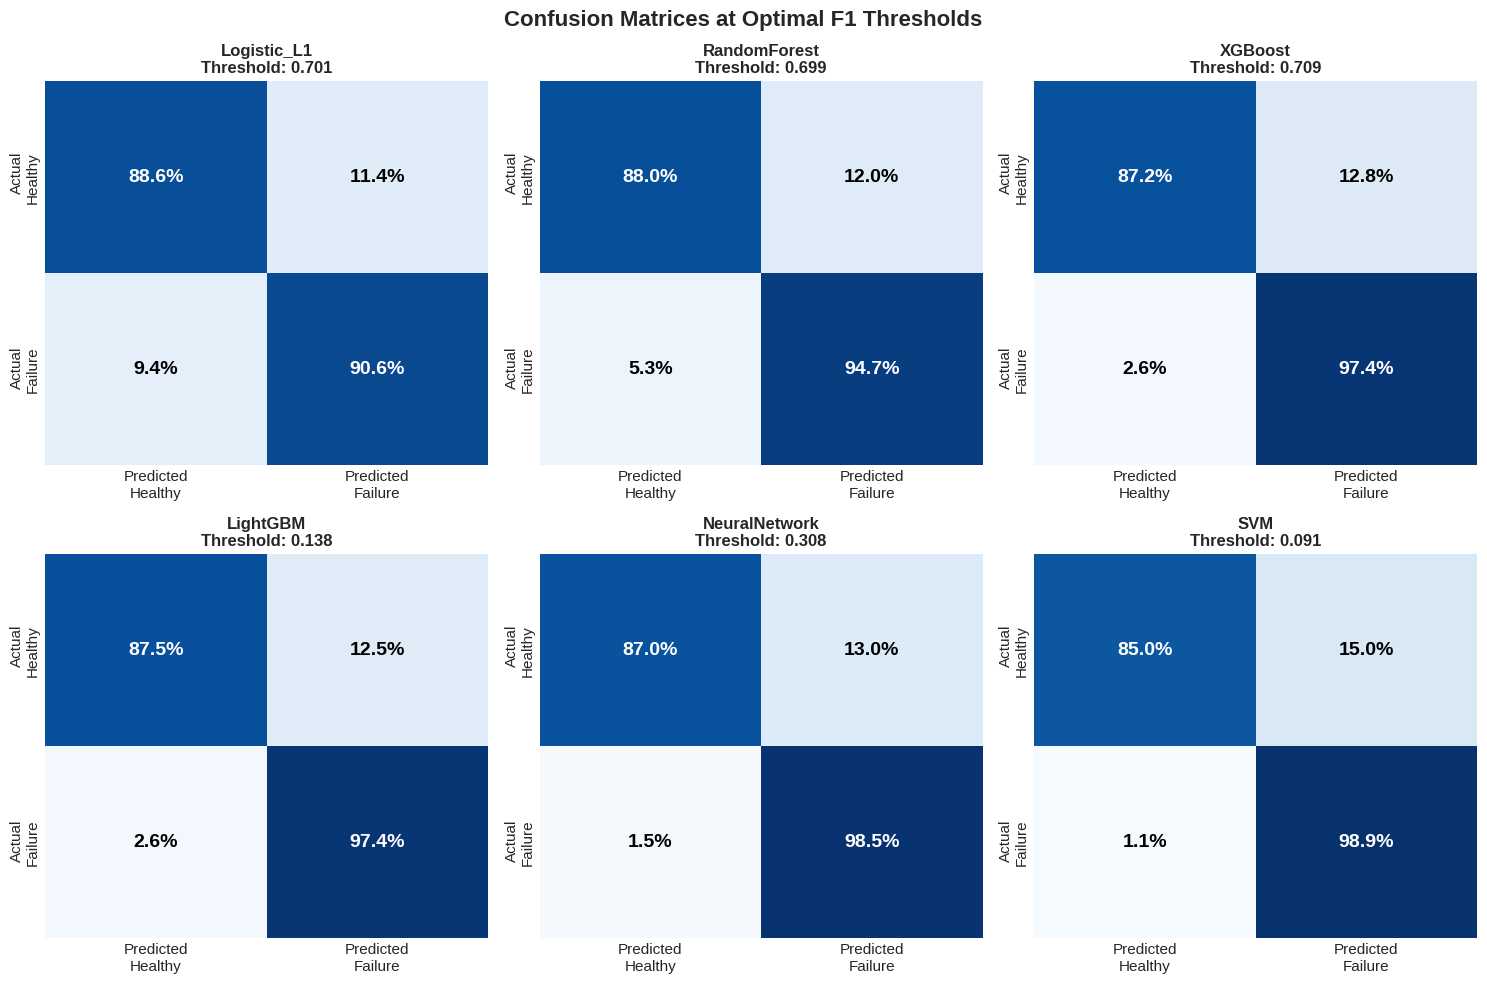

In [ ]:
#@title 📊 Fixed ML Visualization Suite - All Plots (FIXED)

import warnings
warnings.filterwarnings('ignore')

try:
    import optuna
    import optuna.visualization as optuna_vis
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("⚠️ Optuna not found - skipping optimization plots")

# Check if kaleido is available for PNG export
try:
    import kaleido
    HAS_KALEIDO = True
    print("✅ Kaleido found - PNG export enabled")
except ImportError:
    HAS_KALEIDO = False
    print("⚠️ Kaleido not found - PNG export disabled")

# Set modern matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Create visualization folder
if 'path_MODEL' not in globals():
    path_MODEL = './'

viz_folder = os.path.join(path_MODEL, 'visualizations')
os.makedirs(viz_folder, exist_ok=True)

# Add timestamp to filenames
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("📊 FIXED ML VISUALIZATION SUITE")
print("=" * 80)
print(f"📁 Saving all plots to: {viz_folder}")
print(f"🕒 Timestamp: {timestamp}")
print("=" * 80)

# Define modern color palette
model_colors = {
    'Logistic_L1': '#3498db',      # Blue
    'RandomForest': '#2ecc71',     # Green
    'XGBoost': '#e74c3c',          # Red
    'LightGBM': '#f39c12',         # Orange
    'NeuralNetwork': '#9b59b6',    # Purple
    'SVM': '#34495e'               # Dark slate gray
}

# Helper function to save figures
def save_fig(fig, name):
    """Save figure with consistent naming"""
    filename = os.path.join(viz_folder, f'{name}_{timestamp}.png')
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved: {os.path.basename(filename)}")

# Helper function to save plotly figures
def save_plotly_fig(fig, name, show_fig=True):
    """Save plotly figure as HTML and optionally as PNG"""
    # Always save HTML
    filename_html = os.path.join(viz_folder, f'{name}_{timestamp}.html')
    fig.write_html(filename_html)
    print(f"  ✅ Saved HTML: {os.path.basename(filename_html)}")

    # Try to save PNG if kaleido is available
    if HAS_KALEIDO:
        try:
            filename_png = os.path.join(viz_folder, f'{name}_{timestamp}.png')
            fig.write_image(filename_png, width=1200, height=800, scale=2)
            print(f"  ✅ Saved PNG: {os.path.basename(filename_png)}")
        except Exception as e:
            print(f"  ⚠️ Could not save PNG: {str(e)}")

    # Show figure if requested
    if show_fig:
        try:
            fig.show()
        except Exception as e:
            print(f"  ⚠️ Could not display figure in notebook: {str(e)}")

# Collect Optuna studies properly (without duplicates)
def collect_studies():
    """Collect all Optuna studies from globals"""
    if not HAS_OPTUNA:
        return {}

    studies = {}

    # Check for individual study variables
    study_mappings = {
        'study_logistic': 'Logistic_L1',
        'study_rf': 'RandomForest',
        'study_xgb': 'XGBoost',
        'study_lgb': 'LightGBM',
        'study_nn': 'NeuralNetwork',
        'study_svm': 'SVM'
    }

    for var_name, model_name in study_mappings.items():
        if var_name in globals() and isinstance(globals()[var_name], optuna.study.Study):
            studies[model_name] = globals()[var_name]

    # Also check if there's a 'studies' dictionary
    if 'studies' in globals() and isinstance(globals()['studies'], dict):
        for key, value in globals()['studies'].items():
            if isinstance(value, optuna.study.Study) and key not in studies:
                studies[key] = value

    return studies

# Get studies once
studies = collect_studies()

print("\n🎯 [PLOT 9] Confusion Matrices at Optimal Thresholds")

n_models = len(models)
n_cols = min(3, n_models)
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
if n_models == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_rows > 1 else axes

for idx, model_name in enumerate(models.keys()):
    ax = axes[idx]

    # Get optimal threshold
    optimal_threshold = results_df[results_df['Model'] == model_name]['Optimal_Threshold'].values[0]

    # Make predictions
    y_pred_binary = (predictions[model_name]['test'] > optimal_threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_binary)

    # Normalize for percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Plot heatmap with normalized values for color intensity
    sns.heatmap(cm_normalized, annot=False, fmt='.1f', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted\nHealthy', 'Predicted\nFailure'],
                yticklabels=['Actual\nHealthy', 'Actual\nFailure'],
                vmin=0, vmax=100)  # Use percentage for color scale
    """
    # Add custom annotations with both count and percentage
    for i in range(2):
        for j in range(2):
            # Determine text color based on background intensity
            text_color = 'white' if cm_normalized[i, j] > 50 else 'black'

            # Add count and percentage in same font
            text = f'{cm[i, j]}\n({cm_normalized[i, j]:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text,
                   ha='center', va='center',
                   fontsize=14, fontweight='bold',
                   color=text_color)
    """
    # Add custom annotations only percentage
    for i in range(2):
        for j in range(2):
            # Determine text color based on background intensity
            text_color = 'white' if cm_normalized[i, j] > 50 else 'black'

            # Add count and percentage in same font
            text = f'{cm_normalized[i, j]:.1f}%'
            ax.text(j + 0.5, i + 0.5, text,
                  ha='center', va='center',
                  fontsize=14, fontweight='bold',
                  color=text_color)

    ax.set_title(f'{model_name}\nThreshold: {optimal_threshold:.3f}',
                fontsize=12, fontweight='bold')

# Remove unused subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Confusion Matrices at Optimal F1 Thresholds', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig(fig, '09_confusion_matrices')
plt.show()